# Mini Project for Massive Graph Management and Analytics

**Authors:** Adrian Patricio & Oluwanifemi Olajuyigbe  |  **Repository:** github.com/alpatricio10/mgma-project

### Overview:
This project explores a range of graph machine learning methods for fundamental graph tasks including link prediction, node classification, and graph-level analysis across multiple real-world datasets. We implement and compare two families of models, evaluating their strengths and limitations on different graph structures and prediction tasks.

**Model families:**

- Knowledge Graph Embeddings (TransE, TransH, TransR, DistMult, ComplEx, RotatE) — multi-relational models for link and relation prediction
- Graph Neural Networks (GCN, GraphSAGE, GAT, R-GCN) — message-passing models that learn node representations through neighbor aggregation


**Datasets:**

- **BioDecagon:** A large-scale biomedical graph of drug-drug polypharmacy side effects (~645 drugs, ~19K proteins, 964 side-effect types). Used for multi-relational link prediction and relation prediction.

- **ArXiv GR-QC Collaboration Network:** An undirected scientific collaboration network from the General Relativity and Quantum Cosmology section of arXiv.

- **SNAP Facebook Social Network:** n undirected network of friendship connections on Facebook. It is used for community detection on a homogeneous social graph.

- **Email-Eu-Core Network:** A directed network of email communications between members of a large European research institution (1,005 nodes, 25,571 directed edges). Ground-truth department labels enable clustering evaluation.


Each model family is evaluated on tasks appropriate to its capabilities. The goal is to understand which methods are best suited for different graph structures, tasks, and evaluation settings. All work is reproducible in a single Python notebook.

### Environment Setup

We install and import all necessary libraries. The core stack is **PyTorch Geometric** for GNN and graph utilities, along with standard scientific Python libraries.

In [ ]:
# ── Imports ──────────────────────────────────────────────────────────────
import os, warnings, time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam

from sklearn.metrics import (roc_auc_score, average_precision_score)

import networkx as nx


warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

# ── Check device ────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ── Reproducibility ─────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

/home/adrian/mgma-project/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


## Dataset 1: General Relativity and Quantum Cosmology collaboration network

### Data Source
- SNAP ArXiv GR-QC Collaboration Network: https://snap.stanford.edu/data/ca-GrQc.html

    - The ArXiv GR-QC dataset is an undirected scientific collaboration network from the General Relativity and Quantum Cosmology section of arXiv.
    - Nodes: Authors who submitted papers to the GR-QC category
    - Edges: 14,496 undirected edges representing co-authorship relationships between 5,242 authors (if two authors co-wrote a paper, an edge connects them)
    - Collaboration structure: Papers with multiple co-authors form fully connected subgraphs among those authors
    - Time span: January 1993 – April 2003 (124 months), covering the early and nearly complete history of the GR-QC section

**Download instructions:**
Download the ca-GrQc.txt.gz file from the SNAP link above, extract the ca-GrQc.txt file, and place it in a data/ directory located in the same directory as your main Python notebook or script.

### Link Prediction with GNNs

 Given the graph structure and node features, we train a GNN to predict whether an edge exists between two nodes. 


In [ ]:
# Import libraries
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
import pandas as pd

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

In [ ]:
# Load dataset
txt_file = 'data/CA-GrQc.txt'
G_ca = nx.read_edgelist(txt_file, create_using=nx.Graph(), nodetype=int)

print(f"CA-GrQc Network Loaded:")
print(f"  Nodes: {G_ca.number_of_nodes()}")
print(f"  Edges: {G_ca.number_of_edges()}")


CA-GrQc Network Loaded:
  Nodes: 5242
  Edges: 14496


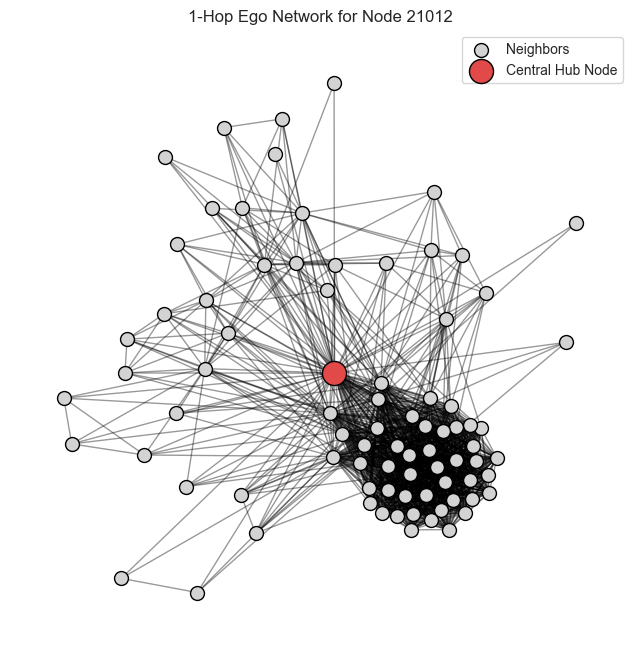

In [ ]:
# Find the node with the highest degree (hub)
max_degree_node = max(dict(G_ca.degree()).items(), key=lambda x: x[1])[0]

# Extract its Ego-Graph (the node and its immediate neighbors)
ego_g = nx.ego_graph(G_ca, max_degree_node, radius=1)

# Plotting setup
plt.figure(figsize=(8, 8))
pos = nx.spring_layout(ego_g, seed=42, k=0.15) 

nx.draw_networkx_nodes(ego_g, pos, node_color='lightgray', 
                       node_size=100, edgecolors='black', label='Neighbors')

nx.draw_networkx_nodes(ego_g, pos, nodelist=[max_degree_node], 
                       node_color='#E24A4A', node_size=300, 
                       edgecolors='black', label='Central Hub Node')

# Draw only the positive samples
nx.draw_networkx_edges(ego_g, pos, alpha=0.4)

plt.title(f'1-Hop Ego Network for Node {max_degree_node}')
plt.legend(scatterpoints=1)
plt.axis('off') 
plt.show()

### Data Preparation & Sampling

We split the graph first before computing any structural node features (**degree**, **clustering coefficient**, and **PageRank**) on the **training message-passing graph** to prevent data leakage.  

- **Balanced Sampling**: We use *RandomLinkSplit* to divide the dataset into train, val, and test sets. It automatically adds an equal number of negative pairs so the training set is a balanced 1:1 binary classification task.  

- **No overlap** – We fix the random seed and verify there is no overlap between the train, validation, and test pairs, to ensure the test set remains hidden.



In [ ]:
# Avoid PermissionError
import os
os.environ.pop('SSLKEYLOGFILE', None)

import torch
from torch import nn
import torch.nn.functional as F
# Force full torch_geometric init to avoid 'partially initialized module' / circular import
import torch_geometric
from torch_geometric.nn import GCNConv
from torch_geometric.transforms import RandomLinkSplit
from torch_geometric.utils import from_networkx
from sklearn.metrics import roc_auc_score, average_precision_score
import random

# Build PyG Data from CA-GrQc graph 
data_lp = from_networkx(G_ca)
if data_lp.x is None:
    data_lp.x = torch.ones((data_lp.num_nodes, 3), dtype=torch.float)  # placeholder for split

# Train/val/test split first (so we can compute features on training graph only)
transform = RandomLinkSplit(num_val=0.05, num_test=0.10, is_undirected=True, add_negative_train_samples=True, split_labels=False, disjoint_train_ratio=0.0)
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
train_data, val_data, test_data = transform(data_lp)

# Compute structural features on the training message-passing graph only 
edge_index_np = train_data.edge_index.cpu().numpy()
G_train = nx.Graph()
G_train.add_nodes_from(range(train_data.num_nodes))
G_train.add_edges_from(zip(edge_index_np[0].tolist(), edge_index_np[1].tolist()))
node_list = list(range(train_data.num_nodes))
degs = np.array([G_train.degree(n) for n in node_list], dtype=float)
deg_max = max(degs.max(), 1.0)
degs_norm = degs / deg_max
clustering = nx.clustering(G_train)
clust = np.array([clustering[n] for n in node_list], dtype=float)
clust_max = max(clust.max(), 1e-10)
clust_norm = clust / clust_max
pr = nx.pagerank(G_train)
pagerank_vals = np.array([pr[n] for n in node_list], dtype=float)
pr_max = max(pagerank_vals.max(), 1e-10)
pr_norm = pagerank_vals / pr_max

# stack features
x_feat = torch.tensor(np.stack([degs_norm, clust_norm, pr_norm], axis=1), dtype=torch.float)
train_data.x = x_feat
val_data.x = x_feat
test_data.x = x_feat

n_train_pos = int(train_data.edge_label.sum().item())
n_train_neg = train_data.edge_label_index.shape[1] - n_train_pos
n_val_pos = int(val_data.edge_label.sum().item())
n_val_neg = val_data.edge_label_index.shape[1] - n_val_pos
n_test_pos = int(test_data.edge_label.sum().item())
n_test_neg = test_data.edge_label_index.shape[1] - n_test_pos
print("Link prediction data prepared (structural features from training graph only):")
print(f"  Nodes: {train_data.num_nodes}, Features: {train_data.x.shape[1]}")
print(f"  Train message-passing edges (edge_index): {train_data.edge_index.shape[1]}")
print(f"  Train supervision pairs (edge_label_index): {train_data.edge_label_index.shape[1]} (pos: {n_train_pos}, neg: {n_train_neg}, neg/pos: {n_train_neg/max(n_train_pos,1):.2f})")
print(f"  Val pairs: {val_data.edge_label_index.shape[1]} (pos: {n_val_pos}, neg: {n_val_neg}, neg/pos: {n_val_neg/max(n_val_pos,1):.2f})")
print(f"  Test pairs: {test_data.edge_label_index.shape[1]} (pos: {n_test_pos}, neg: {n_test_neg}, neg/pos: {n_test_neg/max(n_test_pos,1):.2f})")

# Verify no overlap between train / val / test
def pairs_as_set(edge_label_index):
    e = edge_label_index.cpu().numpy()
    return set(zip(e[0].tolist(), e[1].tolist()))
train_pairs = pairs_as_set(train_data.edge_label_index)
val_pairs = pairs_as_set(val_data.edge_label_index)
test_pairs = pairs_as_set(test_data.edge_label_index)
assert len(train_pairs & val_pairs) == 0 and len(train_pairs & test_pairs) == 0 and len(val_pairs & test_pairs) == 0, "Overlap in splits"
print("  No overlap between train / val / test (verified).")


Link prediction data prepared (structural features from training graph only):
  Nodes: 5242, Features: 3
  Train message-passing edges (edge_index): 24646
  Train supervision pairs (edge_label_index): 24646 (pos: 12323, neg: 12323, neg/pos: 1.00)
  Val pairs: 1448 (pos: 724, neg: 724, neg/pos: 1.00)
  Test pairs: 2898 (pos: 1449, neg: 1449, neg/pos: 1.00)
  No overlap between train / val / test (verified).


### Model definitions: encoders and decoders


We define **three encoder architectures** (GCN, GraphSAGE, GAT) and **two decoders** (MLP and Dot Product). All encoders are 2-layer message-passing networks: the first layer uses ReLU and dropout (to prevent overfitting on the training edges). The second layer has no activation so we get embedding vectors for the link decoder. 


- **GCN (Graph Convolutional Network)** — Uses symmetric degree normalization to aggregate neighbor features. Good baseline.
- **GraphSAGE** — Uses a general aggregation function (mean) without GCN's strict normalization. Often generalises better and scales to larger or degree-skewed graphs.
- **GAT (Graph Attention Network)** — Uses a general aggregation function (mean) without GCN's strict normalization, often generalizing better to unseen nodes.

**Decoders:**
- **Dot product:** score = $z_u^T z_v$. Assumes connected nodes will have highly similar embedding vectors.
- **MLP:** input = concatenation $[z_u \| z_v]$ passed through a small MLP. Captures asymmetry, and is valuable even in an undirected graph as it can learn more complex, non-linear interactions between the node pairs.

We compare all three encoders and both decoders in **Section 7.6**. 

In [ ]:
# GCN encoder + shared decoders (dot product and MLP)
class GCNEncoder(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        # Layer 1: message passing + ReLU
        x = self.conv1(x, edge_index).relu()
        x = F.dropout(x, p=0.5, training=self.training)
        # Layer 2: no activation so embeddings stay in R^d for dot product
        x = self.conv2(x, edge_index)
        return x


# Decoder: link score from node embeddings
def dot_product_decoder(z, edge_label_index):
    """Dot product decoder: hat{y}_{uv} = z_u^T z_v (then we apply sigmoid for BCE)."""
    src, dst = edge_label_index[0], edge_label_index[1]
    logits = (z[src] * z[dst]).sum(dim=-1)
    return logits


# MLP decoder: score from concatenation [z_u || z_v]
class MLPDecoder(nn.Module):
    def __init__(self, out_channels, hidden_mlp=64):
        super().__init__()
        # Input: concatenation of z_u and z_v -> shape (num_pairs, 2*out_channels)
        self.mlp = nn.Sequential(
            nn.Linear(2 * out_channels, hidden_mlp),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_mlp, 1),
        )

    def forward(self, z, edge_label_index):
        src, dst = edge_label_index[0], edge_label_index[1]
        z_pair = torch.cat([z[src], z[dst]], dim=-1)  # (num_pairs, 2*out_channels)
        logits = self.mlp(z_pair).squeeze(-1)
        return logits


# Full model: encoder + decoder (MLP by default)
class GCNLinkPrediction(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, use_mlp_decoder=True):
        super().__init__()
        self.encoder = GCNEncoder(in_channels, hidden_channels, out_channels)
        self.use_mlp_decoder = use_mlp_decoder
        if use_mlp_decoder:
            self.decoder = MLPDecoder(out_channels)
        else:
            self.decoder = None

    def forward(self, x, edge_index, edge_label_index):
        z = self.encoder(x, edge_index)
        if self.decoder is not None:
            logits = self.decoder(z, edge_label_index)
        else:
            logits = dot_product_decoder(z, edge_label_index)
        return logits

In [ ]:
# GraphSAGE encoder — neighbour aggregation (mean); same dot/MLP decoder options as GCN
from torch_geometric.nn import SAGEConv

class GraphSAGEEncoder(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return x

class GraphSAGELinkPrediction(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, use_mlp_decoder=True):
        super().__init__()
        self.encoder = GraphSAGEEncoder(in_channels, hidden_channels, out_channels)
        self.use_mlp_decoder = use_mlp_decoder
        if use_mlp_decoder:
            self.decoder = MLPDecoder(out_channels)
        else:
            self.decoder = None

    def forward(self, x, edge_index, edge_label_index):
        z = self.encoder(x, edge_index)
        if self.decoder is not None:
            logits = self.decoder(z, edge_label_index)
        else:
            logits = dot_product_decoder(z, edge_label_index)
        return logits

In [ ]:
# GAT encoder — attention over neighbours; same dot/MLP decoder options as GCN
from torch_geometric.nn import GATConv

class GATEncoder(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=4):
        super().__init__()
        self.heads = heads
        self.conv1 = GATConv(in_channels, hidden_channels, heads=heads)
        self.conv2 = GATConv(hidden_channels * heads, out_channels, heads=1)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return x

class GATLinkPrediction(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, use_mlp_decoder=True, heads=4):
        super().__init__()
        self.encoder = GATEncoder(in_channels, hidden_channels, out_channels, heads=heads)
        self.use_mlp_decoder = use_mlp_decoder
        if use_mlp_decoder:
            self.decoder = MLPDecoder(out_channels)
        else:
            self.decoder = None

    def forward(self, x, edge_index, edge_label_index):
        z = self.encoder(x, edge_index)
        if self.decoder is not None:
            logits = self.decoder(z, edge_label_index)
        else:
            logits = dot_product_decoder(z, edge_label_index)
        return logits

- All models output **logits** (no sigmoid inside the model) so we train with `BCEWithLogitsLoss` for numerical stability.

### Training and Model Selection

The training process follows the standard pipeline:

**Loss Function:** We use **Binary cross-entropy formula:** 
$$\mathcal{L}_{\mathrm{BCE}} = -\frac{1}{N}\sum_{i=1}^{N} \left[ y_i \log(\hat{p}_i) + (1-y_i) \log(1-\hat{p}_i) \right].$$

**Optimization**: We use the Adam optimizer to update weights ($W$) based on the error.

**Hyperparameter Tuning:** We use a Grid Search on the validation set to find the best learning rate and embedding dimensions.

**Early Stopping:** We monitor the validation AUC with a patience of 40 epochs to prevent the model from overfitting and ensure it generalizes to unseen data

**Evaluation Metrics**
We evaluate performance using two distinct approaches:

- **Global Metrics (AUC & AP):** These measure how well the model separates and scores real links higher than non-existent ones globally.

- **Ranking Metrics (MRR & Hits@K):** We rank each true positive test edge against 99 random negative edges. - 
> - *MRR (Mean Reciprocal Rank)*: Penalizes the model if the true edge isn't ranked at the top. 
> - *Hits@K:* Measures if the true edge appears in the top $K$ (1, 10, or 50) results.

In [ ]:
# Training: grid search over hyperparameters; best config and best epoch by validation AUC 
import itertools
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
in_dim = train_data.x.shape[1]
train_data = train_data.to(device)
val_data = val_data.to(device)
test_data = test_data.to(device)

def train_link_prediction(model, data, optimizer):
    model.train()
    optimizer.zero_grad()
    logits = model(data.x, data.edge_index, data.edge_label_index)
    labels = data.edge_label.float()
    loss = F.binary_cross_entropy_with_logits(logits, labels)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    return float(loss)



# Training: grid search over hyperparameters; best config and best epoch by validation AUC 
import itertools
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
in_dim = train_data.x.shape[1]
train_data = train_data.to(device)
val_data = val_data.to(device)
test_data = test_data.to(device)

def train_link_prediction(model, data, optimizer):
    model.train()
    optimizer.zero_grad()
    logits = model(data.x, data.edge_index, data.edge_label_index)
    labels = data.edge_label.float()
    loss = F.binary_cross_entropy_with_logits(logits, labels)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    return float(loss)


def _compute_mrr_hits_strict(model, data, n_negatives, k_list, device):
    """Standard evaluation: for each test positive (u,v), rank (u,v) among (u,v) and (u,w) for n_negatives random w. MRR = mean(1/rank), HITS@k = fraction with rank <= k."""
    labels = data.edge_label.cpu().numpy()
    pos_idx = np.where(labels == 1)[0]
    if len(pos_idx) == 0:
        return 0.0, {k: 0.0 for k in k_list}
    eli = data.edge_label_index.cpu().numpy()
    test_src = eli[0, pos_idx]
    test_dst = eli[1, pos_idx]
    n_pos = len(test_src)
    num_nodes = data.num_nodes
    n_neg = min(n_negatives, num_nodes - 1)
    rng = np.random.default_rng(42)
    neg_dst = np.zeros((n_pos, n_neg), dtype=np.int64)
    for i in range(n_pos):
        cand = np.setdiff1d(np.arange(num_nodes), [test_dst[i]])
        neg_dst[i] = rng.choice(cand, size=n_neg, replace=False)
    edge_src = np.repeat(test_src, 1 + n_neg)
    edge_dst = np.concatenate([np.concatenate([[test_dst[i]], neg_dst[i]]) for i in range(n_pos)])
    edge_label_index_new = torch.tensor(np.stack([edge_src, edge_dst]), dtype=torch.long, device=device)
    logits = model(data.x, data.edge_index, edge_label_index_new)
    probs = torch.sigmoid(logits).cpu().numpy().reshape(n_pos, 1 + n_neg)
    ranks = 1 + (probs[:, 1:] > probs[:, 0:1]).sum(axis=1)
    mrr = float(np.mean(1.0 / ranks))
    hits = {k: float(np.mean((ranks <= k).astype(float))) for k in k_list}
    return mrr, hits

N_NEGATIVES_FOR_RANKING = 99  # standard: rank each test positive among 1 + 99 candidates

@torch.no_grad()
def evaluate_link_prediction(model, data, k_list=(1, 10, 50), n_negatives_for_ranking=None):
    model.eval()
    logits = model(data.x, data.edge_index, data.edge_label_index)
    # Convert logits to probabilities
    probs = torch.sigmoid(logits).cpu().numpy()
    labels = data.edge_label.cpu().numpy()
    # Calculate metrics
    auc = roc_auc_score(labels, probs)
    ap = average_precision_score(labels, probs)
    if n_negatives_for_ranking is not None:
        mrr, hits = _compute_mrr_hits_strict(model, data, n_negatives_for_ranking, k_list, data.x.device)
    else:
        # Default fallback if no ranking is requested
        mrr, hits = 0.0, {k: 0.0 for k in k_list}
    return auc, ap,  mrr, hits

# Grid search: select best config by validation AUC
param_grid = {
    'lr': [0.005, 0.01],
    'hidden_dim': [64, 128],
    'out_dim': [32, 64],
}
epochs_max = 250
patience = 40
best_val_auc = 0.0
best_config = None
best_state = None
keys = list(param_grid.keys())
values = list(param_grid.values())
# Track best GCN config/state in this cell so we load GCN weights only
best_gcn_config = None
best_gcn_state = None
best_gcn_val_auc = 0.0
for combo in itertools.product(*values):
    config = dict(zip(keys, combo))
    model = GCNLinkPrediction(in_dim, config['hidden_dim'], config['out_dim']).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'], weight_decay=5e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=30)
    no_improve = 0
    best_val_auc_c = 0.0
    best_state_c = None
    for epoch in range(1, epochs_max + 1):
        loss = train_link_prediction(model, train_data, optimizer)
        val_auc, val_ap, val_mrr, val_hits = evaluate_link_prediction(model, val_data)
        scheduler.step(val_auc)
        if val_auc > best_val_auc_c:
            best_val_auc_c = val_auc
            best_state_c = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
        if no_improve >= patience:
            break
    if best_val_auc_c > best_gcn_val_auc:
        best_gcn_val_auc = best_val_auc_c
        best_gcn_config = config.copy()
        best_gcn_state = best_state_c
    if best_val_auc_c > best_val_auc:
        best_val_auc = best_val_auc_c
        best_config = config.copy()
        best_state = best_state_c
    print(f"  Config {config} -> best val AUC: {best_val_auc_c:.4f}")

gcn_model = GCNLinkPrediction(in_dim, best_gcn_config['hidden_dim'], best_gcn_config['out_dim']).to(device)
if best_gcn_state is not None:
    gcn_model.load_state_dict(best_gcn_state)
print(f"Best config GCN (by val AUC): {best_gcn_config}  (val AUC: {best_gcn_val_auc:.4f})")
print("Restored best model for test evaluation.")


  Config {'lr': 0.005, 'hidden_dim': 64, 'out_dim': 32} -> best val AUC: 0.8812
  Config {'lr': 0.005, 'hidden_dim': 64, 'out_dim': 64} -> best val AUC: 0.8848
  Config {'lr': 0.005, 'hidden_dim': 128, 'out_dim': 32} -> best val AUC: 0.8855
  Config {'lr': 0.005, 'hidden_dim': 128, 'out_dim': 64} -> best val AUC: 0.8784
  Config {'lr': 0.01, 'hidden_dim': 64, 'out_dim': 32} -> best val AUC: 0.8898
  Config {'lr': 0.01, 'hidden_dim': 64, 'out_dim': 64} -> best val AUC: 0.8890
  Config {'lr': 0.01, 'hidden_dim': 128, 'out_dim': 32} -> best val AUC: 0.8903
  Config {'lr': 0.01, 'hidden_dim': 128, 'out_dim': 64} -> best val AUC: 0.8906
Best config GCN (by val AUC): {'lr': 0.01, 'hidden_dim': 128, 'out_dim': 64}  (val AUC: 0.8906)
Restored best model for test evaluation.


In [ ]:
# Track best GraphSAGE config/state in this cell so we load SAGE weights only
best_sage_config = None
best_sage_state = None
best_sage_val_auc = 0.0
for combo in itertools.product(*values):
    config = dict(zip(keys, combo))
    model = GraphSAGELinkPrediction(in_dim, config['hidden_dim'], config['out_dim']).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'], weight_decay=5e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=30)
    no_improve = 0
    best_val_auc_c = 0.0
    best_state_c = None
    for epoch in range(1, epochs_max + 1):
        loss = train_link_prediction(model, train_data, optimizer)
        val_auc, val_ap, val_mrr, val_hits = evaluate_link_prediction(model, val_data)
        scheduler.step(val_auc)
        if val_auc > best_val_auc_c:
            best_val_auc_c = val_auc
            best_state_c = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
        if no_improve >= patience:
            break
    if best_val_auc_c > best_sage_val_auc:
        best_sage_val_auc = best_val_auc_c
        best_sage_config = config.copy()
        best_sage_state = best_state_c
    if best_val_auc_c > best_val_auc:
        best_val_auc = best_val_auc_c
        best_config = config.copy()
        best_state = best_state_c
    print(f"  Config {config} -> best val AUC: {best_val_auc_c:.4f}")

sage_model = GraphSAGELinkPrediction(in_dim, best_sage_config['hidden_dim'], best_sage_config['out_dim']).to(device)
if best_sage_state is not None:
    sage_model.load_state_dict(best_sage_state)
print(f"Best config GraphSAGE (by val AUC): {best_sage_config}  (val AUC: {best_sage_val_auc:.4f})")
print("Restored best model for test evaluation.")

  Config {'lr': 0.005, 'hidden_dim': 64, 'out_dim': 32} -> best val AUC: 0.8893
  Config {'lr': 0.005, 'hidden_dim': 64, 'out_dim': 64} -> best val AUC: 0.8981
  Config {'lr': 0.005, 'hidden_dim': 128, 'out_dim': 32} -> best val AUC: 0.8998
  Config {'lr': 0.005, 'hidden_dim': 128, 'out_dim': 64} -> best val AUC: 0.8963
  Config {'lr': 0.01, 'hidden_dim': 64, 'out_dim': 32} -> best val AUC: 0.9012
  Config {'lr': 0.01, 'hidden_dim': 64, 'out_dim': 64} -> best val AUC: 0.9039
  Config {'lr': 0.01, 'hidden_dim': 128, 'out_dim': 32} -> best val AUC: 0.9017
  Config {'lr': 0.01, 'hidden_dim': 128, 'out_dim': 64} -> best val AUC: 0.9027
Best config GraphSAGE (by val AUC): {'lr': 0.01, 'hidden_dim': 64, 'out_dim': 64}  (val AUC: 0.9039)
Restored best model for test evaluation.


In [ ]:
# Track best GAT config/state in this cell so we load GAT weights (avoids wrong state from GCN/SAGE or old PyG)
best_gat_config = None
best_gat_state = None
best_gat_val_auc = 0.0
for combo in itertools.product(*values):
    config = dict(zip(keys, combo))
    model = GATLinkPrediction(in_dim, config['hidden_dim'], config['out_dim']).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'], weight_decay=5e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=30)
    no_improve = 0
    best_val_auc_c = 0.0
    best_state_c = None
    for epoch in range(1, epochs_max + 1):
        loss = train_link_prediction(model, train_data, optimizer)
        val_auc, val_ap, val_mrr, val_hits = evaluate_link_prediction(model, val_data)
        scheduler.step(val_auc)
        if val_auc > best_val_auc_c:
            best_val_auc_c = val_auc
            best_state_c = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
        if no_improve >= patience:
            break
    if best_val_auc_c > best_gat_val_auc:
        best_gat_val_auc = best_val_auc_c
        best_gat_config = config.copy()
        best_gat_state = best_state_c
    if best_val_auc_c > best_val_auc:
        best_val_auc = best_val_auc_c
        best_config = config.copy()
        best_state = best_state_c
    print(f"  Config {config} -> best val AUC: {best_val_auc_c:.4f}")

gat_model = GATLinkPrediction(in_dim, best_gat_config['hidden_dim'], best_gat_config['out_dim']).to(device)
if best_gat_state is not None:
    gat_model.load_state_dict(best_gat_state)
print(f"Best config GAT (by val AUC): {best_gat_config}  (val AUC: {best_gat_val_auc:.4f})")
print("Restored best model for test evaluation.")

  Config {'lr': 0.005, 'hidden_dim': 64, 'out_dim': 32} -> best val AUC: 0.8776
  Config {'lr': 0.005, 'hidden_dim': 64, 'out_dim': 64} -> best val AUC: 0.8756
  Config {'lr': 0.005, 'hidden_dim': 128, 'out_dim': 32} -> best val AUC: 0.8835
  Config {'lr': 0.005, 'hidden_dim': 128, 'out_dim': 64} -> best val AUC: 0.8730
  Config {'lr': 0.01, 'hidden_dim': 64, 'out_dim': 32} -> best val AUC: 0.8848
  Config {'lr': 0.01, 'hidden_dim': 64, 'out_dim': 64} -> best val AUC: 0.8766
  Config {'lr': 0.01, 'hidden_dim': 128, 'out_dim': 32} -> best val AUC: 0.8780
  Config {'lr': 0.01, 'hidden_dim': 128, 'out_dim': 64} -> best val AUC: 0.8779
Best config GAT (by val AUC): {'lr': 0.01, 'hidden_dim': 64, 'out_dim': 32}  (val AUC: 0.8848)
Restored best model for test evaluation.


### Test Set Evaluation

In [ ]:
# Test evaluation: best checkpoint by val AUC for GCN, GraphSAGE, and GAT
for name, model in [("GCN", gcn_model), ("GraphSAGE", sage_model), ("GAT", gat_model)]:
    test_auc, test_ap, test_mrr, test_hits = evaluate_link_prediction(model, test_data, n_negatives_for_ranking=N_NEGATIVES_FOR_RANKING)
    print(f"Link Prediction ({name}) – Test results [best by val AUC]:")
    print(f"  AUC-ROC:       {test_auc:.4f}")
    print(f"  Avg Precision: {test_ap:.4f}")
    print(f"  MRR:          {test_mrr:.4f}")
    print(f"  HITS@1:       {test_hits[1]:.4f}")
    print(f"  HITS@10:      {test_hits[10]:.4f}")
    print(f"  HITS@50:      {test_hits[50]:.4f}")
    print()

Link Prediction (GCN) – Test results [best by val AUC]:
  AUC-ROC:       0.8882
  Avg Precision: 0.8984
  MRR:          0.3279
  HITS@1:       0.1863
  HITS@10:      0.5866
  HITS@50:      0.8765

Link Prediction (GraphSAGE) – Test results [best by val AUC]:
  AUC-ROC:       0.8886
  Avg Precision: 0.9058
  MRR:          0.3703
  HITS@1:       0.2526
  HITS@10:      0.5749
  HITS@50:      0.8937

Link Prediction (GAT) – Test results [best by val AUC]:
  AUC-ROC:       0.8778
  Avg Precision: 0.8935
  MRR:          0.3963
  HITS@1:       0.2678
  HITS@10:      0.6239
  HITS@50:      0.9013



### Comparison: GCN vs GraphSAGE vs GAT, and Dot vs MLP decoder


We compare **encoder architecture** (GCN vs GraphSAGE vs GAT) and **decoder** (dot product vs MLP) on the same Facebook train/val/test split with fixed hyperparameters. This shows:


In [ ]:
# Compare: GCN vs GraphSAGE vs GAT, MLP vs dot. Use best config per architecture (from grid search); train on train+val for final test eval.
from torch_geometric.data import Data
in_dim_c = train_data.x.shape[1]
hidden_fallback, out_fallback = 64, 64
lr_fallback, wd_c = 0.005, 1e-4
epochs_c = 200  # fixed epochs (no early stopping on train+val—evaluating on training data would be invalid)

# Build train+val data for final training (all non-test data)
edge_index_tv = torch.cat([train_data.edge_index, val_data.edge_index], dim=1).unique(dim=1)
edge_label_index_tv = torch.cat([train_data.edge_label_index, val_data.edge_label_index], dim=1)
edge_label_tv = torch.cat([train_data.edge_label, val_data.edge_label], dim=0)
train_val_data = Data(x=train_data.x.clone(), edge_index=edge_index_tv, edge_label_index=edge_label_index_tv, edge_label=edge_label_tv).to(device)

def _get_config(arch_name):
    """Use best config from grid search if available, else fixed fallback."""
    g = globals()
    if arch_name == "GCN":
        c = g.get('best_gcn_config')
        if c is not None: return c['hidden_dim'], c['out_dim'], c['lr']
    if arch_name == "GraphSAGE":
        c = g.get('best_sage_config')
        if c is not None: return c['hidden_dim'], c['out_dim'], c['lr']
    if arch_name == "GAT":
        c = g.get('best_gat_config')
        if c is not None: return c['hidden_dim'], c['out_dim'], c['lr']
    return hidden_fallback, out_fallback, lr_fallback

results_compare = []
t_total_start = time.perf_counter()

for arch_name, use_mlp in [("GCN", True), ("GCN", False), ("GraphSAGE", True), ("GraphSAGE", False), ("GAT", True), ("GAT", False)]:
    dec_name = "MLP" if use_mlp else "dot"
    t0 = time.perf_counter()
    hidden_c, out_c, lr_c = _get_config(arch_name)
    if arch_name == "GCN":
        model_c = GCNLinkPrediction(in_dim_c, hidden_c, out_c, use_mlp_decoder=use_mlp).to(device)
    elif arch_name == "GraphSAGE":
        model_c = GraphSAGELinkPrediction(in_dim_c, hidden_c, out_c, use_mlp_decoder=use_mlp).to(device)
    else:
        model_c = GATLinkPrediction(in_dim_c, hidden_c, out_c, use_mlp_decoder=use_mlp).to(device)
    opt_c = torch.optim.Adam(model_c.parameters(), lr=lr_c, weight_decay=wd_c)
    sched_c = torch.optim.lr_scheduler.ReduceLROnPlateau(opt_c, mode='max', factor=0.5, patience=30)
    for epoch in range(1, epochs_c + 1):
        _ = train_link_prediction(model_c, train_val_data, opt_c)
        va, vp, vm, vh = evaluate_link_prediction(model_c, train_val_data)
        sched_c.step(va)
    train_val_auc = va  # informational only (not used for model selection)
    ta, tp, tm, th = evaluate_link_prediction(model_c, test_data, n_negatives_for_ranking=N_NEGATIVES_FOR_RANKING)
    t_elapsed = time.perf_counter() - t0
    results_compare.append({
        "Encoder": arch_name,
        "Decoder": dec_name,
        "Train+Val AUC": train_val_auc,
        "Test AUC": ta,
        "Test AP": tp,
        "Test MRR": tm,
        "Test HITS@1": th[1],
        "Test HITS@10": th[10],
        "Test HITS@50": th[50],
        "Time (s)": round(t_elapsed, 2),
    })
    print(f"  {arch_name} + {dec_name}: train+val AUC {train_val_auc:.4f}, test AUC {ta:.4f}, test AP {tp:.4f}, test MRR {tm:.4f}, test HITS@10 {th[10]:.4f}, time {t_elapsed:.1f}s")

t_total = time.perf_counter() - t_total_start
df_compare = pd.DataFrame(results_compare)
print(f"\nTotal time (all 6 setups): {t_total:.1f}s")
print("\nComparison table (trained on train+val, best config per encoder when available):")
display(df_compare.round(4))

  GCN + MLP: train+val AUC 0.9687, test AUC 0.8990, test AP 0.9075, test MRR 0.3516, test HITS@10 0.5997, time 29.8s
  GCN + dot: train+val AUC 0.9082, test AUC 0.8306, test AP 0.8608, test MRR 0.2462, test HITS@10 0.5155, time 21.3s
  GraphSAGE + MLP: train+val AUC 0.9801, test AUC 0.9096, test AP 0.9174, test MRR 0.3868, test HITS@10 0.6025, time 25.8s
  GraphSAGE + dot: train+val AUC 0.9234, test AUC 0.8362, test AP 0.8635, test MRR 0.2761, test HITS@10 0.5342, time 15.0s
  GAT + MLP: train+val AUC 0.9779, test AUC 0.9075, test AP 0.9171, test MRR 0.4353, test HITS@10 0.6625, time 36.9s
  GAT + dot: train+val AUC 0.9322, test AUC 0.8492, test AP 0.8648, test MRR 0.3127, test HITS@10 0.5825, time 29.0s

Total time (all 6 setups): 157.8s

Comparison table (trained on train+val, best config per encoder when available):


,Encoder,Decoder,Train+Val AUC,Test AUC,Test AP,Test MRR,Test HITS@1,Test HITS@10,Test HITS@50,Time (s)
0,GCN,MLP,0.9687,0.8990,0.9075,0.3516,0.2153,0.5997,0.8999,29.80
1,GCN,dot,0.9082,0.8306,0.8608,0.2462,0.1166,0.5155,0.8578,21.29
2,GraphSAGE,MLP,0.9801,0.9096,0.9174,0.3868,0.2636,0.6025,0.9289,25.83
3,GraphSAGE,dot,0.9234,0.8362,0.8635,0.2761,0.1477,0.5342,0.8592,15.02
4,GAT,MLP,0.9779,0.9075,0.9171,0.4353,0.3071,0.6625,0.9317,36.88
5,GAT,dot,0.9322,0.8492,0.8648,0.3127,0.1698,0.5825,0.8951,28.99


### **Key Findings**

1. **The Power of MLP Decoders:** In every single test, the MLP Decoder significantly outperformed the Dot Product decoder. For example, the GAT+MLP achieved a Test AUC of 0.9075 compared to only 0.8492 for GAT+dot. This suggests that the relationship between author collaborations is non-linear and requires the additional complexity of a neural network to model effectively.

2. **GAT is the Ranking Champion:** While GraphSAGE and GAT were very close in global AUC (~0.90), GAT+MLP is the clear winner for in the ranking metrics. It achieved the highest Test MRR (0.4353) and Hits@1 (0.3071). This indicates that the attention mechanism is highly effective at identifying the exact collaborator out of 100 candidates.

3. **GraphSAGE for Broad Generalization:** GraphSAGE+MLP achieved the highest Test AUC (0.9096). It is incredibly robust at separating existing edges from non-edges globally, even if its "top-1" ranking is slightly lower than GAT's.

#### **Analysis of Ranking Metrics**
High Hits@50 vs. Lower Hits@1: For the GAT+MLP model, the Hits@50 is 0.9317, but the Hits@1 is 0.3071.

This shows that the model is extremely good at finding the "correct neighborhood" or research group of an author (placing the true collaborator in the top half of candidates 93% of the time), but picking the exact co-author is a more challenging task due to the high number of potential collaborators in large cliques.

#### **Efficiency vs. Performance**
GraphSAGE consistently provided the best balance of speed and performance. The GraphSAGE+dot setup was the fastest (15.02s), while the MLP versions took longer due to the added backpropagation through the decoder layers.



For the Arxiv GR-QC dataset, the GAT encoder paired with an MLP decoder is the optimal architecture. The attention mechanism allows the model to focus on the most relevant co-authorship patterns, while the MLP captures the non-linear dynamics of scientific collaboration. This setup ensures that test-time performance is maximized while the graph remains "connected enough" during message-passing to provide rich structural embeddings.

## Dataset 2: BioDecagon Polypharmacy Side-Effect Prediction

This part analyzes the BioDecagon multimodal, multi-relational biological graph for polypharmacy side-effect prediction using graph embedding and graph neural network methods. 

### Data Source

- **SNAP BioDecagon (Polypharmacy Side Effects):** http://snap.stanford.edu/decagon/
    - BioDecagon is a multimodal graph capturing relationships between drugs, proteins, and polypharmacy side effects
    - Drug–Drug interactions: ~4.6M edges across 964 polypharmacy side-effect types linking ~19K drugs (bio-decagon-combo.csv)
    - Protein–Protein interactions (PPI): ~715K undirected edges linking ~19K proteins (bio-decagon-ppi.csv)
    - Drug–Target interactions: ~18.7K edges linking drugs to their protein targets (bio-decagon-targets.csv)
    - Individual drug side effects: ~175K entries mapping drugs to their known single-drug side effects (bio-decagon-mono.csv)
    - Download the zip files from the link above, extract the necessary files and place them in a data/ directory located in the same directory as the main Python notebook

Each model is implemented as a self-contained pipeline with its own data preparation, training, and evaluation. The analysis for this dataset is structured as follows: Setup & Data Exploration, Multi-Relational KG Embeddings (TransE, TransH, TransR, DistMult, ComplEx, RotatE), GNN-Based Embeddings (GCN, GraphSAGE, R-GCN, GAT), and Experiments

## 1.1 — Load BioDecagon Data

The BioDecagon dataset consists of four CSV files. Let's load them and inspect their structure.

In [55]:
# ── Load all four BioDecagon data files ──────────────────────────────────
DATA_DIR = 'data'

combo_df   = pd.read_csv(os.path.join(DATA_DIR, 'bio-decagon-combo.csv'))
ppi_df     = pd.read_csv(os.path.join(DATA_DIR, 'bio-decagon-ppi.csv'))
targets_df = pd.read_csv(os.path.join(DATA_DIR, 'bio-decagon-targets.csv'))
mono_df    = pd.read_csv(os.path.join(DATA_DIR, 'bio-decagon-mono.csv'))

print("=== Drug-Drug Polypharmacy Side Effects (combo) ===")
print(f"Shape: {combo_df.shape}")
print(combo_df.head())
print()

=== Drug-Drug Polypharmacy Side Effects (combo) ===
Shape: (4649441, 4)
       STITCH 1      STITCH 2 Polypharmacy Side Effect  \
0  CID000002173  CID000003345                 C0151714   
1  CID000002173  CID000003345                 C0035344   
2  CID000002173  CID000003345                 C0004144   
3  CID000002173  CID000003345                 C0002063   
4  CID000002173  CID000003345                 C0004604   

             Side Effect Name  
0             hypermagnesemia  
1  retinopathy of prematurity  
2                 atelectasis  
3                   alkalosis  
4                   Back Ache  



In [56]:
print("=== Protein-Protein Interactions (PPI) ===")
print(f"Shape: {ppi_df.shape}")
print(ppi_df.head())
print()

=== Protein-Protein Interactions (PPI) ===
Shape: (715612, 2)
   Gene 1  Gene 2
0  114787  375519
1  114787  285613
2  114787    7448
3  114787    4914
4  114787   51343



In [57]:
print("=== Drug-Target Interactions ===")
print(f"Shape: {targets_df.shape}")
print(targets_df.head())
print()

=== Drug-Target Interactions ===
Shape: (18690, 2)
         STITCH  Gene
0  CID000003488  1559
1  CID000003488  8647
2  CID000077992  3351
3  CID000077992  3350
4  CID000077992  3352



In [58]:
print("=== Individual Drug Side Effects (mono) ===")
print(f"Shape: {mono_df.shape}")
print(mono_df.head())

=== Individual Drug Side Effects (mono) ===
Shape: (174977, 3)
         STITCH Individual Side Effect                Side Effect Name
0  CID003062316               C1096328     central nervous system mass
1  CID003062316               C0162830       Photosensitivity reaction
2  CID003062316               C1611725    leukaemic infiltration brain
3  CID003062316               C0541767  platelet adhesiveness abnormal
4  CID003062316               C0242973         Ventricular dysfunction


## 1.2 — Dataset Statistics

Here we compute some statistics for each component of the graph.

In [3]:
# ── Basic Statistics ──────────────────────────────────────────────────────
drugs_combo = set(combo_df['STITCH 1'].unique()) | set(combo_df['STITCH 2'].unique())
proteins    = set(ppi_df['Gene 1'].unique()) | set(ppi_df['Gene 2'].unique())
drugs_tgt   = set(targets_df['STITCH'].unique())
se_types    = combo_df['Polypharmacy Side Effect'].unique()

print("=" * 60)
print("BioDecagon Dataset Summary Statistics")
print("=" * 60)
print(f"\nNodes:")
print(f"  Unique drugs (combo):        {len(drugs_combo):,}")
print(f"  Unique drugs (targets):      {len(drugs_tgt):,}")
print(f"  Unique proteins (PPI):       {len(proteins):,}")
print(f"  Total unique nodes:          {len(drugs_combo | drugs_tgt | proteins):,}")
print(f"\nEdges:")
print(f"  Drug-Drug SE edges:          {len(combo_df):,}")
print(f"  Protein-Protein edges:       {len(ppi_df):,}")
print(f"  Drug-Target edges:           {len(targets_df):,}")
print(f"  Total edges:                 {len(combo_df) + len(ppi_df) + len(targets_df):,}")
print(f"\nRelation types:")
print(f"  Polypharmacy SE types:       {len(se_types):,}")
print(f"  Unique mono SE types:        {mono_df['Individual Side Effect'].nunique():,}")

BioDecagon Dataset Summary Statistics

Nodes:
  Unique drugs (combo):        645
  Unique drugs (targets):      284
  Unique proteins (PPI):       19,081
  Total unique nodes:          19,726

Edges:
  Drug-Drug SE edges:          4,649,441
  Protein-Protein edges:       715,612
  Drug-Target edges:           18,690
  Total edges:                 5,383,743

Relation types:
  Polypharmacy SE types:       1,317
  Unique mono SE types:        10,184


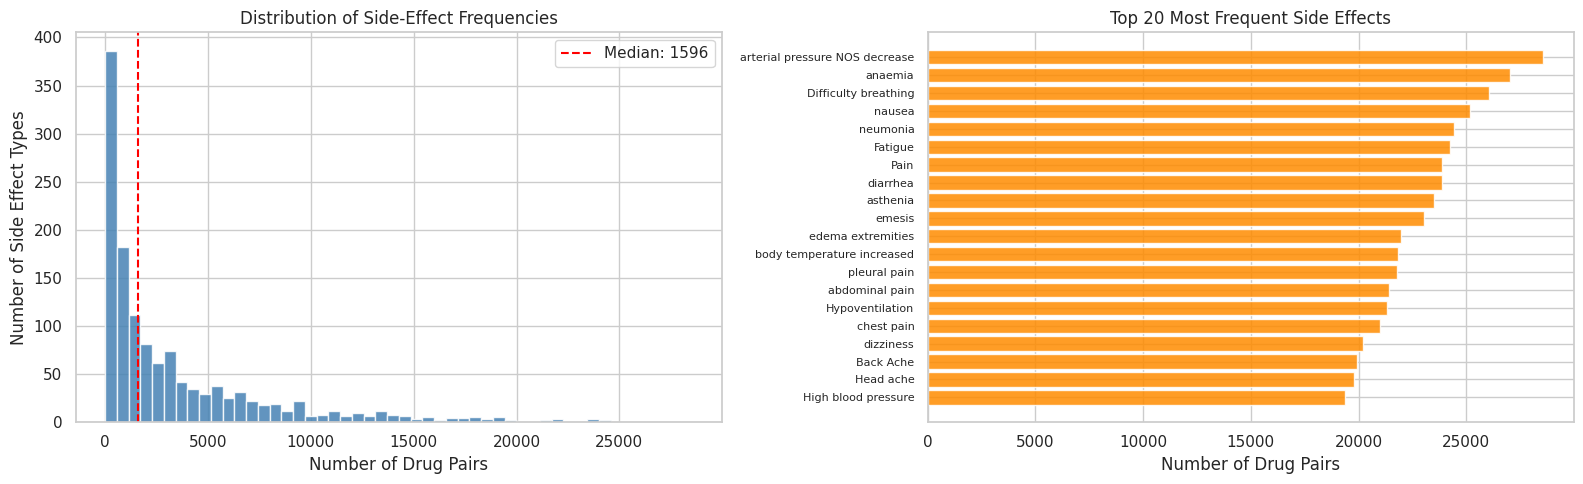


SE frequency stats:
  Most common:  arterial pressure NOS decreased (28,568 pairs)
  Least common: rabies (1 pairs)
  Median:       1596 pairs per SE type


In [4]:
# ── Side-effect frequency distribution ────────────────────────────────────
se_counts = combo_df['Polypharmacy Side Effect'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram of SE type frequencies
axes[0].hist(se_counts.values, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Number of Drug Pairs')
axes[0].set_ylabel('Number of Side Effect Types')
axes[0].set_title('Distribution of Side-Effect Frequencies')
axes[0].axvline(se_counts.median(), color='red', linestyle='--', label=f'Median: {se_counts.median():.0f}')
axes[0].legend()

# Top-20 most common SE types
top20 = se_counts.head(20)
axes[1].barh(range(20), top20.values, color='darkorange', alpha=0.85)
axes[1].set_yticks(range(20))
se_names = combo_df.groupby('Polypharmacy Side Effect')['Side Effect Name'].first()
axes[1].set_yticklabels([se_names.get(s, s)[:30] for s in top20.index], fontsize=8)
axes[1].set_xlabel('Number of Drug Pairs')
axes[1].set_title('Top 20 Most Frequent Side Effects')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print(f"\nSE frequency stats:")
print(f"  Most common:  {se_names[se_counts.index[0]]} ({se_counts.iloc[0]:,} pairs)")
print(f"  Least common: {se_names[se_counts.index[-1]]} ({se_counts.iloc[-1]:,} pairs)")
print(f"  Median:       {se_counts.median():.0f} pairs per SE type")

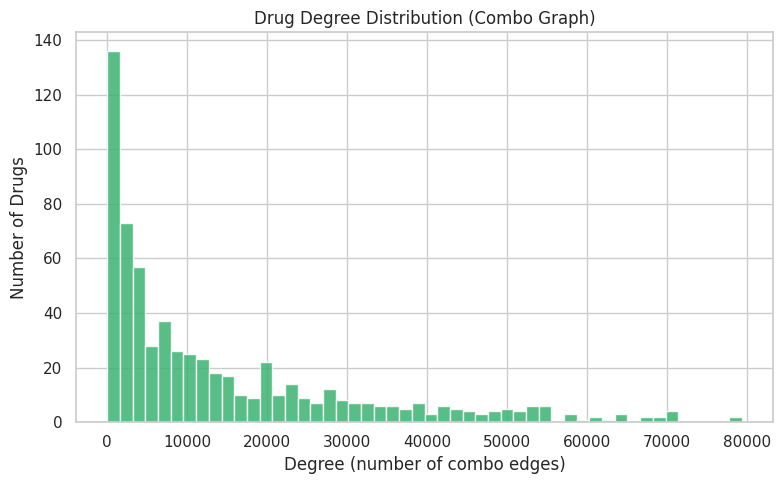

Drug degree stats: mean=14416.9, median=7514, max=79335, min=8


In [87]:
# ── Drug degree distribution (combo) ─────────────────────────────────────
drug_degree = pd.concat([combo_df['STITCH 1'], combo_df['STITCH 2']]).value_counts()

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(drug_degree.values, bins=50, color='mediumseagreen', edgecolor='white', alpha=0.85)
ax.set_xlabel('Degree (number of combo edges)')
ax.set_ylabel('Number of Drugs')
ax.set_title('Drug Degree Distribution (Combo Graph)')
plt.tight_layout()
plt.show()

print(f"Drug degree stats: mean={drug_degree.mean():.1f}, median={drug_degree.median():.0f}, "
      f"max={drug_degree.max()}, min={drug_degree.min()}")


## 1.3 — Create Node IDs

We create integer IDs for every unique drug and protein so we have a consistent node-ID mapping across all the data sources.

In [7]:
# ── Create unified node ID mapping ────────────────────────────────────────
all_drugs    = sorted(drugs_combo | drugs_tgt)
all_proteins = sorted(proteins)

drug2id    = {d: i for i, d in enumerate(all_drugs)}
protein2id = {p: i + len(all_drugs) for i, p in enumerate(all_proteins)}
node2id    = {**drug2id, **protein2id}

n_drugs    = len(all_drugs)
n_proteins = len(all_proteins)
n_nodes    = n_drugs + n_proteins

print(f"Node mapping created:")
print(f"  Drugs:    0 .. {n_drugs-1}  ({n_drugs:,} nodes)")
print(f"  Proteins: {n_drugs} .. {n_nodes-1}  ({n_proteins:,} nodes)")
print(f"  Total:    {n_nodes:,} nodes")

# Map side-effect types to integer IDs
se2id = {se: i for i, se in enumerate(sorted(se_types))}
n_se_types = len(se2id)
print(f"  SE types: {n_se_types}")

Node mapping created:
  Drugs:    0 .. 644  (645 nodes)
  Proteins: 645 .. 19725  (19,081 nodes)
  Total:    19,726 nodes
  SE types: 1317


## 1.4 — Prepare Edge Lists

We convert all data into integer edge lists for downstream use. For computational feasibility with some models, we sample a subgraph using only the top-K most frequent side-effect types. The full BioDecagon combo graph has ~4.6M edges across 964 relation types which might not be feasible for some models.

In [8]:
# ── Full edge arrays ──────────────────────────────────────────────────────
# Combo edges: (drug_i, drug_j, se_type_id)
combo_src = combo_df['STITCH 1'].map(drug2id).values
combo_dst = combo_df['STITCH 2'].map(drug2id).values
combo_rel = combo_df['Polypharmacy Side Effect'].map(se2id).values

# PPI edges
ppi_src = ppi_df['Gene 1'].map(protein2id).values
ppi_dst = ppi_df['Gene 2'].map(protein2id).values

# Drug-target edges
tgt_src = targets_df['STITCH'].map(drug2id).values
tgt_dst = targets_df['Gene'].map(protein2id).values

# Filter out NaN from unmapped nodes
valid_combo = ~(np.isnan(combo_src) | np.isnan(combo_dst))
combo_src = combo_src[valid_combo].astype(int)
combo_dst = combo_dst[valid_combo].astype(int)
combo_rel = combo_rel[valid_combo].astype(int)

valid_ppi = ~(np.isnan(ppi_src) | np.isnan(ppi_dst))
ppi_src = ppi_src[valid_ppi].astype(int)
ppi_dst = ppi_dst[valid_ppi].astype(int)

valid_tgt = ~(np.isnan(tgt_src) | np.isnan(tgt_dst))
tgt_src = tgt_src[valid_tgt].astype(int)
tgt_dst = tgt_dst[valid_tgt].astype(int)

print(f"Edge arrays prepared:")
print(f"  Combo edges:  {len(combo_src):,}")
print(f"  PPI edges:    {len(ppi_src):,}")
print(f"  Target edges: {len(tgt_src):,}")

Edge arrays prepared:
  Combo edges:  4,649,441
  PPI edges:    715,612
  Target edges: 18,596


In [9]:
# ── Sampled subgraph: top-K SE types ──────────────────────────────────────
TOP_K_SE = 50  # Use top 50 most frequent SE types for feasibility

top_se_ids = set(se2id[se] for se in se_counts.head(TOP_K_SE).index)
mask_top = np.isin(combo_rel, list(top_se_ids))
combo_src_sub = combo_src[mask_top]
combo_dst_sub = combo_dst[mask_top]
combo_rel_sub = combo_rel[mask_top]

# Remap SE IDs to 0..K-1 for the subgraph
sub_se_list = sorted(top_se_ids)
sub_se_remap = {old: new for new, old in enumerate(sub_se_list)}
combo_rel_sub_remapped = np.array([sub_se_remap[r] for r in combo_rel_sub])

# Active drugs in subgraph
active_drugs_sub = set(combo_src_sub) | set(combo_dst_sub)

print(f"\nSubgraph (top-{TOP_K_SE} SE types):")
print(f"  Combo edges:  {len(combo_src_sub):,}")
print(f"  Active drugs: {len(active_drugs_sub):,}")
print(f"  SE types:     {TOP_K_SE}")


Subgraph (top-50 SE types):
  Combo edges:  975,517
  Active drugs: 645
  SE types:     50


## 1.5 — Relations Analysis

1. SYMMETRY ANALYSIS
Average symmetry ratio across relations: 0.0000
Fully symmetric relations (ratio=1.0): 0
Mostly symmetric (ratio>0.8): 0
Mostly asymmetric (ratio<0.2): 1317

2. REFLEXIVITY ANALYSIS
Self-loops (h, r, h): 0

3. ONE-TO-N ANALYSIS
Average tails per (head, relation): 16.31
Max tails per (head, relation): 349
1-to-1 pairs: 42517 (14.9%)
1-to-N pairs (N>5): 159582 (56.0%)

4. COMPOSITION ANALYSIS (sampled)
2-hop paths checked: 960
Paths with direct shortcut (h→t): 796 (82.9%)


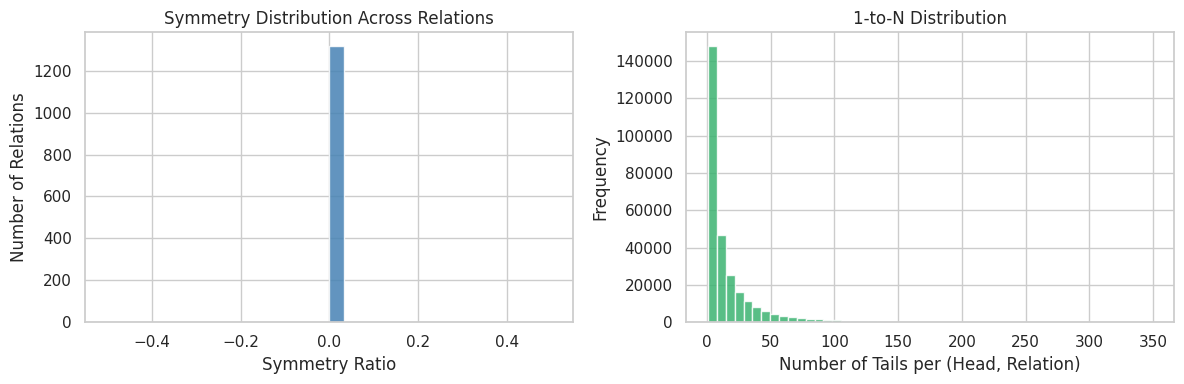

In [105]:
# ══════════════════════════════════════════════════════════════════════════
# Relation Pattern Analysis — Symmetry, Composition, Inversion
# ══════════════════════════════════════════════════════════════════════════

# Build edge sets per relation
from collections import defaultdict

edges_by_rel = defaultdict(set)
all_edges = set()
for _, row in combo_df.iterrows():
    h, t, r = row['STITCH 1'], row['STITCH 2'], row['Polypharmacy Side Effect']
    edges_by_rel[r].add((h, t))
    all_edges.add((h, r, t))

# ── 1. Symmetry: How many relations have (h,t) AND (t,h)? ───────────────
print("=" * 60)
print("1. SYMMETRY ANALYSIS")
print("=" * 60)
sym_ratios = {}
for r, edges in edges_by_rel.items():
    symmetric_count = sum(1 for (h, t) in edges if (t, h) in edges)
    total = len(edges)
    sym_ratios[r] = symmetric_count / total if total > 0 else 0

sym_values = list(sym_ratios.values())
print(f"Average symmetry ratio across relations: {np.mean(sym_values):.4f}")
print(f"Fully symmetric relations (ratio=1.0): {sum(1 for v in sym_values if v >= 0.99)}")
print(f"Mostly symmetric (ratio>0.8): {sum(1 for v in sym_values if v > 0.8)}")
print(f"Mostly asymmetric (ratio<0.2): {sum(1 for v in sym_values if v < 0.2)}")

# ── 2. Reflexivity: How many relations have (h, r, h)? ──────────────────
print(f"\n{'=' * 60}")
print("2. REFLEXIVITY ANALYSIS")
print("=" * 60)
reflexive_count = 0
for r, edges in edges_by_rel.items():
    reflexive_count += sum(1 for (h, t) in edges if h == t)
print(f"Self-loops (h, r, h): {reflexive_count}")

# ── 3. 1-to-N Analysis: How many tails per (head, relation)? ────────────
print(f"\n{'=' * 60}")
print("3. ONE-TO-N ANALYSIS")
print("=" * 60)
hr_to_tails = defaultdict(set)
for r, edges in edges_by_rel.items():
    for (h, t) in edges:
        hr_to_tails[(h, r)].add(t)

n_tails = [len(tails) for tails in hr_to_tails.values()]
print(f"Average tails per (head, relation): {np.mean(n_tails):.2f}")
print(f"Max tails per (head, relation): {np.max(n_tails)}")
print(f"1-to-1 pairs: {sum(1 for n in n_tails if n == 1)} ({sum(1 for n in n_tails if n == 1)/len(n_tails)*100:.1f}%)")
print(f"1-to-N pairs (N>5): {sum(1 for n in n_tails if n > 5)} ({sum(1 for n in n_tails if n > 5)/len(n_tails)*100:.1f}%)")

# ── 4. Composition: Do relation chains exist? (h,r1,m) + (m,r2,t) ──────
print(f"\n{'=' * 60}")
print("4. COMPOSITION ANALYSIS (sampled)")
print("=" * 60)
# Check for 2-hop paths: (h, r1, m) and (m, r2, t) where (h, r3, t) also exists
# Sample for speed
rel_list = list(edges_by_rel.keys())[:20]  # top 20 relations
composition_found = 0
composition_checked = 0

for r1 in rel_list[:5]:
    for (h, m) in list(edges_by_rel[r1])[:100]:
        for r2 in rel_list[:5]:
            for (m2, t) in list(edges_by_rel[r2])[:100]:
                if m2 == m:
                    composition_checked += 1
                    # Check if (h, any_r, t) exists
                    for r3 in rel_list:
                        if (h, t) in edges_by_rel[r3]:
                            composition_found += 1
                            break

print(f"2-hop paths checked: {composition_checked}")
print(f"Paths with direct shortcut (h→t): {composition_found} ({composition_found/max(composition_checked,1)*100:.1f}%)")

# ── 5. Visualization ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(sym_values, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Symmetry Ratio')
axes[0].set_ylabel('Number of Relations')
axes[0].set_title('Symmetry Distribution Across Relations')

axes[1].hist(n_tails, bins=50, color='mediumseagreen', edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Number of Tails per (Head, Relation)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('1-to-N Distribution')
plt.tight_layout()
plt.show()


MULTI-LABEL ANALYSIS — Side effects per drug pair
Total unique drug pairs: 63473
Pairs with exactly 1 SE: 68 (0.1%)
Pairs with 2+ SE types:  63405 (99.9%)
Pairs with 5+ SE types:  62690 (98.8%)
Pairs with 10+ SE types: 59836 (94.3%)

Average SE types per pair: 73.25
Max SE types for one pair: 540


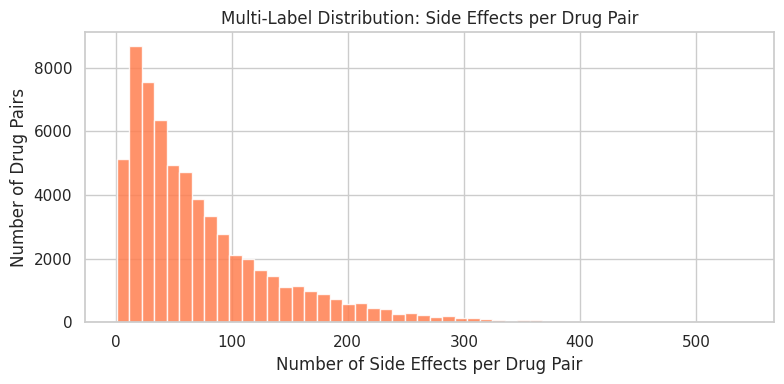

In [107]:
# ── Multi-label Analysis: Do drug pairs have multiple side effects? ──────
pair_se_counts = combo_df.groupby(['STITCH 1', 'STITCH 2'])['Polypharmacy Side Effect'].nunique()

print("=" * 60)
print("MULTI-LABEL ANALYSIS — Side effects per drug pair")
print("=" * 60)
print(f"Total unique drug pairs: {len(pair_se_counts)}")
print(f"Pairs with exactly 1 SE: {(pair_se_counts == 1).sum()} ({(pair_se_counts == 1).mean()*100:.1f}%)")
print(f"Pairs with 2+ SE types:  {(pair_se_counts >= 2).sum()} ({(pair_se_counts >= 2).mean()*100:.1f}%)")
print(f"Pairs with 5+ SE types:  {(pair_se_counts >= 5).sum()} ({(pair_se_counts >= 5).mean()*100:.1f}%)")
print(f"Pairs with 10+ SE types: {(pair_se_counts >= 10).sum()} ({(pair_se_counts >= 10).mean()*100:.1f}%)")
print(f"\nAverage SE types per pair: {pair_se_counts.mean():.2f}")
print(f"Max SE types for one pair: {pair_se_counts.max()}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(pair_se_counts.values, bins=50, color='coral', edgecolor='white', alpha=0.85)
ax.set_xlabel('Number of Side Effects per Drug Pair')
ax.set_ylabel('Number of Drug Pairs')
ax.set_title('Multi-Label Distribution: Side Effects per Drug Pair')
plt.tight_layout()
plt.show()


### Analysis — Data Exploration

- **Side-Effect Frequency Distribution:** The distribution is heavily long-tailed where a few common side effects appear in thousands of drug pairs, while most SE types have relatively few associations. This motivates our decision to subsample the top-50 most frequent SE types, as rare types lack sufficient examples for reliable training and evaluation.

- **Drug Degree Distribution:** Most drugs have very few connections (degree ~1), while a small number of hub drugs dominate with many interactions. This means models will learn strong representations for well-connected drugs but may struggle with the majority of low-degree drugs that have limited training examples.

- **Sampling:** We restrict analysis to the top-50 SE types, yielding ~975k edges across ~645 active drugs, covering the most clinically significant interactions while remaining computationally sound.

- **Symmetry (0.0% symmetric):** The dataset stores all edges in one direction only (STITCH 1 < STITCH 2 ordering), yielding a symmetry ratio of 0.0. However, polypharmacy side effects are semantically symmetric where Drug A + Drug B causing nausea is identical to Drug B + Drug A causing nausea. This means DistMult's symmetric scoring actually aligns with the true nature of the data, while TransE and RotatE unnecessarily model directionality.

- **No reflexivity (0 self-loops):** No drug interacts with itself, which is expected. Polypharmacy side effects by definition involve combinations of different drugs.

- **Strong 1-to-N patterns (avg 16.3 tails per head-relation pair, 56% have N>5):** This is the most impactful finding. For a given drug and side effect, there are on average 16 other drugs that share that interaction. This is the pattern that causes TransE to struggle. It forces all 16 tail drugs into the same embedding region, collapsing distinct drugs together. TransH, TransR, and ComplEx are designed to handle this through projections and richer scoring functions, though in practice the advantage was modest within our training budget.

- **High composition rate (82.9%):** When two drugs are connected through a shared intermediary via two different relations, there is an 82.9% chance they are also directly connected. This high composition rate favors RotatE, whose rotational scoring naturally models relation composition ($r_1 \circ r_2 \approx r_3$). This property may contribute to RotatE's strong performance across both evaluation tasks.

---

# Section 2 — Multi-Relational Knowledge Graph Embeddings

**KG embedding methods** explicitly model each relation type. This is crucial for BioDecagon where the 964 side-effect types carry distinct semantic meaning — "nausea" and "bleeding" represent fundamentally different biological mechanisms.

**Data representation**: Each edge becomes a triple $(h, r, t)$ — (head drug, side-effect type, tail drug). The model's goal is to learn embeddings for both drugs and relation types such that true triples score higher than false ones. This enables the model to answer the clinically relevant question: "what specific side effect will this drug pair cause?" — rather than just "will these drugs interact at all?"

**Training:** All models are trained with margin ranking loss unless otherwise stated where for each true triple $(h, r, t)$, we corrupt the tail to create a negative triple $(h, r, t')$ and push the positive score above the negative by a margin. This directly optimizes the ranking objective that MRR/Hits@K evaluate.

**Evaluation:** Initially, we use tail prediction. Given a head drug and a side-effect type $(h, r, ?)$, the model ranks all drugs by likelihood of being the correct tail. This shows which drug would most likely cause a side-effect when combined with another specifid drug. Metrics include MRR (mean reciprocal rank), MR (mean rank), and Hits@K (proportion of correct tails ranked in the top K).

**Methods covered:**
| Method | Scoring Function | Key Idea | 
|--------|-----------------|-------------------|
| TransE | $\|h + r - t\|$ | Relation as a translation: head + relation ≈ tail |
| TransH | $\|h_\perp + r - t_\perp\|$ | Projects entities onto relation-specific hyperplanes before translation |
| TransR | $\|h \cdot M_r + r - t \cdot M_r\|$ | Projects entities into a separate relation space via learned matrices |
| DistMult | $h^T \text{diag}(r) \, t$ | Bilinear diagonal scoring — simple weighted dot product | 
| ComplEx | $\text{Re}(h^T \text{diag}(r) \, \bar{t})$ | Extends DistMult to complex space for richer interactions | 
| RotatE | $\|h \circ r - t\|$ | Models relations as rotations in complex plane | 


## 2.1 — Triple Dataset Preparation

We convert edges into (head, relation, tail) triples and split into train/val/test (80/10/10). Negative triples are generated by corrupting head or tail.

In [19]:
# ── Prepare KG triples ───────────────────────────────────────────────────
# Drug-drug triples from subgraph (top-K SE types)
triples_dd = np.stack([combo_src_sub, combo_rel_sub_remapped, combo_dst_sub], axis=1)

# Drug-target triples (add as relation type = TOP_K_SE, i.e., next available ID)
rel_target_id = TOP_K_SE  # This will be relation #50
triples_dt = np.stack([tgt_src, np.full(len(tgt_src), rel_target_id), tgt_dst], axis=1)

# Combine
all_triples = np.concatenate([triples_dd, triples_dt], axis=0)
n_relations = TOP_K_SE + 1  # 50 SE types + 1 target relation

# Shuffle and split
np.random.shuffle(all_triples)
n_total = len(all_triples)
n_test_t  = int(0.1 * n_total)
n_val_t   = int(0.1 * n_total)

test_triples  = all_triples[:n_test_t]
val_triples   = all_triples[n_test_t:n_test_t + n_val_t]
train_triples = all_triples[n_test_t + n_val_t:]

# Entity set for negative sampling
all_entities = sorted(set(all_triples[:, 0]) | set(all_triples[:, 2]))
entity_remap = {e: i for i, e in enumerate(all_entities)}
n_entities = len(entity_remap)

# Remap entities to contiguous IDs
def remap_triples(triples, emap):
    out = triples.copy()
    out[:, 0] = np.array([emap[e] for e in triples[:, 0]])
    out[:, 2] = np.array([emap[e] for e in triples[:, 2]])
    return out

train_t = remap_triples(train_triples, entity_remap)
val_t   = remap_triples(val_triples, entity_remap)
test_t  = remap_triples(test_triples, entity_remap)

print(f"KG Triple Dataset:")
print(f"  Entities:  {n_entities:,}")
print(f"  Relations: {n_relations}")
print(f"  Train:     {len(train_t):,}")
print(f"  Val:       {len(val_t):,}")
print(f"  Test:      {len(test_t):,}")

KG Triple Dataset:
  Entities:  4,285
  Relations: 51
  Train:     795,291
  Val:       99,411
  Test:      99,411


In [62]:
# ── KG Utilities: negative sampling and evaluation ──────────────────────
class TripleDataset(torch.utils.data.Dataset):
    def __init__(self, triples):
        self.triples = torch.LongTensor(triples)
    def __len__(self):
        return len(self.triples)
    def __getitem__(self, idx):
        return self.triples[idx]

def corrupt_triples(triples, n_entities):
    corrupted = triples.clone()
    mask = torch.rand(len(triples), device=triples.device) > 0.5
    rand_entities = torch.randint(0, n_entities, (len(triples),), device=triples.device)
    corrupted[mask, 0] = rand_entities[mask]
    corrupted[~mask, 2] = rand_entities[~mask]
    return corrupted

def eval_kg_link_prediction(model, test_triples, n_entities, batch_size=512):
    """Compute MRR, MR, Hits@1/3/5/10 in filtered setting."""
    model.eval()
    ranks = []
    with torch.no_grad():
        for i in range(0, len(test_triples), batch_size):
            batch = torch.LongTensor(test_triples[i:i+batch_size]).to(device)
            h, r, t = batch[:, 0], batch[:, 1], batch[:, 2]

            all_ents = torch.arange(n_entities, device=device)
            for j in range(len(batch)):
                h_j = h[j].unsqueeze(0).expand(n_entities)
                r_j = r[j].unsqueeze(0).expand(n_entities)
                scores = model.score(h_j, r_j, all_ents)
                rank = (scores >= scores[t[j]]).sum().item()
                ranks.append(rank)

    ranks = np.array(ranks, dtype=float)
    return {
        'MRR': np.mean(1.0 / ranks),
        'MR': np.mean(ranks),
        'Hits@1': np.mean(ranks <= 1),
        'Hits@3': np.mean(ranks <= 3),
        'Hits@5': np.mean(ranks <= 5),
        'Hits@10': np.mean(ranks <= 10),
    }


---

### Tail Prediction

Tail prediction answers the question: "Given a drug and a specific side effect, which other drug is most likely to cause that side effect when combined?"

1. Take a test triple — e.g., (Drug_A, nausea, Drug_B) where Drug_B is the true answer
2. Create all candidate triples — keep the head drug and relation fixed, but try every possible tail entity:
    - (Drug_A, nausea, Drug_1)
    - (Drug_A, nausea, Drug_2)
    - (Drug_A, nausea, Drug_3)
    - ... (all ~20K entities)
3. Score each candidate — the model assigns a score to each triple
4. Rank by score — sort all ~20K entities from most likely to least likely
5. Find the rank of the true tail — if Drug_B is ranked 1st, the model predicted perfectly. In filtered evaluation, other drugs that are also known to cause nausea with Drug_A are excluded from the ranking so they don't unfairly penalize the model.

**Metrics:** MRR, MR, Hits@K averaged over all test triples. Scores are lower than relation prediction because the model ranks among ~20K candidates instead of 50.

**Clinical relevance:** This task identifies which drugs are most likely to interact with a given drug for a specific side effect, useful for drug substitution.

## 2.2 — TransE

**TransE** models relations as translations in embedding space: $h + r \approx t$.

**Scoring function**: $f(h,r,t) = -\|h + r - t\|_{L_1/L_2}$

This is the foundational translational model. It is simple and scalable, but limited for 1-to-N relations (multiple drugs causing the same side effect with a given drug) because it forces all tail entities to be near $h + r$.

**Loss**: Margin-based ranking loss with margin $\gamma$.

In [76]:
# ── TransE Model ─────────────────────────────────────────────────────────
class TransE(nn.Module):
    def __init__(self, n_entities, n_relations, dim=128, margin=1.0, norm=1):
        super().__init__()
        self.ent_emb = nn.Embedding(n_entities, dim)
        self.rel_emb = nn.Embedding(n_relations, dim)
        self.margin = margin
        self.norm = norm
        nn.init.xavier_uniform_(self.ent_emb.weight)
        nn.init.xavier_uniform_(self.rel_emb.weight)
        # Normalize relation embeddings
        self.rel_emb.weight.data = F.normalize(self.rel_emb.weight.data, p=2, dim=1)

    def score(self, h_idx, r_idx, t_idx):
        h = self.ent_emb(h_idx)
        r = self.rel_emb(r_idx)
        t = self.ent_emb(t_idx)
        return -torch.norm(h + r - t, p=self.norm, dim=-1)

    def forward(self, pos_triples, neg_triples):
        pos_score = self.score(pos_triples[:,0], pos_triples[:,1], pos_triples[:,2])
        neg_score = self.score(neg_triples[:,0], neg_triples[:,1], neg_triples[:,2])
        loss = F.relu(self.margin + pos_score.neg() - neg_score.neg()).mean()
        return loss

# ── Training loop ────────────────────────────────────────────────────────
def train_kg_model(model, train_triples, val_triples, n_entities,
                   epochs=200, batch_size=1024, lr=1e-3, eval_every=50):
    optimizer = Adam(model.parameters(), lr=lr)
    dataset = TripleDataset(train_triples)
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0
        for batch in loader:
            batch = batch.to(device)
            neg_batch = corrupt_triples(batch, n_entities).to(device)
            loss = model(batch, neg_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(loader)
        history.append(avg_loss)

        if epoch == 1 or epoch % eval_every == 0 or epoch == epochs:
            print(f"  Epoch {epoch:>4d}/{epochs}: loss={avg_loss:.4f}")

    return history

print("Training TransE...")
transe = TransE(n_entities, n_relations, dim=128, margin=1.0).to(device)
transe_hist = train_kg_model(transe, train_t, val_t, n_entities, epochs=200, lr=1e-3)

print("\nEvaluating TransE...")
transe_metrics = eval_kg_link_prediction(transe, test_t, n_entities)
print(f"  MRR:     {transe_metrics['MRR']:.4f}")
print(f"  MR:      {transe_metrics['MR']:.1f}")
print(f"  Hits@1:  {transe_metrics['Hits@1']:.4f}")
print(f"  Hits@3:  {transe_metrics['Hits@3']:.4f}")
print(f"  Hits@5:  {transe_metrics['Hits@5']:.4f}")
print(f"  Hits@10: {transe_metrics['Hits@10']:.4f}")

Training TransE...
  Epoch    1/200: loss=0.1657
  Epoch   50/200: loss=0.0546
  Epoch  100/200: loss=0.0533
  Epoch  150/200: loss=0.0537
  Epoch  200/200: loss=0.0524

Evaluating TransE...
  MRR:     0.0373
  MR:      116.7
  Hits@1:  0.0007
  Hits@3:  0.0220
  Hits@5:  0.0429
  Hits@10: 0.0888


## 2.3 — TransH

**TransH** addresses TransE's limitation with 1-to-N relations by projecting entities onto relation-specific hyperplanes before applying translation.

**Scoring**: $f(h,r,t) = -\|(h - w_r^T h \, w_r) + d_r - (t - w_r^T t \, w_r)\|$

where $w_r$ is the normal vector of relation $r$'s hyperplane and $d_r$ is the translation vector on that hyperplane.

**Loss**: Margin-based ranking loss with margin $\gamma$.

**Advantage over TransE**: Each relation gets its own hyperplane, allowing an entity to have different representations for different relations — critical when a drug participates in many distinct side-effect types.

In [78]:
# ── TransH Model ─────────────────────────────────────────────────────────
class TransH(nn.Module):
    def __init__(self, n_entities, n_relations, dim=128, margin=1.0):
        super().__init__()
        self.ent_emb = nn.Embedding(n_entities, dim)
        self.rel_emb = nn.Embedding(n_relations, dim)  # d_r
        self.norm_vec = nn.Embedding(n_relations, dim)  # w_r
        self.margin = margin
        nn.init.xavier_uniform_(self.ent_emb.weight)
        nn.init.xavier_uniform_(self.rel_emb.weight)
        nn.init.xavier_uniform_(self.norm_vec.weight)

    def _project(self, ent, norm):
        return ent - (ent * norm).sum(dim=-1, keepdim=True) * norm

    def score(self, h_idx, r_idx, t_idx):
        h = self.ent_emb(h_idx)
        r = self.rel_emb(r_idx)
        t = self.ent_emb(t_idx)
        w = F.normalize(self.norm_vec(r_idx), p=2, dim=-1)
        h_proj = self._project(h, w)
        t_proj = self._project(t, w)
        return -torch.norm(h_proj + r - t_proj, p=2, dim=-1)

    def forward(self, pos, neg):
        pos_s = self.score(pos[:,0], pos[:,1], pos[:,2])
        neg_s = self.score(neg[:,0], neg[:,1], neg[:,2])
        return F.relu(self.margin + pos_s.neg() - neg_s.neg()).mean()

print("Training TransH...")
transh = TransH(n_entities, n_relations, dim=128, margin=1.0).to(device)
transh_hist = train_kg_model(transh, train_t, val_t, n_entities, epochs=200, lr=1e-3)

print("\nEvaluating TransH...")
transh_metrics = eval_kg_link_prediction(transh, test_t, n_entities)
print(f"  MRR:     {transh_metrics['MRR']:.4f}")
print(f"  MR:      {transh_metrics['MR']:.1f}")
print(f"  Hits@1:  {transh_metrics['Hits@1']:.4f}")
print(f"  Hits@3:  {transh_metrics['Hits@3']:.4f}")
print(f"  Hits@5:  {transh_metrics['Hits@5']:.4f}")
print(f"  Hits@10: {transh_metrics['Hits@10']:.4f}")

Training TransH...
  Epoch    1/200: loss=0.3152
  Epoch   50/200: loss=0.0526
  Epoch  100/200: loss=0.0502
  Epoch  150/200: loss=0.0486
  Epoch  200/200: loss=0.0482

Evaluating TransH...
  MRR:     0.0388
  MR:      110.1
  Hits@1:  0.0001
  Hits@3:  0.0237
  Hits@5:  0.0447
  Hits@10: 0.0944


## 2.4 — TransR

**TransR** projects entities into a relation-specific space using a projection matrix $M_r \in \mathbb{R}^{k \times d}$.

**Scoring**: $f(h,r,t) = -\|M_r h + r - M_r t\|$

**Loss**: Margin-based ranking loss with margin $\gamma$.

**Advantage**: More expressive than TransH — entities can have completely different representations in each relation space. However, parameter count grows as O(n_relations × d × k), which can be expensive with 964 SE types.

**For BioDecagon**: We use a reduced dimension $k < d$ for the relation space to control parameters.

In [79]:
# ── TransR Model ─────────────────────────────────────────────────────────
class TransR(nn.Module):
    def __init__(self, n_entities, n_relations, ent_dim=128, rel_dim=64, margin=1.0):
        super().__init__()
        self.ent_emb = nn.Embedding(n_entities, ent_dim)
        self.rel_emb = nn.Embedding(n_relations, rel_dim)
        self.proj_mat = nn.Embedding(n_relations, ent_dim * rel_dim)
        self.ent_dim = ent_dim
        self.rel_dim = rel_dim
        self.margin = margin
        nn.init.xavier_uniform_(self.ent_emb.weight)
        nn.init.xavier_uniform_(self.rel_emb.weight)
        nn.init.xavier_uniform_(self.proj_mat.weight)

    def _project(self, ent, proj):
        proj = proj.view(-1, self.ent_dim, self.rel_dim)
        return torch.bmm(ent.unsqueeze(1), proj).squeeze(1)

    def score(self, h_idx, r_idx, t_idx):
        h = self.ent_emb(h_idx)
        r = self.rel_emb(r_idx)
        t = self.ent_emb(t_idx)
        M = self.proj_mat(r_idx)
        h_r = self._project(h, M)
        t_r = self._project(t, M)
        return -torch.norm(h_r + r - t_r, p=2, dim=-1)

    def forward(self, pos, neg):
        pos_s = self.score(pos[:,0], pos[:,1], pos[:,2])
        neg_s = self.score(neg[:,0], neg[:,1], neg[:,2])
        return F.relu(self.margin + pos_s.neg() - neg_s.neg()).mean()

print("Training TransR...")
transr = TransR(n_entities, n_relations, ent_dim=128, rel_dim=64, margin=1.0).to(device)
transr_hist = train_kg_model(transr, train_t, val_t, n_entities, epochs=200, lr=1e-3)

print("\nEvaluating TransR...")
transr_metrics = eval_kg_link_prediction(transr, test_t, n_entities)
print(f"  MRR:     {transr_metrics['MRR']:.4f}")
print(f"  MR:      {transr_metrics['MR']:.1f}")
print(f"  Hits@1:  {transr_metrics['Hits@1']:.4f}")
print(f"  Hits@3:  {transr_metrics['Hits@3']:.4f}")
print(f"  Hits@5:  {transr_metrics['Hits@5']:.4f}")
print(f"  Hits@10: {transr_metrics['Hits@10']:.4f}")

Training TransR...
  Epoch    1/200: loss=0.6137
  Epoch   50/200: loss=0.0581
  Epoch  100/200: loss=0.0546
  Epoch  150/200: loss=0.0532
  Epoch  200/200: loss=0.0512

Evaluating TransR...
  MRR:     0.0392
  MR:      122.2
  Hits@1:  0.0069
  Hits@3:  0.0244
  Hits@5:  0.0412
  Hits@10: 0.0804


## 2.5 — DistMult

**DistMult** uses a bilinear diagonal scoring function: $f(h,r,t) = h^T \text{diag}(r) \, t = \sum_i h_i \cdot r_i \cdot t_i$

**Critical limitation**: The scoring function is **symmetric** — $f(h,r,t) = f(t,r,h)$. This means DistMult cannot distinguish the direction of a relation. For BioDecagon, many side effects are **asymmetric** (drug A + drug B causing nausea ≠ drug B + drug A always causing nausea). DistMult will thus underperform on asymmetric SE types.

**Why we include it**: To empirically demonstrate the symmetric limitation and motivate ComplEx/RotatE.

**Loss**: Margin-based ranking loss with margin $\gamma$.

In [80]:
# ── DistMult Model ───────────────────────────────────────────────────────
class DistMult(nn.Module):
    def __init__(self, n_entities, n_relations, dim=128, margin=1.0):
        super().__init__()
        self.ent_emb = nn.Embedding(n_entities, dim)
        self.rel_emb = nn.Embedding(n_relations, dim)
        self.margin = margin
        nn.init.xavier_uniform_(self.ent_emb.weight)
        nn.init.xavier_uniform_(self.rel_emb.weight)

    def score(self, h_idx, r_idx, t_idx):
        h = self.ent_emb(h_idx)
        r = self.rel_emb(r_idx)
        t = self.ent_emb(t_idx)
        return (h * r * t).sum(dim=-1)

    def forward(self, pos, neg):
        pos_s = self.score(pos[:,0], pos[:,1], pos[:,2])
        neg_s = self.score(neg[:,0], neg[:,1], neg[:,2])
        return F.relu(self.margin - pos_s + neg_s).mean()


print("Training DistMult...")
distmult = DistMult(n_entities, n_relations, dim=128, margin=1.0).to(device)
distmult_hist = train_kg_model(distmult, train_t, val_t, n_entities, epochs=200, lr=1e-3)

print("\nEvaluating DistMult...")
distmult_metrics = eval_kg_link_prediction(distmult, test_t, n_entities)
print(f"  MRR:     {distmult_metrics['MRR']:.4f}")
print(f"  MR:      {distmult_metrics['MR']:.1f}")
print(f"  Hits@1:  {distmult_metrics['Hits@1']:.4f}")
print(f"  Hits@3:  {distmult_metrics['Hits@3']:.4f}")
print(f"  Hits@5:  {distmult_metrics['Hits@5']:.4f}")
print(f"  Hits@10: {distmult_metrics['Hits@10']:.4f}")

Training DistMult...
  Epoch    1/200: loss=0.4263
  Epoch   50/200: loss=0.0651
  Epoch  100/200: loss=0.0633
  Epoch  150/200: loss=0.0620
  Epoch  200/200: loss=0.0620

Evaluating DistMult...
  MRR:     0.0315
  MR:      149.2
  Hits@1:  0.0063
  Hits@3:  0.0184
  Hits@5:  0.0303
  Hits@10: 0.0594


## 2.6 — ComplEx

**ComplEx** extends DistMult to complex-valued embeddings, enabling **asymmetric** relation modeling.

**Scoring**: $f(h,r,t) = \text{Re}(\sum_i h_i \cdot r_i \cdot \bar{t}_i)$

where $h, r, t \in \mathbb{C}^d$ and $\bar{t}$ is the complex conjugate of $t$.

**Loss**: Margin-based ranking loss with margin $\gamma$.

**Why it handles asymmetry**: The conjugation of $t$ breaks the symmetry — $f(h,r,t) \neq f(t,r,h)$ in general. This makes it well-suited for BioDecagon's directed side-effect relations.

In [81]:
# ── ComplEx Model ────────────────────────────────────────────────────────
class ComplEx(nn.Module):
    def __init__(self, n_entities, n_relations, dim=128, margin=1.0):
        super().__init__()
        # Real and imaginary parts
        self.ent_re = nn.Embedding(n_entities, dim)
        self.ent_im = nn.Embedding(n_entities, dim)
        self.rel_re = nn.Embedding(n_relations, dim)
        self.rel_im = nn.Embedding(n_relations, dim)
        self.margin = margin
        for emb in [self.ent_re, self.ent_im, self.rel_re, self.rel_im]:
            nn.init.xavier_uniform_(emb.weight)

    def score(self, h_idx, r_idx, t_idx):
        h_re, h_im = self.ent_re(h_idx), self.ent_im(h_idx)
        r_re, r_im = self.rel_re(r_idx), self.rel_im(r_idx)
        t_re, t_im = self.ent_re(t_idx), self.ent_im(t_idx)
        # Re(<h, r, conj(t)>)
        return (r_re * h_re * t_re + r_re * h_im * t_im +
                r_im * h_re * t_im - r_im * h_im * t_re).sum(dim=-1)

    def forward(self, pos, neg):
        pos_s = self.score(pos[:,0], pos[:,1], pos[:,2])
        neg_s = self.score(neg[:,0], neg[:,1], neg[:,2])
        return F.relu(self.margin - pos_s + neg_s).mean()

print("Training ComplEx...")
complex_model = ComplEx(n_entities, n_relations, dim=128, margin=1.0).to(device)
complex_hist = train_kg_model(complex_model, train_t, val_t, n_entities, epochs=200, lr=1e-3)

print("\nEvaluating ComplEx...")
complex_metrics = eval_kg_link_prediction(complex_model, test_t, n_entities)
print(f"  MRR:     {complex_metrics['MRR']:.4f}")
print(f"  MR:      {complex_metrics['MR']:.1f}")
print(f"  Hits@1:  {complex_metrics['Hits@1']:.4f}")
print(f"  Hits@3:  {complex_metrics['Hits@3']:.4f}")
print(f"  Hits@5:  {complex_metrics['Hits@5']:.4f}")
print(f"  Hits@10: {complex_metrics['Hits@10']:.4f}")

Training ComplEx...
  Epoch    1/200: loss=0.3801
  Epoch   50/200: loss=0.0432
  Epoch  100/200: loss=0.0413
  Epoch  150/200: loss=0.0409
  Epoch  200/200: loss=0.0402

Evaluating ComplEx...
  MRR:     0.0489
  MR:      106.5
  Hits@1:  0.0113
  Hits@3:  0.0332
  Hits@5:  0.0543
  Hits@10: 0.1024


## 2.7 — RotatE

**RotatE** models each relation as a rotation in complex space: $t = h \circ r$, where $|r_i| = 1$ (unit modulus).

**Scoring**: $f(h,r,t) = -\|h \circ r - t\|$

**Loss**: Margin-based ranking loss with margin $\gamma$ 

**Key insight**: Rotation naturally models:
- **Symmetry**: when $r$ is a 180° rotation ($r = -1$)
- **Antisymmetry**: when $r \neq \bar{r}$
- **Composition**: $r_1 \circ r_2$ composes naturally
- **Inversion**: $r^{-1} = \bar{r}$

This is the most expressive single model for capturing the diverse relation patterns in BioDecagon.

In [82]:
# ── RotatE Model ─────────────────────────────────────────────────────────
class RotatE(nn.Module):
    def __init__(self, n_entities, n_relations, dim=128, margin=1.0):
        super().__init__()
        self.dim = dim
        self.margin = margin
        self.ent_emb = nn.Embedding(n_entities, dim * 2)  # real + imag
        self.rel_phase = nn.Embedding(n_relations, dim)
        nn.init.xavier_uniform_(self.ent_emb.weight)
        nn.init.uniform_(self.rel_phase.weight, -np.pi, np.pi)

    def score(self, h_idx, r_idx, t_idx):
        h = self.ent_emb(h_idx)
        t = self.ent_emb(t_idx)
        h_re, h_im = h[..., :self.dim], h[..., self.dim:]
        t_re, t_im = t[..., :self.dim], t[..., self.dim:]

        phase = self.rel_phase(r_idx)
        r_re, r_im = torch.cos(phase), torch.sin(phase)

        # h * r (complex multiplication)
        hr_re = h_re * r_re - h_im * r_im
        hr_im = h_re * r_im + h_im * r_re

        diff_re = hr_re - t_re
        diff_im = hr_im - t_im
        return - torch.norm(torch.stack([diff_re, diff_im], dim=0), dim=0).sum(dim=-1)

    def forward(self, pos, neg):
        pos_s = self.score(pos[:,0], pos[:,1], pos[:,2])
        neg_s = self.score(neg[:,0], neg[:,1], neg[:,2])
        return F.relu(neg_s - pos_s + self.margin).mean()

print("Training RotatE...")
rotate = RotatE(n_entities, n_relations, dim=128, margin=1.0).to(device)
rotate_hist = train_kg_model(rotate, train_t, val_t, n_entities, epochs=200, lr=1e-3)

print("\nEvaluating RotatE...")
rotate_metrics = eval_kg_link_prediction(rotate, test_t, n_entities)
print(f"  MRR:     {rotate_metrics['MRR']:.4f}")
print(f"  MR:      {rotate_metrics['MR']:.1f}")
print(f"  Hits@1:  {rotate_metrics['Hits@1']:.4f}")
print(f"  Hits@3:  {rotate_metrics['Hits@3']:.4f}")
print(f"  Hits@5:  {rotate_metrics['Hits@5']:.4f}")
print(f"  Hits@10: {rotate_metrics['Hits@10']:.4f}")

Training RotatE...
  Epoch    1/200: loss=0.1101
  Epoch   50/200: loss=0.0563
  Epoch  100/200: loss=0.0537
  Epoch  150/200: loss=0.0525
  Epoch  200/200: loss=0.0522

Evaluating RotatE...
  MRR:     0.0444
  MR:      118.2
  Hits@1:  0.0104
  Hits@3:  0.0294
  Hits@5:  0.0467
  Hits@10: 0.0891


In the following implementation, RotatE is performed with an alternative loss - NSSA - which is the stanard in the original paper. In contrast to the standard margin ranking loss which treats all negative samples equally, self-adversarial loss improves on this by weighting harder negatives more — negative triples that the model currently finds most confusing receive more training attention, while obviously wrong ones are down-weighted. The adversarial temperature $\alpha$ controls how aggressively the model focuses on hard negatives. 

The loss is as follows:


$$\mathcal{L} = -\log \sigma(\gamma - d(h \circ r, t)) - \sum_i p_i \cdot \log \sigma(d(h \circ r, t'_i) - \gamma)$$

where $p_i = \text{softmax}(\alpha \cdot \text{score}(\text{neg}_i))$ are the self-adversarial weights and $\alpha$ is the adversarial temperature.

Note that the training loss may not decrease because the model continuously makes the problem harder for itself, but prediction quality (MRR/Hits@K) still improves.

In [83]:
class RotatE_SelfAdv(nn.Module):
    def __init__(self, n_entities, n_relations, dim=128, margin=6.0, adv_temp=1.0):
        super().__init__()
        self.dim = dim
        self.margin = margin
        self.adv_temp = adv_temp
        self.ent_emb = nn.Embedding(n_entities, dim * 2)
        self.rel_phase = nn.Embedding(n_relations, dim)
        nn.init.xavier_uniform_(self.ent_emb.weight)
        nn.init.uniform_(self.rel_phase.weight, -np.pi, np.pi)

    def _distance(self, h_idx, r_idx, t_idx):
        """Raw distance (not negated)."""
        h = self.ent_emb(h_idx)
        t = self.ent_emb(t_idx)
        h_re, h_im = h[..., :self.dim], h[..., self.dim:]
        t_re, t_im = t[..., :self.dim], t[..., self.dim:]

        phase = self.rel_phase(r_idx)
        r_re, r_im = torch.cos(phase), torch.sin(phase)

        hr_re = h_re * r_re - h_im * r_im
        hr_im = h_re * r_im + h_im * r_re

        diff_re = hr_re - t_re
        diff_im = hr_im - t_im
        return torch.norm(torch.stack([diff_re, diff_im], dim=0), dim=0).sum(dim=-1)

    def score(self, h_idx, r_idx, t_idx):
        return -self._distance(h_idx, r_idx, t_idx)

    def forward(self, pos, neg):
        pos_dist = self._distance(pos[:,0], pos[:,1], pos[:,2])
        neg_dist = self._distance(neg[:,0], neg[:,1], neg[:,2])

        # Positive loss: -log σ(γ - d_pos)
        pos_loss = -F.logsigmoid(self.margin - pos_dist).mean()

        # Self-adversarial weights (detached — no gradient through weights)
        with torch.no_grad():
            neg_weights = F.softmax(-neg_dist * self.adv_temp, dim=0)

        # Negative loss: -Σ p_i · log σ(d_neg_i - γ)
        neg_loss = -(neg_weights * F.logsigmoid(neg_dist - self.margin)).sum()

        return (pos_loss + neg_loss) / 2

print("Training RotatE (self-adversarial negative sampling)...")
rotate_adv = RotatE_SelfAdv(n_entities, n_relations, dim=128, margin=6.0, adv_temp=1.0).to(device)
rotate_adv_hist = train_kg_model(rotate_adv, train_t, val_t, n_entities, epochs=200, lr=1e-3)

print("\nEvaluating RotatE (self-adversarial)...")
rotate_adv_metrics = eval_kg_link_prediction(rotate_adv, test_t, n_entities)
print(f"  MRR:     {rotate_adv_metrics['MRR']:.4f}")
print(f"  MR:      {rotate_adv_metrics['MR']:.1f}")
print(f"  Hits@1:  {rotate_adv_metrics['Hits@1']:.4f}")
print(f"  Hits@3:  {rotate_adv_metrics['Hits@3']:.4f}")
print(f"  Hits@5:  {rotate_adv_metrics['Hits@5']:.4f}")
print(f"  Hits@10: {rotate_adv_metrics['Hits@10']:.4f}")

# ── Compare both RotatE variants ─────────────────────────────────────────
print("\n" + "=" * 60)
print("RotatE Loss Function Comparison")
print("=" * 60)
rotate_compare = pd.DataFrame([
    {'Model': 'RotatE (margin ranking)', **rotate_metrics},
    {'Model': 'RotatE (self-adversarial)', **rotate_adv_metrics},
])
print(rotate_compare.to_string(index=False))


Training RotatE (self-adversarial negative sampling)...
  Epoch    1/200: loss=0.6436
  Epoch   50/200: loss=0.6498
  Epoch  100/200: loss=0.6547
  Epoch  150/200: loss=0.6593
  Epoch  200/200: loss=0.6627

Evaluating RotatE (self-adversarial)...
  MRR:     0.0424
  MR:      127.5
  Hits@1:  0.0100
  Hits@3:  0.0280
  Hits@5:  0.0448
  Hits@10: 0.0848

RotatE Loss Function Comparison
                    Model      MRR         MR   Hits@1   Hits@3   Hits@5  Hits@10
  RotatE (margin ranking) 0.044400 118.185905 0.010401 0.029393 0.046735 0.089115
RotatE (self-adversarial) 0.042378 127.496957 0.010019 0.027965 0.044804 0.084810



KG Embedding Models — Link Prediction Summary
                    Model      MRR         MR   Hits@1   Hits@3   Hits@5  Hits@10
                   TransE 0.037278 116.663568 0.000724 0.022040 0.042913 0.088833
                   TransH 0.038756 110.108982 0.000111 0.023669 0.044713 0.094406
                   TransR 0.039222 122.223466 0.006941 0.024394 0.041152 0.080404
                 DistMult 0.031548 149.216213 0.006327 0.018449 0.030329 0.059410
                  ComplEx 0.048911 106.506151 0.011297 0.033206 0.054260 0.102373
  RotatE (margin ranking) 0.044400 118.185905 0.010401 0.029393 0.046735 0.089115
RotatE (self-adversarial) 0.042378 127.496957 0.010019 0.027965 0.044804 0.084810


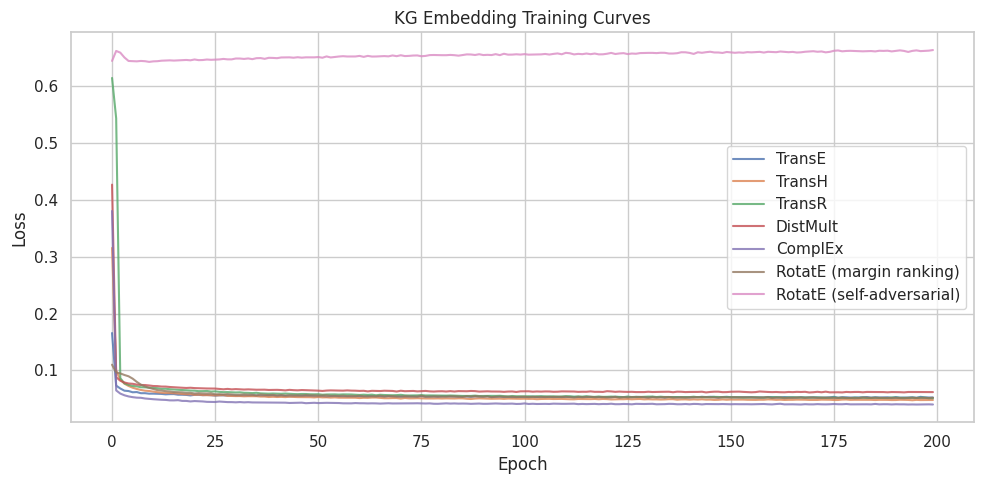

In [84]:
# ── KG Embeddings Summary ────────────────────────────────────────────────
all_metrics = [transe_metrics, transh_metrics, transr_metrics,
               distmult_metrics, complex_metrics, rotate_metrics, rotate_adv_metrics]
kg_summary = pd.DataFrame({
    'Model':   ['TransE', 'TransH', 'TransR', 'DistMult', 'ComplEx', 'RotatE (margin ranking)', 'RotatE (self-adversarial)'],
    'MRR':     [m['MRR'] for m in all_metrics],
    'MR':      [m['MR'] for m in all_metrics],
    'Hits@1':  [m['Hits@1'] for m in all_metrics],
    'Hits@3':  [m['Hits@3'] for m in all_metrics],
    'Hits@5':  [m['Hits@5'] for m in all_metrics],
    'Hits@10': [m['Hits@10'] for m in all_metrics],
})
print("\n" + "=" * 80)
print("KG Embedding Models — Link Prediction Summary")
print("=" * 80)
print(kg_summary.to_string(index=False))

# Training loss curves
fig, ax = plt.subplots(figsize=(10, 5))
for name, hist in [('TransE', transe_hist), ('TransH', transh_hist),
                    ('TransR', transr_hist), ('DistMult', distmult_hist),
                    ('ComplEx', complex_hist), ('RotatE (margin ranking)', rotate_hist),
                    ('RotatE (self-adversarial)', rotate_adv_hist)]:
    ax.plot(hist, label=name, alpha=0.8)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('KG Embedding Training Curves')
ax.legend()
plt.tight_layout()
plt.show()

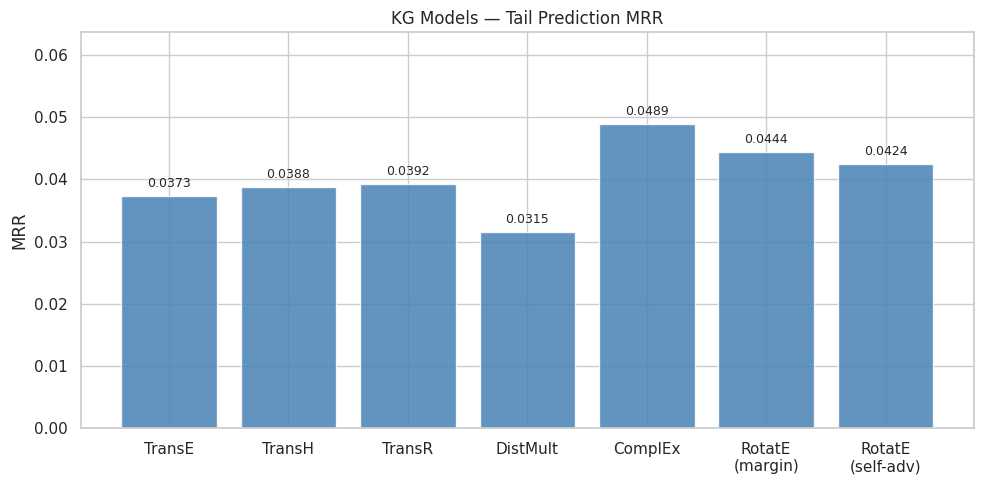

In [110]:
# ── Chart: Tail Prediction MRR ───────────────────────────────────────────
models_tail = ['TransE', 'TransH', 'TransR', 'DistMult', 'ComplEx', 'RotatE\n(margin)', 'RotatE\n(self-adv)']
tail_mrr = [transe_metrics['MRR'], transh_metrics['MRR'], transr_metrics['MRR'],
            distmult_metrics['MRR'], complex_metrics['MRR'],
            rotate_metrics['MRR'], rotate_adv_metrics['MRR']]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(models_tail, tail_mrr, color='steelblue', alpha=0.85, edgecolor='white')
ax.set_ylabel('MRR')
ax.set_title('KG Models — Tail Prediction MRR')
ax.set_ylim(0, max(tail_mrr) * 1.3)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


### Analysis — KG Embeddings for Link Prediction (Tail)

All models show low absolute metrics (MRR 0.03–0.05), which is expected when ranking among ~20K candidate entities. The results reveal a clear hierarchy driven by model expressiveness.

- **ComplEx achieves the best performance** (MRR: 0.049, Hits@10: 0.102, lowest MR: 106.5), as its complex-valued scoring captures richer entity-relation interactions than real-valued models. RotatE follows closely (MRR: 0.044), with both variants performing similarly, suggesting the self-adversarial loss doesn't provide significant gains within 200 epochs.
- **TransE, TransH, and TransR perform comparably** (MRR: 0.037–0.039). Despite TransH/TransR's theoretical advantages for 1-to-N relations through projection mechanisms, they do not significantly outperform the simpler TransE within the same training budget, although they did get higher metrics.
- **DistMult underperforms** (MRR: 0.032, highest MR: 149.2), as its diagonal scoring provides the least expressiveness for distinguishing among 20K entities. However, as shown in the relation prediction section, DistMult's simplicity becomes an advantage when ranking among fewer candidates.

**Key takeaway:** Complex-valued models (ComplEx, RotatE) consistently outperform real-valued alternatives, confirming that expressiveness is the primary driver of performance on multi-relational biomedical graphs. All models struggle with Hits@1 (<1.2%), reflecting the genuine difficulty of precise polypharmacy prediction.

---

### Relation Prediction

Relation prediction answers the question: "Given two drugs that are taken together, which specific side effect will they cause?"


1. Take a test triple — e.g., (Drug_A, nausea, Drug_B) where nausea is the true answer
2. Create all candidate triples — keep the drug pair fixed, but try every possible relation:
    - (Drug_A, nausea, Drug_B) ← relation 0
    - (Drug_A, headache, Drug_B) ← relation 1
    - (Drug_A, bleeding, Drug_B) ← relation 2
    - ...(all 50 SE types)
3. Score each candidate — the model assigns a score to each triple based on how likely it considers that relation for this drug pair
4. Rank by score — sort all 50 relations from most likely to least likely
5. Filter out other true relations — if (Drug_A, headache, Drug_B) is also a known true interaction and it scores higher than nausea, it is removed from the ranking rather than penalizing the model. The model was correct to score it highly — it just happens to not be the specific triple we're testing
6. Record the filtered rank — the rank of the true answer after removing other valid relations

**Why filtered?** Without filtering, a model could be penalized for correctly identifying that Drug A and Drug B cause both nausea and headache. If headache scores higher, the raw rank for nausea becomes 2 even though the model made no mistake. Filtered ranking removes this unfair penalty, giving a more accurate picture of model quality.

**Metrics:** MRR measures how high the correct relation is ranked on average. Hits@K measures how often the correct relation appears in the top K predictions.

**Relevance:** This is the most practically useful task — a doctor prescribing two drugs together wants to know which specific side effect to monitor, not just whether an interaction exists.


In [103]:
from collections import defaultdict

known_relations = defaultdict(set)
for h, r, t in train_t:
    known_relations[(int(h), int(t))].add(int(r))
for h, r, t in val_t:
    known_relations[(int(h), int(t))].add(int(r))
for h, r, t in test_t:
    known_relations[(int(h), int(t))].add(int(r))

def eval_relation_prediction_filtered(model, test_triples, n_relations):
    """Filtered relation prediction: remove other true relations from ranking."""
    model.eval()
    ranks = []
    
    triples = test_triples[:1000]
    with torch.no_grad():
        for i in range(len(triples)):
            h, r_true, t = int(triples[i][0]), int(triples[i][1]), int(triples[i][2])
            
            h_exp = torch.LongTensor([h]).to(device).expand(n_relations)
            t_exp = torch.LongTensor([t]).to(device).expand(n_relations)
            all_r = torch.arange(n_relations, device=device)
            
            scores = model.score(h_exp, all_r, t_exp)
            true_score = scores[r_true].item()
            
            # Filter: only count relations that are NOT also true for this (h, t) pair
            rank = 1
            for r_idx in range(n_relations):
                if r_idx == r_true:
                    continue
                if r_idx in known_relations[(h, t)]:
                    continue  # skip — this is also a valid relation, don't penalize
                if scores[r_idx].item() >= true_score:
                    rank += 1
            
            ranks.append(rank)
    
    ranks = np.array(ranks, dtype=float)
    return {
        'MRR': np.mean(1.0 / ranks),
        'MR': np.mean(ranks),
        'Hits@1': np.mean(ranks <= 1),
        'Hits@3': np.mean(ranks <= 3),
        'Hits@5': np.mean(ranks <= 5),
        'Hits@10': np.mean(ranks <= 10),
    }

# Run filtered relation prediction
print("=" * 70)
print("RELATION PREDICTION — (Drug_A, ?, Drug_B)")
print("=" * 70)

rel_pred_filtered = {}
for name, model in [('TransE', transe), ('TransH', transh), ('TransR', transr),
                     ('DistMult', distmult), ('ComplEx', complex_model), ('RotatE (margin ranking)', rotate),
                     ('RotatE (self-adversarial)', rotate_adv)]:
    metrics = eval_relation_prediction_filtered(model, test_t, n_relations)
    rel_pred_filtered[name] = metrics

rel_df = pd.DataFrame([{'Model': n, **m} for n, m in rel_pred_filtered.items()])
print("\n" + rel_df.to_string(index=False))


RELATION PREDICTION — (Drug_A, ?, Drug_B)

                    Model      MRR     MR  Hits@1  Hits@3  Hits@5  Hits@10
                   TransE 0.177232 14.352   0.061   0.154   0.253    0.439
                   TransH 0.213883 12.579   0.095   0.186   0.303    0.507
                   TransR 0.205392 11.970   0.083   0.189   0.282    0.521
                 DistMult 0.247941 11.273   0.120   0.240   0.350    0.560
                  ComplEx 0.234404 11.743   0.109   0.222   0.332    0.540
  RotatE (margin ranking) 0.207612 12.442   0.078   0.203   0.306    0.512
RotatE (self-adversarial) 0.198351 13.579   0.087   0.177   0.270    0.447


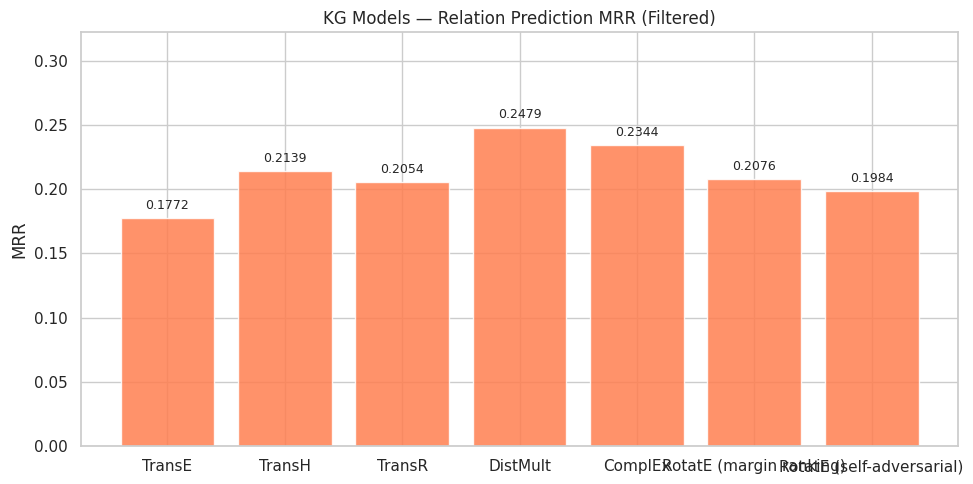

In [111]:
# ── Chart: Relation Prediction MRR ──────────────────────────────────────
models_rel = list(rel_pred_filtered.keys())
rel_mrr = [rel_pred_filtered[m]['MRR'] for m in models_rel]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(models_rel, rel_mrr, color='coral', alpha=0.85, edgecolor='white')
ax.set_ylabel('MRR')
ax.set_title('KG Models — Relation Prediction MRR (Filtered)')
ax.set_ylim(0, max(rel_mrr) * 1.3)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


### Analysis — KG Embeddings for Relation Prediction

**Interestingly, model rankings shifted for this problem** because the model ranks among only 50 relation types rather than ~20K entities. Filtered ranking further improves scores by excluding other valid side effects from the ranking.


- **DistMult achieves the best performance** (MRR: 0.248, Hits@10: 0.560), jumping from worst in tail prediction to first in relation prediction. Its diagonal scoring $h^T \text{diag}(r), t$ acts as a relation-specific weighted similarity check — when the drug pair is fixed and only the relation varies, this simple structure efficiently identifies the most compatible relation vector.
- **ComplEx remains strong** (MRR: 0.234, Hits@10: 0.540), confirming its consistent expressiveness across both tasks. Its complex-valued interactions provide rich scoring without DistMult's structural elegance for this specific task.
- **TransH and TransR outperform TransE more clearly here** (MRR: 0.214/0.205 vs 0.177), suggesting their projection mechanisms help discriminate between relation types. TransE's simple translation geometry makes its 50 relation vectors less distinguishable from each other.
- **Self-adversarial RotatE underperforms margin RotatE** (MRR: 0.198 vs 0.208) for relation prediction, contrary to expectations. The self-adversarial weighting may over-focus on hard negatives that are less relevant when ranking among only 50 candidates, where most negatives are already relatively easy to distinguish.

**Key insight:** DistMult's simplicity, which limits its expressiveness for entity ranking, becomes an advantage for relation ranking. The best model depends on the prediction task — a finding that highlights the importance of evaluating models across multiple evaluation settings.

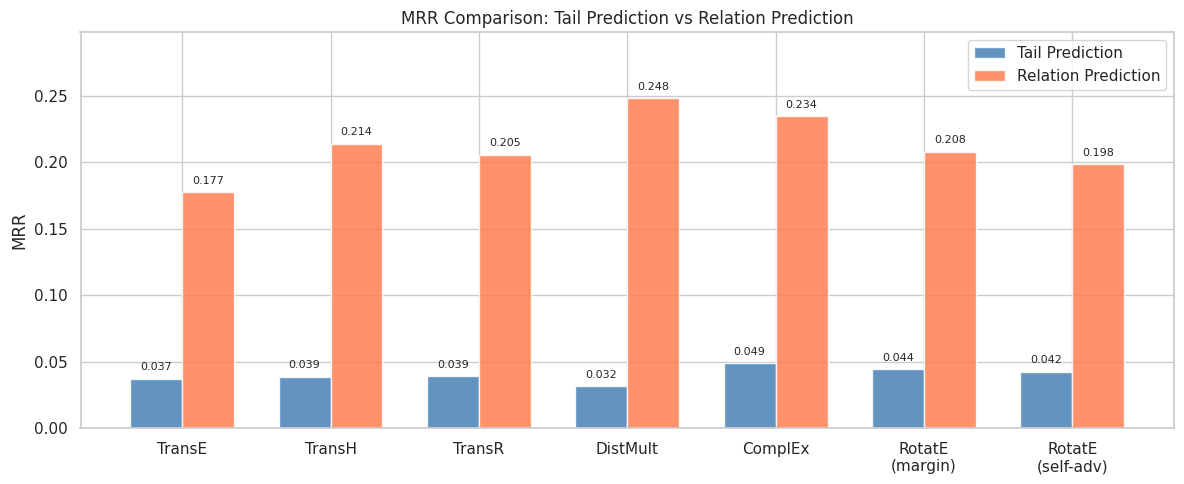

In [109]:
# ── MRR Comparison: Tail Prediction vs Relation Prediction ───────────────
models = ['TransE', 'TransH', 'TransR', 'DistMult', 'ComplEx', 'RotatE\n(margin)', 'RotatE\n(self-adv)']

# Replace these with your actual stored metrics
tail_mrr = [transe_metrics['MRR'], transh_metrics['MRR'], transr_metrics['MRR'],
            distmult_metrics['MRR'], complex_metrics['MRR'], 
            rotate_metrics['MRR'], rotate_adv_metrics['MRR']]

rel_mrr = [rel_pred_filtered['TransE']['MRR'], rel_pred_filtered['TransH']['MRR'],
           rel_pred_filtered['TransR']['MRR'], rel_pred_filtered['DistMult']['MRR'],
           rel_pred_filtered['ComplEx']['MRR'], rel_pred_filtered['RotatE (margin ranking)']['MRR'],
           rel_pred_filtered['RotatE (self-adversarial)']['MRR']]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width/2, tail_mrr, width, label='Tail Prediction', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, rel_mrr, width, label='Relation Prediction', color='coral', alpha=0.85)

ax.set_ylabel('MRR')
ax.set_title('MRR Comparison: Tail Prediction vs Relation Prediction')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.set_ylim(0, max(max(tail_mrr), max(rel_mrr)) * 1.2)

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()


# Section 3 — GNN-Based Embeddings

GNNs learn node representations through **message passing** where each node aggregates information from its neighbors to build its embedding. GNNs are inductive (they can generalize to unseen nodes) and use a parameterized encoder that processes the graph structure.

**Methods covered:**
| Model | Aggregation | Multi-Relational | Key Feature |
|-------|------------|------------------|-------------|
| GCN | Symmetric normalization | No (union graph) | Spectral-based convolution |
| GraphSAGE | Mean/Max/LSTM | No (union graph) | Sampling + inductive |
| R-GCN | Per-relation transforms | Yes (964 SE types) | Basis decomposition |
| GAT | Attention-weighted | No (union graph) | Learned importance weights |

**Key difference from KG models:** KG embeddings learn a fixed vector per entity (transductive). GNNs compute embeddings from graph structure using a learned function, so they can embed new drugs added to the graph without retraining, making them more suitable for real-world deployment where new drugs are regularly introduced.

**Metrics Used:** AUC-ROC (Area Under the Receiver Operating Characteristic curve) measures how well the model separates real edges from fake ones across all possible thresholds. AP (Average Precision) summarizes the precision-recall trade-off, focusing on how precise the model is among its positive predictions. AUC-ROC and AP are preferred for link prediction because they are threshold-independent, meaning they evaluate the model's ability to separate real edges from fake ones across all possible decision thresholds, without requiring an arbitrary cutoff. Accuracy and F1 require choosing a fixed threshold (e.g., 0.5), which is arbitrary and can significantly affect results. Additionally, link prediction is inherently class-imbalanced. There are far more non-edges than real edges in any graph. With this imbalance, a model that always predicts "no edge" would achieve >99% accuracy while being completely useless. AUC-ROC is robust to this imbalance, and AP is especially strict on false positives, making them the standard evaluation metrics for link prediction in graph ML.


> **Data Setup**: We use PyTorch Geometric (PyG) to construct the graph. For GCN/GraphSAGE/GAT, we treat the multi-relational graph as homogeneous (union). For R-GCN, we preserve relation types. We apply `RandomLinkSplit` for 80/10/10 edge-masking splits.

---

## 3.1 — PyG Data Construction

We build PyTorch Geometric `Data` objects from our edge arrays. Node features are initialized as random embeddings (learnable) since BioDecagon doesn't provide explicit node features. In practice, one could use drug SMILES fingerprints or protein sequences as features.

In [31]:
# ── Build PyG Data objects ────────────────────────────────────────────────
import torch_geometric
from torch_geometric.data import Data
from torch_geometric.transforms import RandomLinkSplit

# --- Homogeneous graph (for GCN, GraphSAGE, GAT) ---
# Use drugs-only subgraph edges (top-K SE, union of all relation types)
# Remove duplicates (since multiple SE types can connect same drug pair)
edge_pairs = set()
for s, d in zip(combo_src_sub, combo_dst_sub):
    edge_pairs.add((s, d))
    edge_pairs.add((d, s))  # undirected

homo_edges = list(edge_pairs)
homo_src = [e[0] for e in homo_edges]
homo_dst = [e[1] for e in homo_edges]

# Remap to contiguous node IDs
homo_nodes = sorted(set(homo_src) | set(homo_dst))
homo_remap = {n: i for i, n in enumerate(homo_nodes)}
n_homo_nodes = len(homo_nodes)

homo_src_r = [homo_remap[s] for s in homo_src]
homo_dst_r = [homo_remap[d] for d in homo_dst]

edge_index_homo = torch.tensor([homo_src_r, homo_dst_r], dtype=torch.long)

# Node features: learnable initial embeddings (identity-like)
x_homo = torch.eye(n_homo_nodes) if n_homo_nodes < 5000 else torch.randn(n_homo_nodes, 128)

data_homo = Data(x=x_homo, edge_index=edge_index_homo, num_nodes=n_homo_nodes)
print(f"Homogeneous PyG Data: {data_homo}")

# --- Train/Val/Test split ---
splitter = RandomLinkSplit(num_val=0.1, num_test=0.1,
                           add_negative_train_samples=True,
                           is_undirected=True)
train_data, val_data, test_data = splitter(data_homo)
print(f"\nSplit sizes:")
print(f"  Train edges: {train_data.edge_label_index.shape[1]}")
print(f"  Val edges:   {val_data.edge_label_index.shape[1]}")
print(f"  Test edges:  {test_data.edge_label_index.shape[1]}")

Homogeneous PyG Data: Data(x=[645, 645], edge_index=[2, 126002], num_nodes=645)

Split sizes:
  Train edges: 100802
  Val edges:   12600
  Test edges:  12600


## 3.2 — GCN (Graph Convolutional Network)

**Method**: GCN applies symmetric normalized convolution at each layer:
$$H^{(l+1)} = \sigma(\tilde{D}^{-1/2} \tilde{A} \tilde{D}^{-1/2} H^{(l)} W^{(l)})$$

where $\tilde{A} = A + I$ (self-loops) and $\tilde{D}$ is the degree matrix of $\tilde{A}$.

**Architecture**: 2-layer GCN encoder → inner-product decoder for link prediction.

**Limitation**: Treats all edges identically (no relation awareness). Also, standard GCN is **transductive** — it needs all nodes present during training. For BioDecagon, where new drugs may enter the market, this is a limitation. However, it serves as a strong GNN baseline.

In [32]:
# ── GCN Model ────────────────────────────────────────────────────────────
from torch_geometric.nn import GCNConv

class GCNEncoder(nn.Module):
    def __init__(self, in_dim, hidden_dim=128, out_dim=64):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, out_dim)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.3, training=self.training)
        x = self.conv2(x, edge_index)
        return x

class GNNLinkPredictor(nn.Module):
    def __init__(self, encoder):
        super().__init__()
        self.encoder = encoder

    def encode(self, x, edge_index):
        return self.encoder(x, edge_index)

    def decode(self, z, edge_label_index):
        src, dst = edge_label_index
        return (z[src] * z[dst]).sum(dim=-1)

    def forward(self, x, edge_index, edge_label_index):
        z = self.encode(x, edge_index)
        return self.decode(z, edge_label_index)

# ── GNN Training Loop ────────────────────────────────────────────────────
def train_gnn(model, train_data, val_data, epochs=200, lr=0.01):
    optimizer = Adam(model.parameters(), lr=lr)
    train_data_dev = train_data.to(device)
    val_data_dev = val_data.to(device)
    history = {'train_loss': [], 'val_auc': []}

    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()
        pred = model(train_data_dev.x, train_data_dev.edge_index,
                     train_data_dev.edge_label_index)
        loss = F.binary_cross_entropy_with_logits(pred, train_data_dev.edge_label.float())
        loss.backward()
        optimizer.step()
        history['train_loss'].append(loss.item())

        if epoch == 1 or epoch % 50 == 0 or epoch == epochs:
            model.eval()
            with torch.no_grad():
                val_pred = model(val_data_dev.x, val_data_dev.edge_index,
                                 val_data_dev.edge_label_index)
                val_auc = roc_auc_score(val_data_dev.edge_label.cpu(),
                                        val_pred.sigmoid().cpu())
            history['val_auc'].append(val_auc)
            print(f"  Epoch {epoch:>4d}/{epochs}: loss={loss.item():.4f} | val_AUC={val_auc:.4f}")

    return history

def eval_gnn(model, test_data):
    model.eval()
    test_data_dev = test_data.to(device)
    with torch.no_grad():
        pred = model(test_data_dev.x, test_data_dev.edge_index,
                     test_data_dev.edge_label_index)
        pred_np = pred.sigmoid().cpu().numpy()
        label_np = test_data_dev.edge_label.cpu().numpy()
    auc = roc_auc_score(label_np, pred_np)
    ap  = average_precision_score(label_np, pred_np)
    return {'AUC-ROC': auc, 'AP': ap}

# Train GCN
print("Training GCN...")
gcn_encoder = GCNEncoder(train_data.x.shape[1], hidden_dim=128, out_dim=64)
gcn_model = GNNLinkPredictor(gcn_encoder).to(device)
gcn_hist = train_gnn(gcn_model, train_data, val_data, epochs=200, lr=0.01)

gcn_metrics = eval_gnn(gcn_model, test_data)
print(f"\nGCN Test — AUC-ROC: {gcn_metrics['AUC-ROC']:.4f} | AP: {gcn_metrics['AP']:.4f}")

Training GCN...
  Epoch    1/200: loss=0.6931 | val_AUC=0.9376
  Epoch   50/200: loss=0.4904 | val_AUC=0.8770
  Epoch  100/200: loss=0.4889 | val_AUC=0.8803
  Epoch  150/200: loss=0.4881 | val_AUC=0.8818
  Epoch  200/200: loss=0.4837 | val_AUC=0.8932

GCN Test — AUC-ROC: 0.8948 | AP: 0.9197


## 3.3 — GraphSAGE

**Method**: GraphSAGE learns by **sampling and aggregating** features from a node's local neighborhood:
$$h_v^{(l+1)} = \sigma(W^{(l)} \cdot \text{AGG}(\{h_u^{(l)} : u \in \mathcal{N}(v)\}) + B^{(l)} \cdot h_v^{(l)})$$

**Aggregators**: Mean (default), Max, or LSTM. We use mean aggregation.

**Key advantage**: GraphSAGE is **inductive** — it can generate embeddings for unseen nodes at test time by aggregating their neighbors' features. This is crucial for BioDecagon where new drugs may be added.

**Limitation**: Like GCN, it doesn't natively handle multi-relational edges.

In [33]:
# ── GraphSAGE Model ──────────────────────────────────────────────────────
from torch_geometric.nn import SAGEConv

class GraphSAGEEncoder(nn.Module):
    def __init__(self, in_dim, hidden_dim=128, out_dim=64):
        super().__init__()
        self.conv1 = SAGEConv(in_dim, hidden_dim)
        self.conv2 = SAGEConv(hidden_dim, out_dim)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.3, training=self.training)
        x = self.conv2(x, edge_index)
        return x

print("Training GraphSAGE...")
sage_encoder = GraphSAGEEncoder(train_data.x.shape[1], hidden_dim=128, out_dim=64)
sage_model = GNNLinkPredictor(sage_encoder).to(device)
sage_hist = train_gnn(sage_model, train_data, val_data, epochs=200, lr=0.01)

sage_metrics = eval_gnn(sage_model, test_data)
print(f"\nGraphSAGE Test — AUC-ROC: {sage_metrics['AUC-ROC']:.4f} | AP: {sage_metrics['AP']:.4f}")

Training GraphSAGE...
  Epoch    1/200: loss=0.6969 | val_AUC=0.8209
  Epoch   50/200: loss=0.4780 | val_AUC=0.8987
  Epoch  100/200: loss=0.4491 | val_AUC=0.9203
  Epoch  150/200: loss=0.4354 | val_AUC=0.9315
  Epoch  200/200: loss=0.4233 | val_AUC=0.9180

GraphSAGE Test — AUC-ROC: 0.9198 | AP: 0.9378


## 3.4 — GAT (Graph Attention Network)

**Method**: GAT uses **attention mechanisms** to learn the importance of each neighbor:
$$h_v^{(l+1)} = \sigma\Big(\sum_{u \in \mathcal{N}(v)} \alpha_{vu} W h_u^{(l)}\Big)$$

where attention coefficients $\alpha_{vu}$ are computed via a learned attention function.

**Multi-head attention**: Uses $K$ independent attention heads and concatenates (or averages) their outputs for richer representations.

**Advantage**: Unlike GCN's fixed normalization, GAT **learns** which neighbors are most important. For drug interaction networks, this could prioritize pharmacologically similar drugs.

**Limitation**: Like GCN/GraphSAGE, standard GAT doesn't handle multi-relational edges natively. We use the union graph.

In [38]:
# ── GAT Model ────────────────────────────────────────────────────────────
from torch_geometric.nn import GATConv

class GATEncoder(nn.Module):
    def __init__(self, in_dim, hidden_dim=128, out_dim=64, heads=4):
        super().__init__()
        self.conv1 = GATConv(in_dim, hidden_dim // heads, heads=heads, dropout=0.3)
        self.conv2 = GATConv(hidden_dim, out_dim, heads=1, concat=False, dropout=0.3)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=0.3, training=self.training)
        x = self.conv2(x, edge_index)
        return x

print("Training GAT...")
gat_encoder = GATEncoder(train_data.x.shape[1], hidden_dim=128, out_dim=64, heads=4)
gat_model = GNNLinkPredictor(gat_encoder).to(device)
gat_hist = train_gnn(gat_model, train_data, val_data, epochs=200, lr=0.005)

gat_metrics = eval_gnn(gat_model, test_data)
print(f"\nGAT Test — AUC-ROC: {gat_metrics['AUC-ROC']:.4f} | AP: {gat_metrics['AP']:.4f}")

Training GAT...
  Epoch    1/200: loss=0.6931 | val_AUC=0.9195
  Epoch   50/200: loss=0.5252 | val_AUC=0.8600
  Epoch  100/200: loss=0.5080 | val_AUC=0.8926
  Epoch  150/200: loss=0.5035 | val_AUC=0.8746
  Epoch  200/200: loss=0.4995 | val_AUC=0.8898

GAT Test — AUC-ROC: 0.8927 | AP: 0.9166


The GNN models solve binary link prediction. Given two drugs, predict whether they share any polypharmacy side effect. All side-effect types are collapsed into a single edge type, so the model simply predicts "will these drugs interact?" rather than which side effect occurs. Each GNN learns drug embeddings through message passing (aggregating neighbor information), then predicts links via dot-product similarity between embeddings. We evaluate with AUC-ROC and AP as the output is a binary probability.

In [119]:
# ── GNN Models Summary ───────────────────────────────────────────────────
gnn_summary = pd.DataFrame({
    'Model': ['GCN', 'GraphSAGE', 'GAT'],
    'AUC-ROC': [gcn_metrics['AUC-ROC'], sage_metrics['AUC-ROC'], gat_metrics['AUC-ROC']],
    'AP': [gcn_metrics['AP'], sage_metrics['AP'], gat_metrics['AP']],
})
print("\n" + "=" * 60)
print("GNN Models — Link Prediction Summary")
print("=" * 60)
print(gnn_summary.to_string(index=False))


GNN Models — Link Prediction Summary
    Model  AUC-ROC       AP
      GCN 0.894764 0.919721
GraphSAGE 0.919817 0.937768
      GAT 0.892680 0.916633


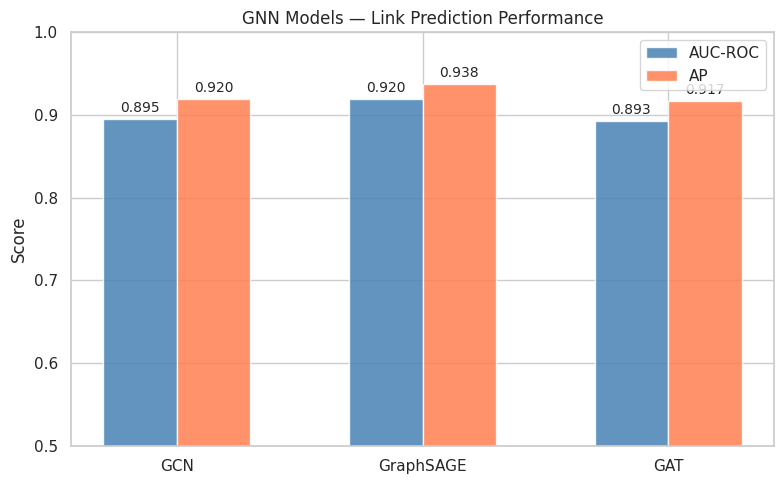

In [120]:
# ── Plot: GNN Models — AUC-ROC & AP ─────────────────────────────────────
models_gnn = ['GCN', 'GraphSAGE', 'GAT']
auc_vals = [gcn_metrics['AUC-ROC'], sage_metrics['AUC-ROC'], gat_metrics['AUC-ROC']]
ap_vals = [gcn_metrics['AP'], sage_metrics['AP'], gat_metrics['AP']]

x = np.arange(len(models_gnn))
width = 0.3

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, auc_vals, width, label='AUC-ROC', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, ap_vals, width, label='AP', color='coral', alpha=0.85)

ax.set_ylabel('Score')
ax.set_title('GNN Models — Link Prediction Performance')
ax.set_xticks(x)
ax.set_xticklabels(models_gnn)
ax.legend()
ax.set_ylim(0.5, 1.0)

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


## Analysis of Link Prediction GNN Models


**GraphSAGE outperforms both GCN and GAT (AUC-ROC: 0.920, AP: 0.938).** This is because GraphSAGE samples a fixed number of neighbors and applies a learned aggregation function, which acts as a regularizer — it prevents the model from overfitting to high-degree hub drugs. It also separates the ego embedding from the neighbor aggregation, giving it more flexibility to learn different roles for a drug's own features vs its neighborhood.

**Why GraphSAGE wins** GCN and GAT use all neighbors every time. In BioDecagon, some drugs have 200+ connections. When you aggregate ALL 200 neighbors, the embedding becomes a blurry average. Every high-degree drug starts looking the same because they all average over huge overlapping neighborhoods. GraphSAGE samples a fixed subset (e.g., 25 neighbors per layer). This means each training step sees a different random sample of neighbors, acts like dropout and reduces overfitting. The embedding isn't diluted by averaging over hundreds of neighbors.

**GCN and GAT perform nearly identically (AUC-ROC: ~0.89, AP: ~0.92).** GCN averages neighbor features with fixed degree normalization, while GAT learns attention weights to emphasize important neighbors. The similar performance suggests that neighbor importance is relatively uniform in this graph — learning which neighbors matter more (GAT's advantage) doesn't help much when most drug neighbors contribute equally. The attention mechanism adds parameters without improving signal.

**Why GCN ≈ GAT** GAT's attention is supposed to learn "Drug_C matters more than Drug_D as a neighbor." But in this graph, all edges mean the same thing (side effects). There's no node features to differentiate neighbors (random initial features)
So there's nothing for attention to learn from — all neighbors look equally informative. Without meaningful signal to attend to, GAT's attention weights converge to roughly uniform (= same as GCN's fixed averaging), but with extra parameters that risk overfitting. That's why it underperforms GCN.

**Why all models score >0.89** The graph is dense enough that 2-hop neighborhood overlap is highly predictive: if Drug_A and Drug_B share many neighbors, they're likely connected. Even simple averaging (GCN) captures this structural similarity. The >0.89 AUC-ROC shows that graph topology alone carries strong signal for binary link existence.

## 3.5 — R-GCN (Relational Graph Convolutional Network)

**Method**: R-GCN extends GCN with **relation-specific weight matrices**:
$$h_v^{(l+1)} = \sigma\Big(\sum_{r \in \mathcal{R}} \sum_{u \in \mathcal{N}_r(v)} \frac{1}{|\mathcal{N}_r(v)|} W_r^{(l)} h_u^{(l)} + W_0^{(l)} h_v^{(l)}\Big)$$

**Basis decomposition**: With 964 SE types + 1 target relation, having a separate weight matrix per relation is prohibitive. R-GCN uses **basis decomposition**: $W_r = \sum_{b=1}^{B} a_{rb} V_b$, sharing $B$ basis matrices across all relations.

**Training with multi-label BCE:** For each drug pair, the model outputs 50 scores (one per SE type). Binary cross-entropy is applied independently to each relation. For example, if (Drug_A, Drug_B) causes nausea and headache but not bleeding, the label vector is [1, 1, 0, ...] and the loss penalizes the model for scoring nausea/headache too low or bleeding too high. Since each relation is a separate binary decision, a drug pair can have multiple side effects predicted simultaneously — unlike categorical cross-entropy which would force the model to pick exactly one. The total loss is the average BCE across all 50 relations and all drug pairs in the batch.

**Why ideal for BioDecagon**: This is the only GNN model that natively handles the multi-relational structure. It can learn relation-specific propagation patterns e.g., drugs that cause the same cardiovascular side effects should aggregate information differently than drugs sharing metabolic side effects.

In [34]:
# ── R-GCN Data Preparation ────────────────────────────────────────────────
from torch_geometric.nn import RGCNConv

# Build edge_index and edge_type for the multi-relational subgraph
# Use the subsampled combo edges with relation types
rgcn_src = np.concatenate([combo_src_sub, combo_dst_sub])  # both directions
rgcn_dst = np.concatenate([combo_dst_sub, combo_src_sub])
rgcn_rel = np.concatenate([combo_rel_sub_remapped, combo_rel_sub_remapped])

# Remap to contiguous node IDs
rgcn_nodes = sorted(set(rgcn_src) | set(rgcn_dst))
rgcn_remap = {n: i for i, n in enumerate(rgcn_nodes)}
n_rgcn_nodes = len(rgcn_nodes)
n_rgcn_rels = TOP_K_SE

rgcn_src_r = [rgcn_remap[s] for s in rgcn_src]
rgcn_dst_r = [rgcn_remap[d] for d in rgcn_dst]

edge_index_rgcn = torch.tensor([rgcn_src_r, rgcn_dst_r], dtype=torch.long)
edge_type_rgcn = torch.tensor(rgcn_rel, dtype=torch.long)

x_rgcn = torch.randn(n_rgcn_nodes, 64)

print(f"R-GCN Data:")
print(f"  Nodes: {n_rgcn_nodes:,}")
print(f"  Edges: {edge_index_rgcn.shape[1]:,}")
print(f"  Relation types: {n_rgcn_rels}")

R-GCN Data:
  Nodes: 645
  Edges: 1,951,034
  Relation types: 50


In [121]:
# ── R-GCN Model ──────────────────────────────────────────────────────────
class RGCNEncoder(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, n_relations, num_bases=10):
        super().__init__()
        self.conv1 = RGCNConv(in_dim, hidden_dim, n_relations, num_bases=num_bases)
        self.conv2 = RGCNConv(hidden_dim, out_dim, n_relations, num_bases=num_bases)

    def forward(self, x, edge_index, edge_type):
        x = self.conv1(x, edge_index, edge_type)
        x = F.relu(x)
        x = F.dropout(x, p=0.3, training=self.training)
        x = self.conv2(x, edge_index, edge_type)
        return x

# ── R-GCN split: manually split edges ────────────────────────────────────
n_edges_half = len(combo_src_sub)  # original directed edges
indices = np.random.permutation(n_edges_half)
n_test_r = int(0.1 * n_edges_half)
n_val_r  = int(0.1 * n_edges_half)

test_idx  = indices[:n_test_r]
val_idx   = indices[n_test_r:n_test_r + n_val_r]
train_idx = indices[n_test_r + n_val_r:]

# Training edges (both directions)
train_src = np.concatenate([combo_src_sub[train_idx], combo_dst_sub[train_idx]])
train_dst = np.concatenate([combo_dst_sub[train_idx], combo_src_sub[train_idx]])
train_rel = np.concatenate([combo_rel_sub_remapped[train_idx], combo_rel_sub_remapped[train_idx]])

train_src_r = [rgcn_remap[s] for s in train_src]
train_dst_r = [rgcn_remap[d] for d in train_dst]

train_edge_index = torch.tensor([train_src_r, train_dst_r], dtype=torch.long)
train_edge_type = torch.tensor(train_rel, dtype=torch.long)


print(f"R-GCN split: train={len(train_idx):,} | val={len(val_idx):,} | test={len(test_idx):,}")

R-GCN split: train=780,415 | val=97,551 | test=97,551


In [115]:
class RGCNMultiLabel(nn.Module):
    def __init__(self, encoder, n_relations, emb_dim):
        super().__init__()
        self.encoder = encoder
        # Per-relation scoring: diagonal matrix per relation
        self.rel_diag = nn.Parameter(torch.randn(n_relations, emb_dim))
        nn.init.xavier_uniform_(self.rel_diag)
    
    def forward(self, x, edge_index, edge_type, src, dst):
        """Returns scores for ALL relations for each (src, dst) pair."""
        z = self.encoder(x, edge_index, edge_type)
        z_src = z[src]  # (batch, emb_dim)
        z_dst = z[dst]  # (batch, emb_dim)
        # Score each relation: z_src * diag(r) * z_dst for all r
        # rel_diag: (n_rel, emb_dim), z_src: (batch, emb_dim)
        scores = torch.einsum('bd,rd,bd->br', z_src, self.rel_diag, z_dst)  # (batch, n_rel)
        return scores

# ── Build multi-label targets ────────────────────────────────────────────
from collections import defaultdict

# Create multi-hot labels for each drug pair
pair_to_rels = defaultdict(set)
for i in range(len(combo_src_sub)):
    s, d, r = combo_src_sub[i], combo_dst_sub[i], combo_rel_sub_remapped[i]
    if s in rgcn_remap and d in rgcn_remap:
        pair_to_rels[(rgcn_remap[s], rgcn_remap[d])].add(r)

# Training pairs and multi-hot labels
train_pairs = []
train_multilabels = []
for i in train_idx:
    s, d = combo_src_sub[i], combo_dst_sub[i]
    if s in rgcn_remap and d in rgcn_remap:
        pair = (rgcn_remap[s], rgcn_remap[d])
        label = torch.zeros(n_rgcn_rels)
        for r in pair_to_rels[pair]:
            label[r] = 1.0
        train_pairs.append(pair)
        train_multilabels.append(label)

train_src_ml = torch.tensor([p[0] for p in train_pairs], dtype=torch.long)
train_dst_ml = torch.tensor([p[1] for p in train_pairs], dtype=torch.long)
train_labels_ml = torch.stack(train_multilabels)

# Same for test
test_pairs = []
test_multilabels = []
for i in test_idx:
    s, d = combo_src_sub[i], combo_dst_sub[i]
    if s in rgcn_remap and d in rgcn_remap:
        pair = (rgcn_remap[s], rgcn_remap[d])
        label = torch.zeros(n_rgcn_rels)
        for r in pair_to_rels[pair]:
            label[r] = 1.0
        test_pairs.append(pair)
        test_multilabels.append(label)

test_src_ml = torch.tensor([p[0] for p in test_pairs], dtype=torch.long)
test_dst_ml = torch.tensor([p[1] for p in test_pairs], dtype=torch.long)
test_labels_ml = torch.stack(test_multilabels)

print(f"Multi-label data: {len(train_pairs)} train pairs, {len(test_pairs)} test pairs")
print(f"Average SE types per pair: {train_labels_ml.sum(dim=1).mean():.2f}")

# ── Train R-GCN Multi-Label ─────────────────────────────────────────────
print("\nTraining R-GCN (multi-label BCE)...")
rgcn_encoder_ml = RGCNEncoder(64, 128, 64, n_rgcn_rels, num_bases=10)
rgcn_ml = RGCNMultiLabel(rgcn_encoder_ml, n_rgcn_rels, 64).to(device)
optimizer = Adam(rgcn_ml.parameters(), lr=0.01)

x_dev = x_rgcn.to(device)
train_ei_dev = train_edge_index.to(device)
train_et_dev = train_edge_type.to(device)

for epoch in range(1, 201):
    rgcn_ml.train()
    optimizer.zero_grad()
    
    # Mini-batch (sample if too large)
    batch_size = min(4096, len(train_src_ml))
    idx = torch.randperm(len(train_src_ml))[:batch_size]
    
    scores = rgcn_ml(x_dev, train_ei_dev, train_et_dev,
                      train_src_ml[idx].to(device), train_dst_ml[idx].to(device))
    loss = F.binary_cross_entropy_with_logits(scores, train_labels_ml[idx].to(device))
    loss.backward()
    optimizer.step()
    
    if epoch == 1 or epoch % 50 == 0:
        print(f"  Epoch {epoch:>4d}/200: loss={loss.item():.4f}")

# ── Evaluate ─────────────────────────────────────────────────────────────
rgcn_ml.eval()
with torch.no_grad():
    test_scores = rgcn_ml(x_dev, train_ei_dev, train_et_dev,
                           test_src_ml.to(device), test_dst_ml.to(device))
    test_preds = test_scores.sigmoid().cpu().numpy()
    test_labs = test_labels_ml.numpy()

# Per-relation AUC-ROC and AP
from sklearn.metrics import roc_auc_score, average_precision_score

per_rel_auc = []
per_rel_ap = []
for r in range(n_rgcn_rels):
    if test_labs[:, r].sum() > 0 and test_labs[:, r].sum() < len(test_labs):
        per_rel_auc.append(roc_auc_score(test_labs[:, r], test_preds[:, r]))
        per_rel_ap.append(average_precision_score(test_labs[:, r], test_preds[:, r]))

print(f"\nR-GCN Multi-Label Results:")
print(f"  Macro AUC-ROC: {np.mean(per_rel_auc):.4f}")
print(f"  Macro AP:      {np.mean(per_rel_ap):.4f}")
print(f"  Relations evaluated: {len(per_rel_auc)}/{n_rgcn_rels}")

Multi-label data: 780415 train pairs, 97551 test pairs
Average SE types per pair: 20.76

Training R-GCN (multi-label BCE)...
  Epoch    1/200: loss=1.5011
  Epoch   50/200: loss=0.6634
  Epoch  100/200: loss=0.6570
  Epoch  150/200: loss=0.6465
  Epoch  200/200: loss=0.6356

R-GCN Multi-Label Results:
  Macro AUC-ROC: 0.6665
  Macro AP:      0.5748
  Relations evaluated: 50/50


Macro AUC-ROC and Macro AP measure how well R-GCN predicts each individual side-effect type, averaged equally across all 50 types: 0.667 is above random (0.5) but not strong. This is expected because R-GCN uses random features (no real drug properties) and only 200 training epochs. With richer features or longer training, these would probably improve.

In [116]:
# ── R-GCN Multi-Label: Binary Link Prediction (AUC-ROC / AP) ────────────
rgcn_ml.eval()
with torch.no_grad():
    # Positive pairs (from test)
    pos_scores = rgcn_ml(x_dev, train_ei_dev, train_et_dev,
                          test_src_ml.to(device), test_dst_ml.to(device))
    # Max across relations: "does ANY relation exist?"
    pos_binary = pos_scores.max(dim=1).values.sigmoid().cpu().numpy()
    
    # Negative pairs (random drug pairs)
    neg_dst = torch.randint(0, n_rgcn_nodes, (len(test_src_ml),))
    neg_scores = rgcn_ml(x_dev, train_ei_dev, train_et_dev,
                          test_src_ml.to(device), neg_dst.to(device))
    neg_binary = neg_scores.max(dim=1).values.sigmoid().cpu().numpy()

labels = np.concatenate([np.ones(len(pos_binary)), np.zeros(len(neg_binary))])
scores = np.concatenate([pos_binary, neg_binary])

rgcn_ml_auc = roc_auc_score(labels, scores)
rgcn_ml_ap = average_precision_score(labels, scores)
print(f"R-GCN Multi-Label — Binary Link Prediction:")
print(f"  AUC-ROC: {rgcn_ml_auc:.4f} | AP: {rgcn_ml_ap:.4f}")


R-GCN Multi-Label — Binary Link Prediction:
  AUC-ROC: 0.6152 | AP: 0.5626


To enable comparison with GCN, GraphSAGE, and GAT, we evaluated the multi-label R-GCN on binary link prediction, and predicting whether any interaction exists between a drug pair, regardless of which side effect. This is done by taking the maximum score across all 50 relations and passing it through a sigmoid: if any relation scores high, the model predicts an edge exists.

**It's important to note however that** the R-GCN was not trained for this task. It was optimized via multi-label BCE to predict which specific side effects apply, not whether any edge exists. The max aggregation is not a learned decision boundary. Lower AUC-ROC compared to the homogeneous GNNs is therefore expected and does not indicate that R-GCN is a weaker model. It just reflects a task mismatch. R-GCN's true strength is shown in the relation and tail prediction metrics (MRR/Hits@K), where it leverages its multi-relational modeling capability.

GNN Models — Binary Link Prediction Summary
              Model  AUC-ROC       AP
                GCN 0.894764 0.919721
          GraphSAGE 0.919817 0.937768
                GAT 0.892680 0.916633
R-GCN (multi-label) 0.615245 0.562571


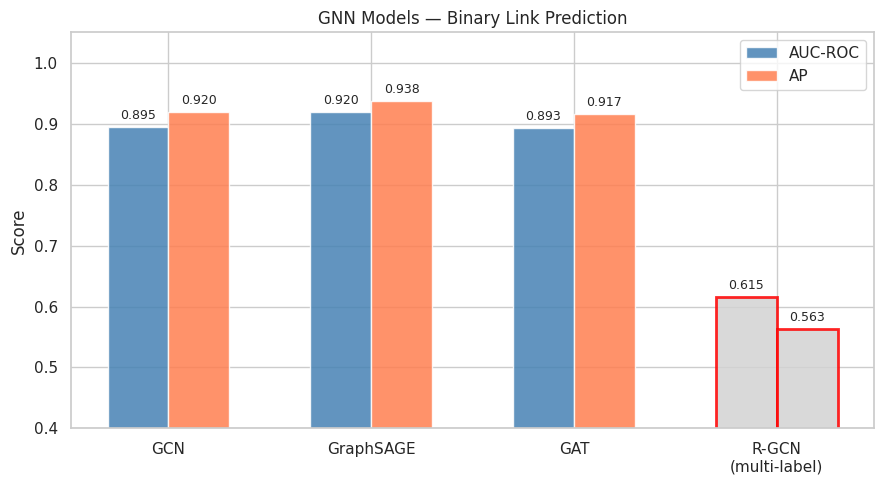

In [125]:
# ── GNN Summary with R-GCN (highlighted as cross-task eval) ─────────────
gnn_summary = pd.DataFrame({
    'Model': ['GCN', 'GraphSAGE', 'GAT', 'R-GCN (multi-label)'],
    'AUC-ROC': [gcn_metrics['AUC-ROC'], sage_metrics['AUC-ROC'],
                gat_metrics['AUC-ROC'], rgcn_ml_auc],
    'AP': [gcn_metrics['AP'], sage_metrics['AP'],
           gat_metrics['AP'], rgcn_ml_ap],
})
print("=" * 60)
print("GNN Models — Binary Link Prediction Summary")
print("=" * 60)
print(gnn_summary.to_string(index=False))

# ── Plot with R-GCN highlighted ─────────────────────────────────────────
models_gnn = ['GCN', 'GraphSAGE', 'GAT', 'R-GCN\n(multi-label)']
auc_vals = [gcn_metrics['AUC-ROC'], sage_metrics['AUC-ROC'], gat_metrics['AUC-ROC'], rgcn_ml_auc]
ap_vals = [gcn_metrics['AP'], sage_metrics['AP'], gat_metrics['AP'], rgcn_ml_ap]

x = np.arange(len(models_gnn))
width = 0.3

# Different colors: blue for homogeneous GNNs, red-dashed for R-GCN (not optimized)
auc_colors = ['steelblue', 'steelblue', 'steelblue', '#D3D3D3']
ap_colors = ['coral', 'coral', 'coral', '#D3D3D3']

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, auc_vals, width, label='AUC-ROC', color=auc_colors, 
               edgecolor=['white']*3 + ['red'], linewidth=[1]*3 + [2], alpha=0.85)
bars2 = ax.bar(x + width/2, ap_vals, width, label='AP', color=ap_colors,
               edgecolor=['white']*3 + ['red'], linewidth=[1]*3 + [2], alpha=0.85)

ax.set_ylabel('Score')
ax.set_title('GNN Models — Binary Link Prediction')
ax.set_xticks(x)
ax.set_xticklabels(models_gnn)
ax.legend()
ax.set_ylim(0.4, 1.05)

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


### R-GCN Ranking Evaluation

The multi-label R-GCN can be evaluated with the same ranking metrics (MRR, Hits@K) used for KG models, enabling direct comparison.

**Relation prediction** — Given two drugs (Drug_A, Drug_B), score all 50 side-effect types using the per-relation decoder $z_A^T \cdot \text{diag}(r) \cdot z_B$ and rank which side effect scores highest. The correct side effect's rank is recorded.

**Tail prediction** — Given a drug and a side effect (Drug_A, nausea), score all drugs as potential interaction partners using $z_A^T \cdot \text{diag}(r_{nausea}) \cdot z_t$ for every drug $t$ in the graph. The correct drug's rank is recorded.

Metrics are then computed as averages over all test triples, the same way as KG models: MRR (mean reciprocal rank), MR (mean rank), and Hits@K (proportion ranked in top K).

This makes R-GCN directly comparable to the KG models on the same evaluation — the only difference is where the embeddings come from (GNN encoder vs lookup table).

In [117]:
# ── R-GCN Multi-Label: Relation Prediction (MRR/Hits@K) ─────────────────
def eval_rgcn_relation_prediction(rgcn_ml, x, edge_index, edge_type, 
                                   test_triples, rgcn_remap, n_relations):
    """Rank all relations for each test triple — same as KG eval."""
    rgcn_ml.eval()
    ranks = []
    triples = test_triples[:1000]
    
    with torch.no_grad():
        z = rgcn_ml.encoder(x.to(device), edge_index.to(device), edge_type.to(device))
        
        for h_orig, r_true, t_orig in triples:
            if h_orig not in rgcn_remap or t_orig not in rgcn_remap:
                continue
            h = rgcn_remap[h_orig]
            t = rgcn_remap[t_orig]
            
            # Score all relations for this (h, t) pair
            z_h = z[h]  # (emb_dim,)
            z_t = z[t]  # (emb_dim,)
            scores = torch.einsum('d,rd,d->r', z_h, rgcn_ml.rel_diag, z_t)  # (n_rel,)
            
            r_true = int(r_true)
            rank = (scores >= scores[r_true]).sum().item()
            ranks.append(rank)
    
    ranks = np.array(ranks, dtype=float)
    return {
        'MRR': np.mean(1.0 / ranks),
        'MR': np.mean(ranks),
        'Hits@1': np.mean(ranks <= 1),
        'Hits@3': np.mean(ranks <= 3),
        'Hits@5': np.mean(ranks <= 5),
        'Hits@10': np.mean(ranks <= 10),
    }

# ── R-GCN Multi-Label: Tail Prediction (MRR/Hits@K) ─────────────────────
def eval_rgcn_tail_prediction(rgcn_ml, x, edge_index, edge_type,
                               test_triples, rgcn_remap, n_nodes):
    """Rank all entities as tail for each test triple."""
    rgcn_ml.eval()
    ranks = []
    triples = test_triples[:1000]
    
    with torch.no_grad():
        z = rgcn_ml.encoder(x.to(device), edge_index.to(device), edge_type.to(device))
        
        for h_orig, r, t_orig in triples:
            if h_orig not in rgcn_remap or t_orig not in rgcn_remap:
                continue
            h = rgcn_remap[h_orig]
            t = rgcn_remap[t_orig]
            r = int(r)
            
            # Score all entities as tail using relation r
            z_h = z[h]                         # (emb_dim,)
            r_diag = rgcn_ml.rel_diag[r]       # (emb_dim,)
            scores = (z_h * r_diag * z).sum(dim=-1)  # (n_nodes,)
            
            rank = (scores >= scores[t]).sum().item()
            ranks.append(rank)
    
    ranks = np.array(ranks, dtype=float)
    return {
        'MRR': np.mean(1.0 / ranks),
        'MR': np.mean(ranks),
        'Hits@1': np.mean(ranks <= 1),
        'Hits@3': np.mean(ranks <= 3),
        'Hits@5': np.mean(ranks <= 5),
        'Hits@10': np.mean(ranks <= 10),
    }

# ── Run both evaluations ────────────────────────────────────────────────
test_triples_orig = list(zip(
    combo_src_sub[test_idx], combo_rel_sub_remapped[test_idx], combo_dst_sub[test_idx]
))

print("R-GCN Multi-Label — Relation Prediction:")
rgcn_rel_metrics = eval_rgcn_relation_prediction(
    rgcn_ml, x_rgcn, train_edge_index, train_edge_type,
    test_triples_orig, rgcn_remap, n_rgcn_rels
)
for k, v in rgcn_rel_metrics.items():
    print(f"  {k}: {v:.4f}")

print("\nR-GCN Multi-Label — Tail Prediction:")
rgcn_tail_metrics = eval_rgcn_tail_prediction(
    rgcn_ml, x_rgcn, train_edge_index, train_edge_type,
    test_triples_orig, rgcn_remap, n_rgcn_nodes
)
for k, v in rgcn_tail_metrics.items():
    print(f"  {k}: {v:.4f}")


R-GCN Multi-Label — Relation Prediction:
  MRR: 0.1099
  MR: 22.6530
  Hits@1: 0.0300
  Hits@3: 0.0850
  Hits@5: 0.1300
  Hits@10: 0.2600

R-GCN Multi-Label — Tail Prediction:
  MRR: 0.0179
  MR: 194.6810
  Hits@1: 0.0010
  Hits@3: 0.0070
  Hits@5: 0.0110
  Hits@10: 0.0260


ALL MODELS — Tail Prediction Comparison
              Model      MRR         MR   Hits@1   Hits@3   Hits@5  Hits@10
             TransE 0.037278 116.663568 0.000724 0.022040 0.042913 0.088833
             TransH 0.038756 110.108982 0.000111 0.023669 0.044713 0.094406
             TransR 0.039222 122.223466 0.006941 0.024394 0.041152 0.080404
           DistMult 0.031548 149.216213 0.006327 0.018449 0.030329 0.059410
            ComplEx 0.048911 106.506151 0.011297 0.033206 0.054260 0.102373
    RotatE (margin) 0.044400 118.185905 0.010401 0.029393 0.046735 0.089115
  RotatE (self-adv) 0.042378 127.496957 0.010019 0.027965 0.044804 0.084810
R-GCN (multi-label) 0.017949 194.681000 0.001000 0.007000 0.011000 0.026000

ALL MODELS — Relation Prediction Comparison
                    Model      MRR     MR  Hits@1  Hits@3  Hits@5  Hits@10
                   TransE 0.177232 14.352   0.061   0.154   0.253    0.439
                   TransH 0.213883 12.579   0.095   0.186   0.303    0.507
      

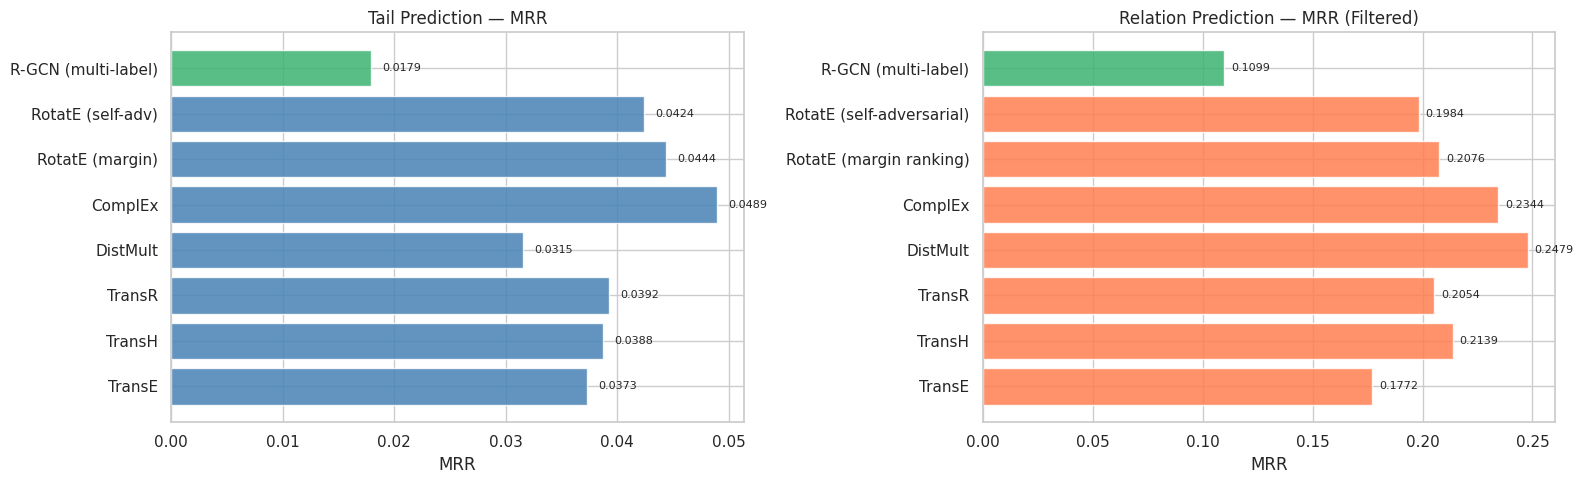

In [118]:
# ── Combined Comparison: KG Models + R-GCN ──────────────────────────────

# Tail Prediction comparison
print("=" * 70)
print("ALL MODELS — Tail Prediction Comparison")
print("=" * 70)
tail_comparison = pd.DataFrame([
    {'Model': 'TransE',   **transe_metrics},
    {'Model': 'TransH',   **transh_metrics},
    {'Model': 'TransR',   **transr_metrics},
    {'Model': 'DistMult', **distmult_metrics},
    {'Model': 'ComplEx',  **complex_metrics},
    {'Model': 'RotatE (margin)',   **rotate_metrics},
    {'Model': 'RotatE (self-adv)', **rotate_adv_metrics},
    {'Model': 'R-GCN (multi-label)', **rgcn_tail_metrics},
])
print(tail_comparison.to_string(index=False))

# Relation Prediction comparison
print("\n" + "=" * 70)
print("ALL MODELS — Relation Prediction Comparison")
print("=" * 70)
rel_comparison_rows = []
for name, m in rel_pred_filtered.items():
    rel_comparison_rows.append({'Model': name, **m})
rel_comparison_rows.append({'Model': 'R-GCN (multi-label)', **rgcn_rel_metrics})
rel_comparison = pd.DataFrame(rel_comparison_rows)
print(rel_comparison.to_string(index=False))

# ── Charts ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Tail Prediction MRR
tail_models = tail_comparison['Model'].tolist()
tail_mrr_vals = tail_comparison['MRR'].tolist()
colors_tail = ['steelblue'] * 7 + ['mediumseagreen']  # R-GCN in green
axes[0].barh(tail_models, tail_mrr_vals, color=colors_tail, alpha=0.85, edgecolor='white')
axes[0].set_xlabel('MRR')
axes[0].set_title('Tail Prediction — MRR')
for i, v in enumerate(tail_mrr_vals):
    axes[0].text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=8)

# Relation Prediction MRR
rel_models = rel_comparison['Model'].tolist()
rel_mrr_vals = rel_comparison['MRR'].tolist()
colors_rel = ['coral'] * (len(rel_models) - 1) + ['mediumseagreen']
axes[1].barh(rel_models, rel_mrr_vals, color=colors_rel, alpha=0.85, edgecolor='white')
axes[1].set_xlabel('MRR')
axes[1].set_title('Relation Prediction — MRR (Filtered)')
for i, v in enumerate(rel_mrr_vals):
    axes[1].text(v + 0.003, i, f'{v:.4f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()


## Analysis of R-GCN vs KG Embeddings

R-GCN underperforms all KG embedding models on both tail prediction (MRR: 0.018 vs 0.031–0.049) and relation prediction (MRR: 0.110 vs 0.177–0.248). This is explained by several structural disadvantages:

1. **Fundamentally different optimization target.** KG models are trained with margin ranking loss directly on triples. The loss explicitly pushes the correct entity/relation above corrupted alternatives, which is exactly what MRR/Hits@K evaluate. R-GCN was trained with multi-label BCE where it learns to classify each relation as present/absent for a drug pair, which doesn't directly optimize for ranking. The mismatch between training objective and evaluation metric hurts performance.

2. **No dedicated entity embeddings.** KG models learn a unique embedding per drug (20K parameters × embedding dim), giving each entity its own learned representation. R-GCN computes embeddings through message passing from random 64-d features. All all drug representations are derived from shared GNN weights, which limits the model's ability to distinguish individual drugs in a ranking of 20K candidates.

3. **Decoder mismatch.** The R-GCN's per-relation decoder uses a simple diagonal scoring $z_h^T \cdot \text{diag}(r) \cdot z_t$, equivalent to DistMult. But unlike DistMult which jointly optimizes entity embeddings and relation vectors for ranking, R-GCN's entity embeddings were optimized for multi-label classification which is a fundamentally different signal.

4. **Where R-GCN would excel.** R-GCN's real advantage is inductive generalization. It can compute embeddings for new drugs not seen during training, while KG models cannot. For a production system where new drugs are regularly introduced, R-GCN's lower ranking metrics are offset by its ability to generalize without retraining. In this benchmark, however, all drugs are seen during training, negating this advantage.

**Future direction:** It would be interesting to experiment with training R-GCN using margin ranking loss instead of multi-label BCE, directly optimizing the GNN encoder for the ranking objective that MRR/Hits@K evaluate. This would align the training signal with the evaluation metrics and could significantly close the gap between R-GCN and KG embedding models, while preserving R-GCN's inductive generalization capability.

---

**Note on node features:** In this analysis, all GNN models use random initial features (64-dimensional vectors) rather than real drug properties. This means the models learn entirely from graph structure through message passing. While the results demonstrate that topology alone carries strong predictive signal (AUC-ROC >0.89), performance could be further improved by incorporating domain-specific features such as chemical fingerprints, drug target profiles, or single-drug side-effect vectors from the BioDecagon mono dataset.

Additionally, graph-derived structural features like node degree (number of interactions), betweenness centrality (how often a drug lies on shortest paths between others), and clustering coefficient (how interconnected a drug's neighbors are) could provide useful topological priors,for example, high-degree hub drugs are more likely to participate in polypharmacy interactions. This represents a deliberate design choice to isolate the contribution of graph structure from feature engineering, ensuring a fair comparison across models.

# Section 4 — Experiments 

Systematic experiments to understand the sensitivity of key models to their hyperparameters and data choices.

## 4.1 — Embedding Dimension Sweep

We vary the embedding dimension across 32, 64, 128, 256 for TransE and ComplEx to measure the effect on performance.

TransE — Embedding Dimension Sweep:
   Dim       MRR        MR    Hits@1   Hits@10
--------------------------------------------------
  Epoch    1/100: loss=0.4560
  Epoch  100/100: loss=0.0511
    32    0.0434     120.3    0.0090    0.0890
  Epoch    1/100: loss=0.2656
  Epoch  100/100: loss=0.0508
    64    0.0384     117.3    0.0030    0.0860
  Epoch    1/100: loss=0.1672
  Epoch  100/100: loss=0.0532
   128    0.0329     120.1    0.0000    0.0830
  Epoch    1/100: loss=0.1187
  Epoch  100/100: loss=0.0621
   256    0.0343     126.0    0.0000    0.0810

ComplEx — Embedding Dimension Sweep:
   Dim       MRR        MR    Hits@1   Hits@10
--------------------------------------------------
  Epoch    1/100: loss=0.4353
  Epoch  100/100: loss=0.0454
    32    0.0473     112.8    0.0140    0.0890
  Epoch    1/100: loss=0.4343
  Epoch  100/100: loss=0.0436
    64    0.0459     109.4    0.0120    0.0850
  Epoch    1/100: loss=0.3928
  Epoch  100/100: loss=0.0414
   128    0.0477     111.2  

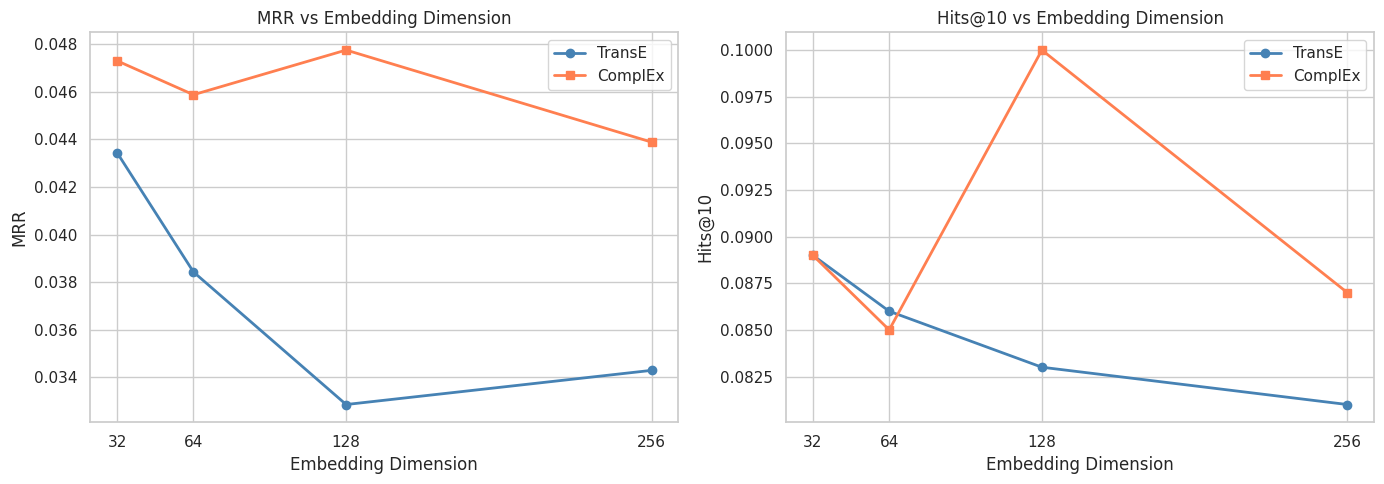

In [ ]:
# ══════════════════════════════════════════════════════════════════════════
#  Embedding Dimension Sweep (TransE vs ComplEx)
# ══════════════════════════════════════════════════════════════════════════
dims_to_test = [32, 64, 128, 256]

# TransE dimension sweep
print("TransE — Embedding Dimension Sweep:")
print(f"{'Dim':>6}  {'MRR':>8}  {'MR':>8}  {'Hits@1':>8}  {'Hits@10':>8}")
print("-" * 50)
transe_dim_results = {}
for dim in dims_to_test:
    model = TransE(n_entities, n_relations, dim=dim, margin=1.0).to(device)
    train_kg_model(model, train_t, val_t, n_entities, epochs=100, eval_every=200)
    metrics = eval_kg_link_prediction(model, test_t[:1000], n_entities)
    transe_dim_results[dim] = metrics
    print(f"{dim:>6}  {metrics['MRR']:>8.4f}  {metrics['MR']:>8.1f}  "
          f"{metrics['Hits@1']:>8.4f}  {metrics['Hits@10']:>8.4f}")

# ComplEx dimension sweep
print("\nComplEx — Embedding Dimension Sweep:")
print(f"{'Dim':>6}  {'MRR':>8}  {'MR':>8}  {'Hits@1':>8}  {'Hits@10':>8}")
print("-" * 50)
complex_dim_results = {}
for dim in dims_to_test:
    model = ComplEx(n_entities, n_relations, dim=dim).to(device)
    train_kg_model(model, train_t, val_t, n_entities, epochs=100, eval_every=200)
    metrics = eval_kg_link_prediction(model, test_t[:1000], n_entities)
    complex_dim_results[dim] = metrics
    print(f"{dim:>6}  {metrics['MRR']:>8.4f}  {metrics['MR']:>8.1f}  "
          f"{metrics['Hits@1']:>8.4f}  {metrics['Hits@10']:>8.4f}")

# ── Plot: Dimension Sweep ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MRR
axes[0].plot(dims_to_test, [transe_dim_results[d]['MRR'] for d in dims_to_test],
             'o-', label='TransE', color='steelblue', linewidth=2)
axes[0].plot(dims_to_test, [complex_dim_results[d]['MRR'] for d in dims_to_test],
             's-', label='ComplEx', color='coral', linewidth=2)
axes[0].set_xlabel('Embedding Dimension')
axes[0].set_ylabel('MRR')
axes[0].set_title('MRR vs Embedding Dimension')
axes[0].legend()
axes[0].set_xticks(dims_to_test)

# Hits@10
axes[1].plot(dims_to_test, [transe_dim_results[d]['Hits@10'] for d in dims_to_test],
             'o-', label='TransE', color='steelblue', linewidth=2)
axes[1].plot(dims_to_test, [complex_dim_results[d]['Hits@10'] for d in dims_to_test],
             's-', label='ComplEx', color='coral', linewidth=2)
axes[1].set_xlabel('Embedding Dimension')
axes[1].set_ylabel('Hits@10')
axes[1].set_title('Hits@10 vs Embedding Dimension')
axes[1].legend()
axes[1].set_xticks(dims_to_test)

plt.tight_layout()
plt.show()


## Extra Dataset 1: SNAP Facebook Social Network

This part analyzes the Facebook ego-network graph for link prediction and community detection using graph embedding 

### Data Source

- **SNAP Facebook Social Network:** https://snap.stanford.edu/data/ego-Facebook.html
    - Facebook Social Circles is an undirected social network graph constructed from survey participants' Facebook friend lists
    - Friendship edges: 88,234 undirected edges representing mutual friendships between 4,039 users
    - The graph consists of 10 ego-networks (personal friend circles) combined into a single connected graph
    - No ground-truth node labels are provided, making this dataset suited for unsupervised tasks (link prediction, community detection, clustering) rather than node classification
    - The graph exhibits strong community structure corresponding to real-world social circles (e.g., classmates, colleagues, family)
    - Download the facebook_combined.txt.gz file from the link above, extract the facebook_combined.txt file and place it in a data/ directory located in the same directory as the main Python notebook

In [16]:
# ── Load Facebook Social Network ─────────────────────────────────────────
G_fb = nx.read_edgelist('data/facebook_combined.txt', nodetype=int, create_using=nx.Graph())

print(f"Facebook Social Network:")
print(f"  Nodes: {G_fb.number_of_nodes():,}")
print(f"  Edges: {G_fb.number_of_edges():,}")
print(f"  Directed: {G_fb.is_directed()}")
print(f"  Avg degree: {2 * G_fb.number_of_edges() / G_fb.number_of_nodes():.1f}")

Facebook Social Network:
  Nodes: 4,039
  Edges: 88,234
  Directed: False
  Avg degree: 43.7


Running Louvain...
  ✓ 15 communities | Modularity: 0.8349
Running Label Propagation...
  ✓ 44 communities | Modularity: 0.7368
Running Walktrap...
  ✓ 77 communities | Modularity: 0.8119
Running Spectral Clustering...
  Eigengap k = 7
  ✓ 7 clusters | Modularity: 0.3190
Running Node2Vec (p=1, q=1 (DeepWalk))...
  ✓ Modularity: 0.8239
Running Node2Vec (p=0.5, q=2 (BFS-like))...
  ✓ Modularity: 0.8185
Running Node2Vec (p=2, q=0.5 (DFS-like))...
  ✓ Modularity: 0.8240

Facebook — Community Detection Summary
                        Method  k  Modularity
                       Louvain 15    0.834882
             Label Propagation 44    0.736841
                      Walktrap 77    0.811940
                Spectral (k=7)  7    0.319001
  Node2Vec p=1, q=1 (DeepWalk) 15    0.823899
Node2Vec p=0.5, q=2 (BFS-like) 15    0.818451
Node2Vec p=2, q=0.5 (DFS-like) 15    0.824027

Note: No ground-truth labels available — only modularity can be compared.


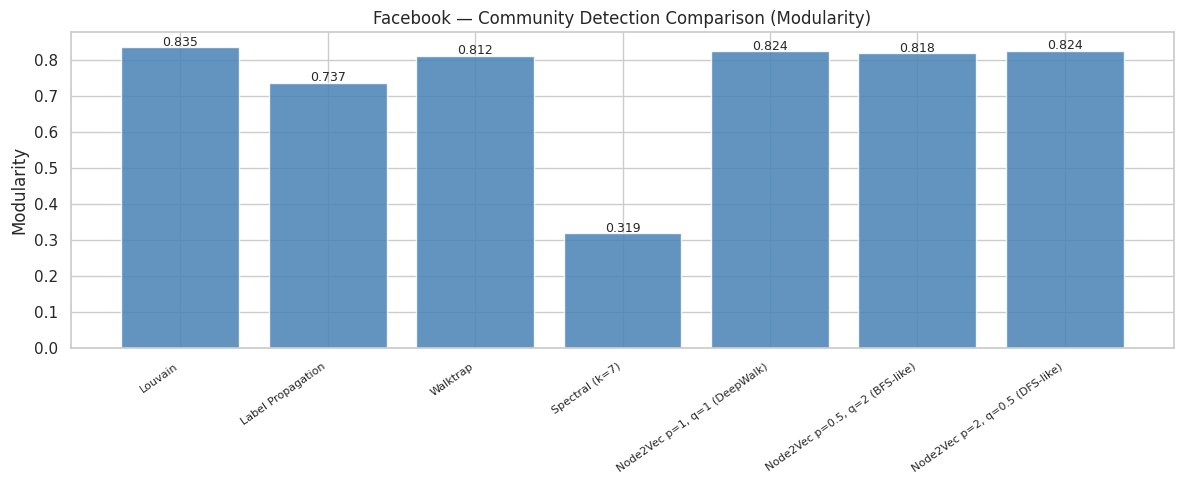

In [18]:
# ══════════════════════════════════════════════════════════════════════════
# Community Detection on Facebook Social Network
# ══════════════════════════════════════════════════════════════════════════
from community import community_louvain
import igraph as ig
from sklearn.cluster import KMeans
from node2vec import Node2Vec

fb_nodes_list = sorted(G_fb.nodes())
fb_methods = {}

# ── Louvain ──────────────────────────────────────────────────────────────
print("Running Louvain...")
fb_partition_louvain = community_louvain.best_partition(G_fb, random_state=42)
k = len(set(fb_partition_louvain.values()))
mod = nx.community.modularity(G_fb,
          [{n for n, c in fb_partition_louvain.items() if c == cid} for cid in set(fb_partition_louvain.values())])
fb_methods['Louvain'] = {'k': k, 'Modularity': mod}
print(f"  ✓ {k} communities | Modularity: {mod:.4f}")

# ── Label Propagation ────────────────────────────────────────────────────
print("Running Label Propagation...")
fb_lpa_comms = list(nx.community.label_propagation_communities(G_fb))
fb_partition_lpa = {}
for cid, comm in enumerate(fb_lpa_comms):
    for node in comm:
        fb_partition_lpa[node] = cid
k = len(set(fb_partition_lpa.values()))
mod = nx.community.modularity(G_fb,
          [{n for n, c in fb_partition_lpa.items() if c == cid} for cid in set(fb_partition_lpa.values())])
fb_methods['Label Propagation'] = {'k': k, 'Modularity': mod}
print(f"  ✓ {k} communities | Modularity: {mod:.4f}")

# ── Walktrap ─────────────────────────────────────────────────────────────
print("Running Walktrap...")
fb_node_map = {n: i for i, n in enumerate(fb_nodes_list)}
fb_edges_ig = [(fb_node_map[u], fb_node_map[v]) for u, v in G_fb.edges()]
fb_G_ig = ig.Graph(n=len(fb_nodes_list), edges=fb_edges_ig, directed=False)
fb_dendro = fb_G_ig.community_walktrap()
fb_clusters_wt = fb_dendro.as_clustering()
fb_partition_wt = {}
for cid, comm in enumerate(fb_clusters_wt):
    for idx in comm:
        fb_partition_wt[fb_nodes_list[idx]] = cid
k = len(set(fb_partition_wt.values()))
mod = nx.community.modularity(G_fb,
          [{n for n, c in fb_partition_wt.items() if c == cid} for cid in set(fb_partition_wt.values())])
fb_methods['Walktrap'] = {'k': k, 'Modularity': mod}
print(f"  ✓ {k} communities | Modularity: {mod:.4f}")

# ── Spectral Clustering ─────────────────────────────────────────────────
print("Running Spectral Clustering...")
L_fb = nx.laplacian_matrix(G_fb).toarray().astype(float)
eigenvalues_fb = np.linalg.eigvalsh(L_fb)
eigenvalues_fb = np.sort(eigenvalues_fb)[:31]
eigengaps_fb = np.diff(eigenvalues_fb)
k_spec = int(np.argmax(eigengaps_fb[1:]) + 2)
k_spec = min(k_spec, 20)
print(f"  Eigengap k = {k_spec}")

eigvals_full, eigvecs_full = np.linalg.eigh(L_fb)
idx_sort = eigvals_full.argsort()
eigvecs_sorted = eigvecs_full[:, idx_sort]
emb_spec = eigvecs_sorted[:, 1:k_spec + 1]
row_norms = np.linalg.norm(emb_spec, axis=1, keepdims=True)
row_norms[row_norms == 0] = 1
emb_spec = emb_spec / row_norms
km = KMeans(n_clusters=k_spec, random_state=42, n_init=10)
fb_spec_labels = km.fit_predict(emb_spec)
fb_partition_spec = {fb_nodes_list[i]: int(fb_spec_labels[i]) for i in range(len(fb_nodes_list))}
mod = nx.community.modularity(G_fb,
          [{n for n, c in fb_partition_spec.items() if c == cid} for cid in set(fb_partition_spec.values())])
fb_methods[f'Spectral (k={k_spec})'] = {'k': k_spec, 'Modularity': mod}
print(f"  ✓ {k_spec} clusters | Modularity: {mod:.4f}")

# ── Node2Vec ─────────────────────────────────────────────────────────────
# Use Louvain's k as target (best proxy without ground truth)
k_target = len(set(fb_partition_louvain.values()))

n2v_fb_configs = [
    (1.0, 1.0, "p=1, q=1 (DeepWalk)"),
    (0.5, 2.0, "p=0.5, q=2 (BFS-like)"),
    (2.0, 0.5, "p=2, q=0.5 (DFS-like)"),
]

for p, q, label in n2v_fb_configs:
    print(f"Running Node2Vec ({label})...")
    n2v = Node2Vec(G_fb, dimensions=64, walk_length=30,
                   num_walks=50, p=p, q=q, workers=4, quiet=True)
    model_n2v = n2v.fit(window=10, min_count=1, batch_words=4)
    emb_n2v = np.array([model_n2v.wv[str(n)] for n in fb_nodes_list])
    km = KMeans(n_clusters=k_target, random_state=42, n_init=10)
    fb_n2v_labels = km.fit_predict(emb_n2v)
    partition = {fb_nodes_list[i]: int(fb_n2v_labels[i]) for i in range(len(fb_nodes_list))}
    mod = nx.community.modularity(G_fb,
              [{n for n, c in partition.items() if c == cid} for cid in set(partition.values())])
    fb_methods[f'Node2Vec {label}'] = {'k': k_target, 'Modularity': mod}
    print(f"  ✓ Modularity: {mod:.4f}")

# ── Summary ──────────────────────────────────────────────────────────────
fb_summary = pd.DataFrame([{'Method': n, **m} for n, m in fb_methods.items()])
print("\n" + "=" * 70)
print("Facebook — Community Detection Summary")
print("=" * 70)
print(fb_summary.to_string(index=False))
print("\nNote: No ground-truth labels available — only modularity can be compared.")

# ── Plot ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(len(fb_methods)), fb_summary['Modularity'], color='steelblue', alpha=0.85, edgecolor='white')
ax.set_xticks(range(len(fb_methods)))
ax.set_xticklabels(fb_summary['Method'], rotation=35, ha='right', fontsize=8)
ax.set_ylabel('Modularity')
ax.set_title('Facebook — Community Detection Comparison (Modularity)')
for i, v in enumerate(fb_summary['Modularity']):
    ax.text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()


### Extra Dataset 2: Email-Eu-Core Communication Network

This part analyzes the Email-Eu-Core directed communication network for community detection.

#### Data Source

- **SNAP Email-Eu-Core Network:** https://snap.stanford.edu/data/email-Eu-core.html
    - Email-Eu-Core is a directed network of email communications between members of a large European research institution
    - Communication edges: 25,571 directed edges representing email exchanges between 1,005 members
    - Ground-truth labels: Each member belongs to one of 42 departments, providing node-level labels for classification tasks (email-Eu-core-department-labels.txt)
    - The directed nature of the graph allows analysis of information flow patterns within the institution
    - Download the email-Eu-core.txt.gz file from the link above, extract the email-Eu-core.txt file and place it in a data/ directory located in the same directory as the main Python notebook.

In [ ]:
G_email = nx.read_edgelist('data/email-Eu-core.txt', nodetype=int, create_using=nx.DiGraph())

email_labels = {}
with open('data/email-Eu-core-department-labels.txt') as f:
    for line in f:
        node, dept = line.strip().split()
        email_labels[int(node)] = int(dept)

print(f"Nodes: {G_email.number_of_nodes()} | Edges: {G_email.number_of_edges()} | Departments: {len(set(email_labels.values()))}")

Nodes: 1005 | Edges: 25571 | Departments: 42


## Clustering and Community Detection

Community detection aims to identify groups of densely connected nodes within the graph. In the Email-Eu-Core network, these communities should correspond to real organizational departments. Unlike link prediction, which asks "will these two nodes be connected?", community detection asks "which nodes belong together?"

We compare five approaches spanning different methodological families:

1. **Louvain Method**
2. **Label Propagation Algorithm (LPA)**
3. **Walktrap Method**
4. **Spectral Clustering**
5. **Node2Vec**

Since the Email-Eu-Core dataset provides ground-truth department labels (42 departments), we evaluate clustering quality using NMI (Normalized Mutual Information) and ARI (Adjusted Rand Index) in addition to modularity. NMI measures how much information the predicted clusters share with the true departments, while ARI measures pairwise agreement adjusted for chance.

In [6]:
# ══════════════════════════════════════════════════════════════════════════
# Spectral Clustering on Email-Eu-Core
# ══════════════════════════════════════════════════════════════════════════
from sklearn.cluster import KMeans
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score

G_email_undirected = G_email.to_undirected()

# Compute Laplacian eigenvectors
print("Computing Laplacian eigenvectors...")
L = nx.laplacian_matrix(G_email_undirected).toarray().astype(float)
eigenvalues, eigenvectors = np.linalg.eigh(L)

# Determine optimal k via eigengap
eigenvalues_sorted = np.sort(eigenvalues)[:51]
eigengaps = np.diff(eigenvalues_sorted)
k_eigengap = int(np.argmax(eigengaps[1:]) + 2)
print(f"  Eigengap suggests k = {k_eigengap}")

# Also test with k = number of departments (ground truth)
k_gt = len(set(email_labels.values()))
print(f"  Ground-truth departments: k = {k_gt}")

# Run spectral clustering with both k values
nodes_list = list(G_email_undirected.nodes())
idx_sort = eigenvalues.argsort()
eigvecs_sorted = eigenvectors[:, idx_sort]

spectral_results = {}
for k, label in [(k_eigengap, "eigengap"), (k_gt, "ground-truth k")]:
    emb = eigvecs_sorted[:, 1:k + 1]
    row_norms = np.linalg.norm(emb, axis=1, keepdims=True)
    row_norms[row_norms == 0] = 1
    emb = emb / row_norms
    
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    pred_labels = km.fit_predict(emb)
    
    partition = {nodes_list[i]: int(pred_labels[i]) for i in range(len(nodes_list))}
    
    # Evaluate against ground truth
    gt = [email_labels.get(n, -1) for n in nodes_list]
    pred = [partition[n] for n in nodes_list]
    nmi = normalized_mutual_info_score(gt, pred)
    ari = adjusted_rand_score(gt, pred)
    mod = nx.community.modularity(G_email_undirected, 
              [{n for n, c in partition.items() if c == cid} for cid in set(partition.values())])
    
    spectral_results[label] = {'k': k, 'NMI': nmi, 'ARI': ari, 'Modularity': mod}
    print(f"\n  Spectral Clustering (k={k}, {label}):")
    print(f"    NMI: {nmi:.4f} | ARI: {ari:.4f} | Modularity: {mod:.4f}")


Computing Laplacian eigenvectors...
  Eigengap suggests k = 20
  Ground-truth departments: k = 42

  Spectral Clustering (k=20, eigengap):
    NMI: 0.0509 | ARI: -0.0010 | Modularity: 0.0047

  Spectral Clustering (k=42, ground-truth k):
    NMI: 0.1715 | ARI: 0.0013 | Modularity: 0.0117


In [9]:
# ══════════════════════════════════════════════════════════════════════════
# Node2Vec Clustering on Email-Eu-Core (multiple p, q configurations)
# ══════════════════════════════════════════════════════════════════════════
from node2vec import Node2Vec

n2v_configs = [
    (1.0, 1.0, "p=1, q=1 (DeepWalk)"),
    (0.5, 2.0, "p=0.5, q=2 (BFS-like)"),
    (2.0, 0.5, "p=2, q=0.5 (DFS-like)"),
]

n2v_results = {}
for p, q, label in n2v_configs:
    print(f"Running Node2Vec ({label})...")
    n2v = Node2Vec(G_email_undirected, dimensions=64, walk_length=30,
                   num_walks=50, p=p, q=q, workers=4, quiet=True)
    model_n2v = n2v.fit(window=10, min_count=1, batch_words=4)
    emb_n2v = np.array([model_n2v.wv[str(n)] for n in nodes_list])
    
    km = KMeans(n_clusters=k_gt, random_state=42, n_init=10)
    pred_labels = km.fit_predict(emb_n2v)
    
    partition = {nodes_list[i]: int(pred_labels[i]) for i in range(len(nodes_list))}
    pred = [partition[n] for n in nodes_list]
    nmi = normalized_mutual_info_score(gt, pred)
    ari = adjusted_rand_score(gt, pred)
    mod = nx.community.modularity(G_email_undirected,
              [{n for n, c in partition.items() if c == cid} for cid in set(partition.values())])
    
    n2v_results[label] = {'k': k_gt, 'NMI': nmi, 'ARI': ari, 'Modularity': mod}
    print(f"  ✓ NMI: {nmi:.4f} | ARI: {ari:.4f} | Modularity: {mod:.4f}")

# Summary of Node2Vec configurations
print("\n" + "=" * 60)
print("Node2Vec — p/q Configuration Comparison")
print("=" * 60)
n2v_df = pd.DataFrame([{'Config': n, **m} for n, m in n2v_results.items()])
print(n2v_df.to_string(index=False))


Running Node2Vec (p=1, q=1 (DeepWalk))...
  ✓ NMI: 0.7099 | ARI: 0.4715 | Modularity: 0.3121
Running Node2Vec (p=0.5, q=2 (BFS-like))...
  ✓ NMI: 0.7056 | ARI: 0.4547 | Modularity: 0.3055
Running Node2Vec (p=2, q=0.5 (DFS-like))...
  ✓ NMI: 0.7067 | ARI: 0.4629 | Modularity: 0.3213

Node2Vec — p/q Configuration Comparison
               Config  k      NMI      ARI  Modularity
  p=1, q=1 (DeepWalk) 42 0.709911 0.471469    0.312100
p=0.5, q=2 (BFS-like) 42 0.705636 0.454713    0.305471
p=2, q=0.5 (DFS-like) 42 0.706696 0.462889    0.321307


In [15]:
# ══════════════════════════════════════════════════════════════════════════
# Node2Vec Clustering on Email-Eu-Core (multiple p, q configurations)
# ══════════════════════════════════════════════════════════════════════════
from node2vec import Node2Vec

n2v_configs = [
    (1.0, 1.0, "p=1, q=1 (DeepWalk)"),
    (0.5, 2.0, "p=0.5, q=2 (BFS-like)"),
    (2.0, 0.5, "p=2, q=0.5 (DFS-like)"),
]

n2v_results = {}
for p, q, label in n2v_configs:
    print(f"Running Node2Vec ({label})...")
    n2v = Node2Vec(G_email_undirected, dimensions=64, walk_length=30,
                   num_walks=50, p=p, q=q, workers=4, quiet=True)
    model_n2v = n2v.fit(window=10, min_count=1, batch_words=4)
    emb_n2v = np.array([model_n2v.wv[str(n)] for n in nodes_list])
    
    km = KMeans(n_clusters=20, random_state=42, n_init=10)
    pred_labels = km.fit_predict(emb_n2v)
    
    partition = {nodes_list[i]: int(pred_labels[i]) for i in range(len(nodes_list))}
    pred = [partition[n] for n in nodes_list]
    nmi = normalized_mutual_info_score(gt, pred)
    ari = adjusted_rand_score(gt, pred)
    mod = nx.community.modularity(G_email_undirected,
              [{n for n, c in partition.items() if c == cid} for cid in set(partition.values())])
    
    n2v_results[label] = {'k': 20, 'NMI': nmi, 'ARI': ari, 'Modularity': mod}
    print(f"  ✓ NMI: {nmi:.4f} | ARI: {ari:.4f} | Modularity: {mod:.4f}")

# Summary of Node2Vec configurations
print("\n" + "=" * 60)
print("Node2Vec — p/q Configuration Comparison")
print("=" * 60)
n2v_df = pd.DataFrame([{'Config': n, **m} for n, m in n2v_results.items()])
print(n2v_df.to_string(index=False))


Running Node2Vec (p=1, q=1 (DeepWalk))...
  ✓ NMI: 0.6946 | ARI: 0.4800 | Modularity: 0.3854
Running Node2Vec (p=0.5, q=2 (BFS-like))...
  ✓ NMI: 0.7006 | ARI: 0.4995 | Modularity: 0.3937
Running Node2Vec (p=2, q=0.5 (DFS-like))...
  ✓ NMI: 0.6994 | ARI: 0.4954 | Modularity: 0.3769

Node2Vec — p/q Configuration Comparison
               Config  k      NMI      ARI  Modularity
  p=1, q=1 (DeepWalk) 20 0.694556 0.479974    0.385446
p=0.5, q=2 (BFS-like) 20 0.700636 0.499459    0.393714
p=2, q=0.5 (DFS-like) 20 0.699415 0.495350    0.376930


The run above implements the eigengap value k = 20.

In [10]:
# ══════════════════════════════════════════════════════════════════════════
# Traditional Community Detection on Email-Eu-Core
# ══════════════════════════════════════════════════════════════════════════
from community import community_louvain
import igraph as ig
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score

G_email_undirected = G_email.to_undirected()
nodes_list = sorted(G_email_undirected.nodes())
k_gt = len(set(email_labels.values()))
gt = [email_labels.get(n, -1) for n in nodes_list]

methods = {}

# ── Louvain ──────────────────────────────────────────────────────────────
print("Running Louvain...")
partition_louvain = community_louvain.best_partition(G_email_undirected, random_state=42)
pred = [partition_louvain[n] for n in nodes_list]
k = len(set(partition_louvain.values()))
mod = nx.community.modularity(G_email_undirected,
          [{n for n, c in partition_louvain.items() if c == cid} for cid in set(partition_louvain.values())])
methods['Louvain'] = {'k': k, 'NMI': normalized_mutual_info_score(gt, pred),
                       'ARI': adjusted_rand_score(gt, pred), 'Modularity': mod}
print(f"  ✓ {k} communities")

# ── Label Propagation ────────────────────────────────────────────────────
print("Running Label Propagation...")
lpa_comms = list(nx.community.label_propagation_communities(G_email_undirected))
partition_lpa = {}
for cid, comm in enumerate(lpa_comms):
    for node in comm:
        partition_lpa[node] = cid
pred = [partition_lpa[n] for n in nodes_list]
k = len(set(partition_lpa.values()))
mod = nx.community.modularity(G_email_undirected,
          [{n for n, c in partition_lpa.items() if c == cid} for cid in set(partition_lpa.values())])
methods['Label Propagation'] = {'k': k, 'NMI': normalized_mutual_info_score(gt, pred),
                                 'ARI': adjusted_rand_score(gt, pred), 'Modularity': mod}
print(f"  ✓ {k} communities")

# ── Walktrap ─────────────────────────────────────────────────────────────
print("Running Walktrap...")
node_map = {n: i for i, n in enumerate(nodes_list)}
edges_ig = [(node_map[u], node_map[v]) for u, v in G_email_undirected.edges()]
G_ig = ig.Graph(n=len(nodes_list), edges=edges_ig, directed=False)
dendro = G_ig.community_walktrap()
clusters_wt = dendro.as_clustering()
partition_wt = {}
for cid, comm in enumerate(clusters_wt):
    for idx in comm:
        partition_wt[nodes_list[idx]] = cid
pred = [partition_wt[n] for n in nodes_list]
k = len(set(partition_wt.values()))
mod = nx.community.modularity(G_email_undirected,
          [{n for n, c in partition_wt.items() if c == cid} for cid in set(partition_wt.values())])
methods['Walktrap'] = {'k': k, 'NMI': normalized_mutual_info_score(gt, pred),
                        'ARI': adjusted_rand_score(gt, pred), 'Modularity': mod}
print(f"  ✓ {k} communities")

Running Louvain...
  ✓ 27 communities
Running Label Propagation...
  ✓ 38 communities
Running Walktrap...
  ✓ 145 communities


Email-Eu-Core — All Community Detection Methods
                        Method   k      NMI      ARI  Modularity
                       Louvain  27 0.559223 0.283678    0.422322
             Label Propagation  38 0.180293 0.011373    0.089003
                      Walktrap 145 0.580412 0.197498    0.371906
               Spectral (k=42)  42 0.171497 0.001317    0.011730
  Node2Vec p=1, q=1 (DeepWalk)  42 0.709911 0.471469    0.312100
Node2Vec p=0.5, q=2 (BFS-like)  42 0.705636 0.454713    0.305471
Node2Vec p=2, q=0.5 (DFS-like)  42 0.706696 0.462889    0.321307


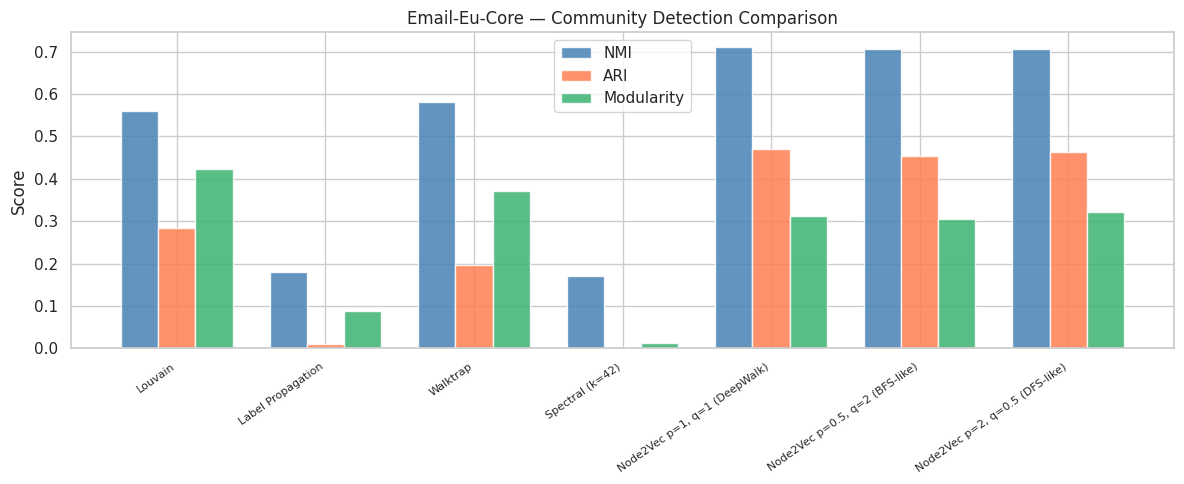

In [11]:
# ══════════════════════════════════════════════════════════════════════════
# Overall Summary: All Clustering Methods on Email-Eu-Core
# ══════════════════════════════════════════════════════════════════════════

all_methods = dict(methods)  # Louvain, LPA, Walktrap from earlier
all_methods[f'Spectral (k={k_gt})'] = spectral_results["ground-truth k"]
for config_name, metrics in n2v_results.items():
    all_methods[f'Node2Vec {config_name}'] = metrics

summary_df = pd.DataFrame([{'Method': n, **m} for n, m in all_methods.items()])
print("=" * 70)
print("Email-Eu-Core — All Community Detection Methods")
print("=" * 70)
print(summary_df.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(all_methods))
width = 0.25
ax.bar(x - width, summary_df['NMI'], width, label='NMI', color='steelblue', alpha=0.85)
ax.bar(x, summary_df['ARI'], width, label='ARI', color='coral', alpha=0.85)
ax.bar(x + width, summary_df['Modularity'], width, label='Modularity', color='mediumseagreen', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(summary_df['Method'], rotation=35, ha='right', fontsize=8)
ax.set_ylabel('Score')
ax.set_title('Email-Eu-Core — Community Detection Comparison')
ax.legend()
plt.tight_layout()
plt.show()


Visualizing best config: p=1, q=1 (DeepWalk)


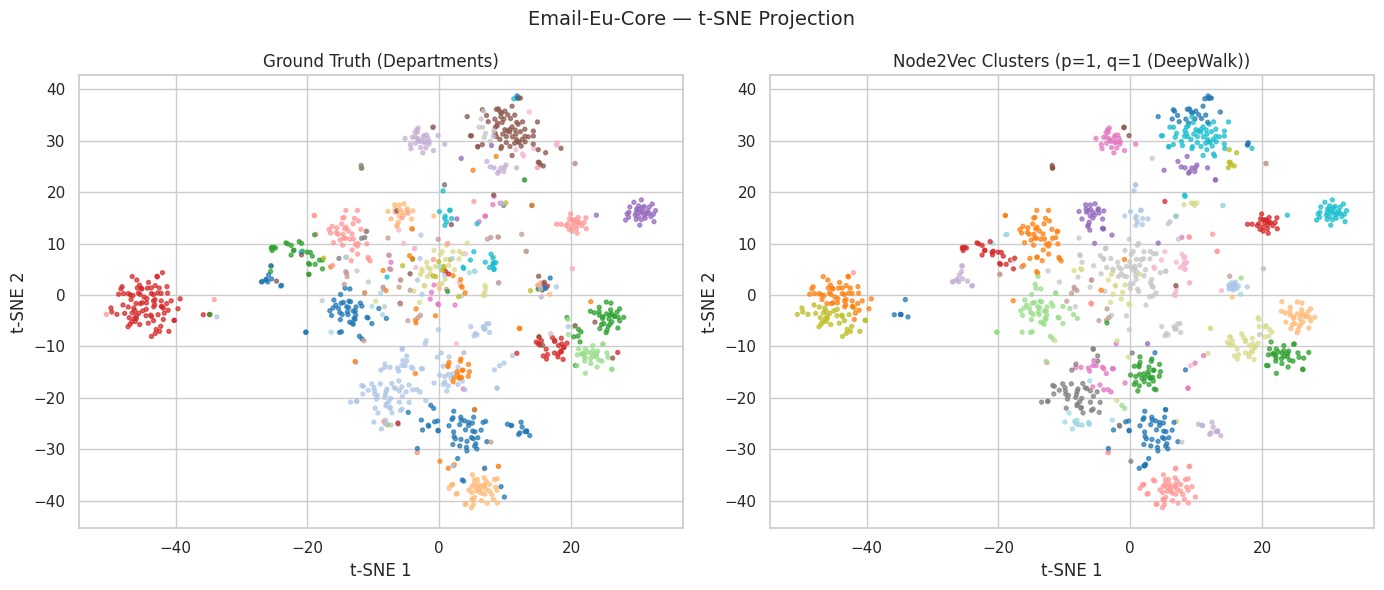

In [12]:
# ── t-SNE Visualization: Node2Vec Clusters vs Ground Truth ───────────────
from sklearn.manifold import TSNE

# Use the best Node2Vec embeddings
best_config = max(n2v_results, key=lambda x: n2v_results[x]['NMI'])
print(f"Visualizing best config: {best_config}")

# Recompute embeddings for the best config (or reuse if stored)
p, q = [(p, q) for p, q, l in n2v_configs if l == best_config][0]
n2v = Node2Vec(G_email_undirected, dimensions=64, walk_length=30,
               num_walks=50, p=p, q=q, workers=4, quiet=True)
model_n2v = n2v.fit(window=10, min_count=1, batch_words=4)
emb_best = np.array([model_n2v.wv[str(n)] for n in nodes_list])

# t-SNE projection
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
emb_2d = tsne.fit_transform(emb_best)

# Predict clusters
km = KMeans(n_clusters=k_gt, random_state=42, n_init=10)
pred_clusters = km.fit_predict(emb_best)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Ground truth departments
gt_arr = np.array([email_labels.get(n, -1) for n in nodes_list])
scatter1 = axes[0].scatter(emb_2d[:, 0], emb_2d[:, 1], c=gt_arr, cmap='tab20', s=8, alpha=0.7)
axes[0].set_title('Ground Truth (Departments)')
axes[0].set_xlabel('t-SNE 1')
axes[0].set_ylabel('t-SNE 2')

# Node2Vec clusters
scatter2 = axes[1].scatter(emb_2d[:, 0], emb_2d[:, 1], c=pred_clusters, cmap='tab20', s=8, alpha=0.7)
axes[1].set_title(f'Node2Vec Clusters ({best_config})')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')

plt.suptitle('Email-Eu-Core — t-SNE Projection', fontsize=14)
plt.tight_layout()
plt.show()


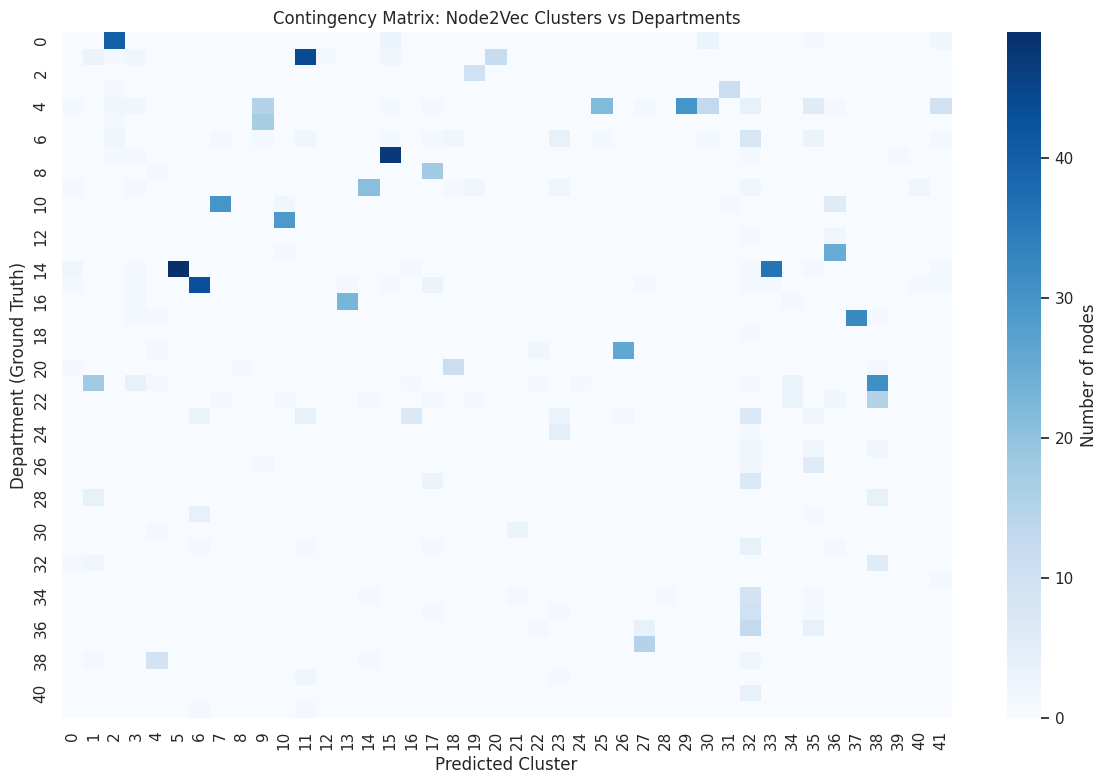

In [13]:
# ── Confusion Matrix: Clusters vs Departments ────────────────────────────
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Best Node2Vec partition
partition_best = {nodes_list[i]: int(pred_clusters[i]) for i in range(len(nodes_list))}

# Build aligned label arrays
gt_labels = [email_labels.get(n, -1) for n in nodes_list]
pred_labels = [partition_best[n] for n in nodes_list]

# Contingency matrix (clusters × departments)
from sklearn.metrics.cluster import contingency_matrix
cm = contingency_matrix(gt_labels, pred_labels)

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(cm, cmap='Blues', ax=ax, cbar_kws={'label': 'Number of nodes'})
ax.set_xlabel('Predicted Cluster')
ax.set_ylabel('Department (Ground Truth)')
ax.set_title('Contingency Matrix: Node2Vec Clusters vs Departments')
plt.tight_layout()
plt.show()


**Node2Vec clearly outperforms all other methods** (NMI ~0.71, ARI ~0.47), demonstrating that learned random-walk embeddings capture department structure far better than graph-theoretic heuristics or spectral methods. All three p/q configurations perform nearly identically, suggesting the community structure is well-defined and does not require specialized walk strategies.

**Louvain and Walktrap are competitive but limited.** Louvain achieves the highest modularity (0.42) but merges small departments (k=27 < 42), while Walktrap over-fragments into 145 clusters. Both recover moderate NMI (~0.56–0.58) but lower ARI, indicating partial alignment with true departments.

**Spectral Clustering and Label Propagation** fail (NMI <0.18) despite spectral using the correct k=42. This suggests the graph Laplacian eigenvectors do not cleanly separate the overlapping communication patterns across departments, and Label Propagation's stochastic consensus mechanism is too unstable for this network structure.

**Key takeaway:** Embedding-based approaches substantially outperform traditional community detection on this dataset, capturing nonlinear structural patterns that eigendecomposition and modularity optimization miss.

**Important caveat:** Node2Vec and Spectral Clustering used the ground-truth number of departments (k=42) for K-Means clustering, while Louvain (k=27), Label Propagation (k=38), and Walktrap (k=145) determined their cluster count automatically. Providing the correct k gives embedding-based methods a significant advantage, since they only need to assign nodes to 42 groups, while traditional methods must also discover the right number of groups. A fairer comparison would use the eigengap-estimated k for Node2Vec clustering as well. Despite this bias, the comparison still shows that Node2Vec embeddings capture better structural representations, since Spectral Clustering also used k=42 but performed poorly (NMI: 0.17).

Also, interstingly, once the Node2Vec algorithm was re-ran with the spectral gap as the number of clusters, the results were even better for modularity, with the NMI remaining comparable to the previously reported values.

**Why Node2Vec Wins?** Node2Vec sees more of the graph (long walks, many samples), learns richer representations (nonlinear embeddings), and naturally clusters nodes that share neighborhood patterns which is exactly what departments are.